In [1]:
import pandas as pd
import numpy as np
import datetime
import sys
import copy
import os
#from WindPy import w
import scipy.io as scio
from scipy.stats.mstats import winsorize
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
from scipy.stats import spearmanr
from scipy.stats import ttest_1samp
import statsmodels.api as sm
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']  # 用 SimHei 替换为合适的中文字体
rcParams['axes.unicode_minus'] = False  # 解决坐标轴负号显示问题

# 总体资金

In [2]:
ETF=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\ETF.csv', index_col=0)
ETF.rename(columns={'UnitNV':'UnitNVRestored'},inplace=True)
ETF.drop_duplicates(subset=['SecuCode','TradingDay','EndShares'],keep='last',inplace=True)
ETF.drop_duplicates(subset=['SecuCode','TradingDay','UnitNVRestored'],keep='last',inplace=True)
ETF

,SecuCode,TradingDay,UnitNVRestored,EndDate,EndShares,FloatShares
2,000001.OF,2012-12-31,0.9610,2012-12-31,9.373216e+09,NaN
4,000001.OF,2013-03-31,1.0240,2013-03-31,9.093381e+09,NaN
7,000001.OF,2013-06-30,1.0120,2013-06-30,8.775370e+09,NaN
9,000001.OF,2013-09-30,1.1310,2013-09-30,8.294967e+09,NaN
12,000001.OF,2013-12-31,1.1120,2013-12-31,8.008907e+09,NaN
...,...,...,...,...,...,...
3403167,980003.OF,2022-06-30,1.5393,2022-06-30,2.352391e+09,NaN
3403169,980003.OF,2022-09-30,1.5513,2022-09-30,2.325806e+09,NaN
3403172,980003.OF,2022-12-31,1.5497,2022-12-31,1.825143e+09,NaN
3403174,980003.OF,2023-03-31,1.5666,2023-03-31,1.265889e+09,NaN


In [3]:
name=pd.read_excel(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\ETF行业筛选基金.xlsx',sheet_name='ETF')
name['四级分类']=name['备注']

In [4]:
ETF.rename(columns={'SecuCode':'证券代码'},inplace=True)

In [5]:
merged=pd.merge(ETF,name,on='证券代码',how='inner')
merged.sort_values(by=['证券代码','TradingDay'])
hangye=merged.copy()
hangye

,证券代码,TradingDay,UnitNVRestored,EndDate,EndShares,FloatShares,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
0,159301.OF,2024-07-15,1.0005,2024-07-15,230458357.0,NaN,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,基建,基建,基建
1,159301.OF,2024-07-22,0.9961,2024-07-22,230458357.0,230458357.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,基建,基建,基建
2,159301.OF,2024-07-23,0.9922,2024-07-23,126958357.0,126958357.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,基建,基建,基建
3,159301.OF,2024-07-24,1.0123,2024-07-24,124458357.0,124458357.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,基建,基建,基建
4,159301.OF,2024-07-25,1.0092,2024-07-25,90458357.0,90458357.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,基建,基建,基建
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316890,588890.OF,2024-07-23,1.0903,2024-07-23,44810000.0,44810000.0,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,电子,半导体,电子
316891,588890.OF,2024-07-24,1.0801,2024-07-24,44810000.0,44810000.0,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,电子,半导体,电子
316892,588890.OF,2024-07-25,1.0723,2024-07-25,47810000.0,47810000.0,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,电子,半导体,电子
316893,588890.OF,2024-07-26,1.0807,2024-07-26,47810000.0,47810000.0,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,电子,半导体,电子


In [6]:
hangye['EndShares'] = hangye.apply(lambda row: row['FloatShares'] if pd.isna(row['EndShares']) else row['EndShares'], axis=1)
hangye = hangye.dropna(subset=['EndShares', 'FloatShares'], how='all')
hangye 

,证券代码,TradingDay,UnitNVRestored,EndDate,EndShares,FloatShares,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
0,159301.OF,2024-07-15,1.0005,2024-07-15,230458357.0,NaN,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,基建,基建,基建
1,159301.OF,2024-07-22,0.9961,2024-07-22,230458357.0,230458357.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,基建,基建,基建
2,159301.OF,2024-07-23,0.9922,2024-07-23,126958357.0,126958357.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,基建,基建,基建
3,159301.OF,2024-07-24,1.0123,2024-07-24,124458357.0,124458357.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,基建,基建,基建
4,159301.OF,2024-07-25,1.0092,2024-07-25,90458357.0,90458357.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,基建,基建,基建
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316890,588890.OF,2024-07-23,1.0903,2024-07-23,44810000.0,44810000.0,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,电子,半导体,电子
316891,588890.OF,2024-07-24,1.0801,2024-07-24,44810000.0,44810000.0,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,电子,半导体,电子
316892,588890.OF,2024-07-25,1.0723,2024-07-25,47810000.0,47810000.0,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,电子,半导体,电子
316893,588890.OF,2024-07-26,1.0807,2024-07-26,47810000.0,47810000.0,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,电子,半导体,电子


### 覆盖个数

In [7]:
fugai=hangye.copy()
fugai.sort_values(by='TradingDay',inplace=True)
fugai

,证券代码,TradingDay,UnitNVRestored,EndDate,EndShares,FloatShares,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
87250,159909.OF,2012-12-31,2.3860,2012-12-31,1.097714e+08,NaN,招商深证TMT50ETF,2011-06-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,TMT,TMT,TMT
123248,510090.OF,2012-12-31,0.8840,2012-12-31,4.545811e+08,NaN,建信上证社会责任ETF,2010-05-28,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,绿色/ESG,-,绿色/ESG
127108,510230.OF,2012-12-31,3.3900,2012-12-31,2.842616e+08,NaN,国泰上证180金融ETF,2011-03-31,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融,金融综合,金融
120421,510060.OF,2012-12-31,1.1691,2012-12-31,5.749592e+08,NaN,工银上证央企50ETF,2009-08-26,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,国央企,国央企综合,国央企
129935,510270.OF,2012-12-31,0.7650,2012-12-31,1.258321e+08,NaN,中银上证国企ETF,2011-06-16,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,国央企,国央企综合,国央企
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80543,159886.OF,2024-07-29,0.6732,2024-07-29,7.144256e+07,7.144256e+07,富国中证细分机械设备产业ETF,2021-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,机械设备,机械设备,机械设备
79748,159885.OF,2024-07-29,0.5520,2024-07-29,5.444673e+08,5.444673e+08,鹏华中证内地低碳经济ETF,2021-04-06,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,绿色/ESG,-,绿色/ESG
78943,159883.OF,2024-07-29,0.4429,2024-07-29,3.529038e+09,3.529038e+09,永赢中证全指医疗器械ETF,2021-04-22,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医疗,医疗,医疗
85722,159896.OF,2024-07-29,0.6589,2024-07-29,7.905596e+07,7.905596e+07,南方中证物联网主题ETF,2021-11-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,TMT,TMT,TMT


In [8]:
quarter_to_date = {
    'Q1': '-03-31',
    'Q2': '-06-30',
    'Q3': '-09-30',
    'Q4': '-12-31'
}
fugai['TradingDay'] = pd.to_datetime(fugai['TradingDay'])
fugai['Quarter'] = fugai['TradingDay'].dt.to_period('Q')
fugai['Quarter'] = fugai['Quarter'].astype(str)
fugai['Quarter'] = fugai['Quarter'].apply(lambda x: x[:4] + quarter_to_date[x[4:]])
unique_industries= fugai.groupby('Quarter')['四级分类'].nunique().reset_index()
unique_industries=unique_industries[unique_industries['Quarter'] >= '2015-03-31']
unique_industries

,Quarter,四级分类
9,2015-03-31,8
10,2015-06-30,8
11,2015-09-30,8
12,2015-12-31,8
13,2016-03-31,8
14,2016-06-30,8
15,2016-09-30,9
16,2016-12-31,9
17,2017-03-31,9
18,2017-06-30,9


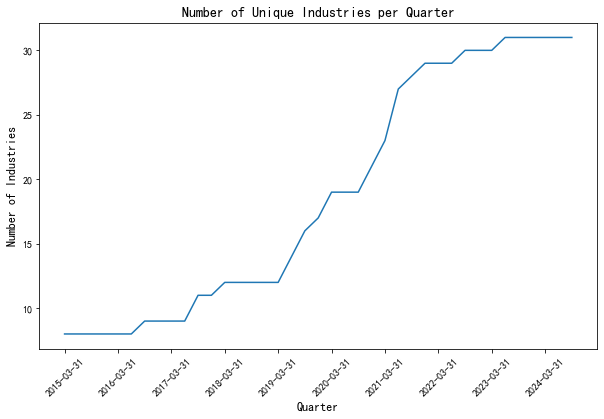

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(unique_industries['Quarter'], unique_industries['四级分类'])
plt.title('Number of Unique Industries per Quarter', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Number of Industries', fontsize=12)
plt.xticks(range(0, len(unique_industries['Quarter']), 4), 
           unique_industries['Quarter'][::4], rotation=45)
plt.show()

画图结束

In [10]:
len(set(hangye['证券代码']))

407

In [11]:
hangye.loc[:, '市值亿元'] = hangye['UnitNVRestored'] * hangye['EndShares']/100000000

### 画图Cash

考虑由于基金新成立而导致的资金流增加，所定义的资金流，这段代码的目的目前是主要用来看行业的资金净申购额，所以应该包括新成立所导致的资金增加。但是后面计算现金流因子，我们不考虑新增加基金导致的资金流入。

In [12]:
Shares=hangye[['证券代码','TradingDay','EndShares']].copy()
Shares

,证券代码,TradingDay,EndShares
0,159301.OF,2024-07-15,230458357.0
1,159301.OF,2024-07-22,230458357.0
2,159301.OF,2024-07-23,126958357.0
3,159301.OF,2024-07-24,124458357.0
4,159301.OF,2024-07-25,90458357.0
...,...,...,...
316890,588890.OF,2024-07-23,44810000.0
316891,588890.OF,2024-07-24,44810000.0
316892,588890.OF,2024-07-25,47810000.0
316893,588890.OF,2024-07-26,47810000.0


In [13]:
price=hangye[['证券代码','TradingDay','UnitNVRestored']].copy()
price

,证券代码,TradingDay,UnitNVRestored
0,159301.OF,2024-07-15,1.0005
1,159301.OF,2024-07-22,0.9961
2,159301.OF,2024-07-23,0.9922
3,159301.OF,2024-07-24,1.0123
4,159301.OF,2024-07-25,1.0092
...,...,...,...
316890,588890.OF,2024-07-23,1.0903
316891,588890.OF,2024-07-24,1.0801
316892,588890.OF,2024-07-25,1.0723
316893,588890.OF,2024-07-26,1.0807


In [14]:
# 考虑由于基金新成立而导致的资金流增加
Shares_pivot=Shares.pivot_table(index='TradingDay',columns='证券代码',values='EndShares',aggfunc='sum')
Shares_pivot.fillna(0,inplace=True)
fene=Shares_pivot.diff()
fene

证券代码,159301.OF,159306.OF,159309.OF,159310.OF,159315.OF,159321.OF,159322.OF,159327.OF,159503.OF,159507.OF,...,562990.OF,563010.OF,563050.OF,563150.OF,588100.OF,588200.OF,588260.OF,588290.OF,588700.OF,588890.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,-103500000.0,-2000000.0,-4000000.0,0.0,-6000000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-4000000.0,-1000000.0,-10500000.0,12000000.0,0.0,-30000000.0,0.0,3000000.0
2024-07-24,-2500000.0,2000000.0,-1000000.0,0.0,-1000000.0,0.0,0.0,0.0,0.0,0.0,...,-1000000.0,0.0,0.0,-1000000.0,0.0,-468000000.0,0.0,-15000000.0,0.0,0.0
2024-07-25,-34000000.0,0.0,0.0,0.0,-1000000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-1000000.0,-1000000.0,0.0,-183000000.0,0.0,2500000.0,0.0,3000000.0


In [15]:
price_pivot=price.pivot_table(index='TradingDay',columns='证券代码',values='UnitNVRestored',aggfunc='sum')
price_pivot

证券代码,159301.OF,159306.OF,159309.OF,159310.OF,159315.OF,159321.OF,159322.OF,159327.OF,159503.OF,159507.OF,...,562990.OF,563010.OF,563050.OF,563150.OF,588100.OF,588200.OF,588260.OF,588290.OF,588700.OF,588890.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,0.9922,0.8589,0.9493,1.0454,0.9858,0.9346,0.9825,NaN,NaN,0.8909,...,0.6894,0.9544,0.7513,0.9200,0.8876,0.9734,0.8819,0.9517,0.7743,1.0903
2024-07-24,1.0123,0.8370,0.9493,1.0335,0.9886,0.9371,0.9844,NaN,NaN,0.8897,...,0.6868,0.9560,0.7514,0.9200,0.8768,0.9643,0.8713,0.9428,0.7599,1.0801
2024-07-25,1.0092,0.8363,0.9352,1.0229,0.9406,0.8923,0.9389,NaN,NaN,0.8747,...,0.6845,0.9437,0.7479,0.9064,0.8737,0.9574,0.8682,0.9361,0.7625,1.0723


In [16]:
cash=fene*price_pivot/100000000
cash.replace(0,np.nan,inplace=True)
cash

证券代码,159301.OF,159306.OF,159309.OF,159310.OF,159315.OF,159321.OF,159322.OF,159327.OF,159503.OF,159507.OF,...,562990.OF,563010.OF,563050.OF,563150.OF,588100.OF,588200.OF,588260.OF,588290.OF,588700.OF,588890.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,-1.026927,-0.017178,-0.037972,NaN,-0.059148,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.030052,-0.009200,-0.093198,0.116808,NaN,-0.285510,NaN,0.032709
2024-07-24,-0.025308,0.016740,-0.009493,NaN,-0.009886,NaN,NaN,NaN,NaN,NaN,...,-0.006868,NaN,NaN,-0.009200,NaN,-4.512924,NaN,-0.141420,NaN,NaN
2024-07-25,-0.343128,NaN,NaN,NaN,-0.009406,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.007479,-0.009064,NaN,-1.752042,NaN,0.023402,NaN,0.032169


因为我们前面对于不存在的空值暴力填充0，再暴力的返回NAN，这会把本来是0的给覆盖掉。而本来是0意味着没有资金变化，这种情况只会出现在该基金成立后才有，我们对特殊的NAN，填补成0

In [17]:
def fill_nan_after_first_non_na(df):  
    def fill_column(col):
        first_non_na_index = col.first_valid_index()
        if first_non_na_index is not None:
            col.loc[col.index > first_non_na_index] = col.loc[col.index > first_non_na_index].fillna(0)  #对每一列第一次有值的行之后对于空值填写0
        return col
    return df.apply(fill_column, axis=0)

In [18]:
cash=fill_nan_after_first_non_na(cash)
cash

证券代码,159301.OF,159306.OF,159309.OF,159310.OF,159315.OF,159321.OF,159322.OF,159327.OF,159503.OF,159507.OF,...,562990.OF,563010.OF,563050.OF,563150.OF,588100.OF,588200.OF,588260.OF,588290.OF,588700.OF,588890.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,-1.026927,-0.017178,-0.037972,0.0,-0.059148,0.000000,0.0,NaN,0.0,0.000000,...,0.000000,0.000000,-0.030052,-0.009200,-0.093198,0.116808,0.0,-0.285510,0.0,0.032709
2024-07-24,-0.025308,0.016740,-0.009493,0.0,-0.009886,0.000000,0.0,NaN,0.0,0.000000,...,-0.006868,0.000000,0.000000,-0.009200,0.000000,-4.512924,0.0,-0.141420,0.0,0.000000
2024-07-25,-0.343128,0.000000,0.000000,0.0,-0.009406,0.000000,0.0,NaN,0.0,0.000000,...,0.000000,0.000000,-0.007479,-0.009064,0.000000,-1.752042,0.0,0.023402,0.0,0.032169


In [19]:
cash=cash.stack().reset_index()
cash.rename(columns={0:'资金变化(亿元)'},inplace=True)

In [20]:
cashplot=cash.copy()
cashplot

,TradingDay,证券代码,资金变化(亿元)
0,2013-01-04,159909.OF,0.011780
1,2013-01-04,510010.OF,-0.003608
2,2013-01-04,510060.OF,-0.023040
3,2013-01-04,510090.OF,0.003728
4,2013-01-04,510230.OF,-0.043147
...,...,...,...
318647,2024-07-29,588200.OF,0.652464
318648,2024-07-29,588260.OF,0.000000
318649,2024-07-29,588290.OF,0.069352
318650,2024-07-29,588700.OF,0.000000


In [21]:
cashplot['TradingDay'] = pd.to_datetime(cashplot['TradingDay'])
cashplot['Quarter'] = cashplot['TradingDay'].dt.to_period('Q')
cashplot['Quarter'] = cashplot['Quarter'].astype(str)
cashplot['Quarter'] =cashplot['Quarter'].apply(lambda x: x[:4] + quarter_to_date[x[4:]])
quarterly_cash= cashplot.groupby('Quarter')['资金变化(亿元)'].sum().reset_index()
quarterly_cash=quarterly_cash[quarterly_cash['Quarter'] >= '2015-03-31']
quarterly_cash

,Quarter,资金变化(亿元)
8,2015-03-31,27.528398
9,2015-06-30,-4.116754
10,2015-09-30,-3.569798
11,2015-12-31,-4.087626
12,2016-03-31,-2.391466
13,2016-06-30,-2.326571
14,2016-09-30,345.988941
15,2016-12-31,6.234000
16,2017-03-31,28.211740
17,2017-06-30,-8.092946


In [22]:
with pd.ExcelWriter(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\底稿.xlsx', engine='openpyxl') as writer:
    unique_industries.to_excel(writer,sheet_name='行业覆盖个数',index=False)
    quarterly_cash.to_excel(writer, sheet_name='资金净申赎', index=False)

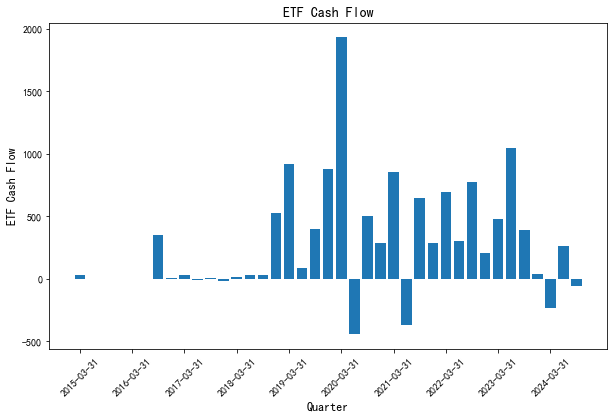

In [23]:
plt.figure(figsize=(10, 6))
plt.bar(quarterly_cash['Quarter'], quarterly_cash['资金变化(亿元)'])
plt.title('ETF Cash Flow', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('ETF Cash Flow', fontsize=12)
plt.xticks(range(0, len(quarterly_cash['Quarter']), 4), 
           quarterly_cash['Quarter'][::4], rotation=45)
plt.show()

画图结束

我们目前定义的资金流因子，不考虑新增加基金成立时候导致的资金流入

In [24]:
def compute_diffshare(group):
    group = group.sort_values(by='TradingDay')
    group['份额变化'] = group['EndShares'].diff()
    return group

In [25]:
Shares=hangye[['证券代码','TradingDay','EndShares']].copy()
Shares

,证券代码,TradingDay,EndShares
0,159301.OF,2024-07-15,230458357.0
1,159301.OF,2024-07-22,230458357.0
2,159301.OF,2024-07-23,126958357.0
3,159301.OF,2024-07-24,124458357.0
4,159301.OF,2024-07-25,90458357.0
...,...,...,...
316890,588890.OF,2024-07-23,44810000.0
316891,588890.OF,2024-07-24,44810000.0
316892,588890.OF,2024-07-25,47810000.0
316893,588890.OF,2024-07-26,47810000.0


In [26]:
fene = Shares.groupby('证券代码', group_keys=False).apply(compute_diffshare)
fene.dropna(inplace=True)
fene

,证券代码,TradingDay,EndShares,份额变化
1,159301.OF,2024-07-22,230458357.0,0.0
2,159301.OF,2024-07-23,126958357.0,-103500000.0
3,159301.OF,2024-07-24,124458357.0,-2500000.0
4,159301.OF,2024-07-25,90458357.0,-34000000.0
5,159301.OF,2024-07-26,92458357.0,2000000.0
...,...,...,...,...
316890,588890.OF,2024-07-23,44810000.0,3000000.0
316891,588890.OF,2024-07-24,44810000.0,0.0
316892,588890.OF,2024-07-25,47810000.0,3000000.0
316893,588890.OF,2024-07-26,47810000.0,0.0


In [27]:
def compute_returns(group):
    group = group.sort_values(by='TradingDay')  
    group['收益率'] = group['UnitNVRestored'].pct_change()   
    return group

In [28]:
price=hangye[['证券代码','TradingDay','UnitNVRestored']].copy()
price

,证券代码,TradingDay,UnitNVRestored
0,159301.OF,2024-07-15,1.0005
1,159301.OF,2024-07-22,0.9961
2,159301.OF,2024-07-23,0.9922
3,159301.OF,2024-07-24,1.0123
4,159301.OF,2024-07-25,1.0092
...,...,...,...
316890,588890.OF,2024-07-23,1.0903
316891,588890.OF,2024-07-24,1.0801
316892,588890.OF,2024-07-25,1.0723
316893,588890.OF,2024-07-26,1.0807


In [29]:
return_= price.groupby('证券代码', group_keys=False).apply(compute_returns)
return_.dropna(inplace=True)
return_

,证券代码,TradingDay,UnitNVRestored,收益率
1,159301.OF,2024-07-22,0.9961,-0.004398
2,159301.OF,2024-07-23,0.9922,-0.003915
3,159301.OF,2024-07-24,1.0123,0.020258
4,159301.OF,2024-07-25,1.0092,-0.003062
5,159301.OF,2024-07-26,1.0010,-0.008125
...,...,...,...,...
316890,588890.OF,2024-07-23,1.0903,-0.051170
316891,588890.OF,2024-07-24,1.0801,-0.009355
316892,588890.OF,2024-07-25,1.0723,-0.007222
316893,588890.OF,2024-07-26,1.0807,0.007834


In [30]:
cash=pd.merge(fene,hangye[['证券代码','TradingDay','UnitNVRestored']],on=['证券代码','TradingDay'],how='left')
cash

,证券代码,TradingDay,EndShares,份额变化,UnitNVRestored
0,159301.OF,2024-07-22,230458357.0,0.0,0.9961
1,159301.OF,2024-07-23,126958357.0,-103500000.0,0.9922
2,159301.OF,2024-07-24,124458357.0,-2500000.0,1.0123
3,159301.OF,2024-07-25,90458357.0,-34000000.0,1.0092
4,159301.OF,2024-07-26,92458357.0,2000000.0,1.0010
...,...,...,...,...,...
316483,588890.OF,2024-07-23,44810000.0,3000000.0,1.0903
316484,588890.OF,2024-07-24,44810000.0,0.0,1.0801
316485,588890.OF,2024-07-25,47810000.0,3000000.0,1.0723
316486,588890.OF,2024-07-26,47810000.0,0.0,1.0807


In [31]:
cash['资金变化(亿元)']=cash['份额变化']*cash['UnitNVRestored']/100000000

In [32]:
cash

,证券代码,TradingDay,EndShares,份额变化,UnitNVRestored,资金变化(亿元)
0,159301.OF,2024-07-22,230458357.0,0.0,0.9961,0.000000
1,159301.OF,2024-07-23,126958357.0,-103500000.0,0.9922,-1.026927
2,159301.OF,2024-07-24,124458357.0,-2500000.0,1.0123,-0.025308
3,159301.OF,2024-07-25,90458357.0,-34000000.0,1.0092,-0.343128
4,159301.OF,2024-07-26,92458357.0,2000000.0,1.0010,0.020020
...,...,...,...,...,...,...
316483,588890.OF,2024-07-23,44810000.0,3000000.0,1.0903,0.032709
316484,588890.OF,2024-07-24,44810000.0,0.0,1.0801,0.000000
316485,588890.OF,2024-07-25,47810000.0,3000000.0,1.0723,0.032169
316486,588890.OF,2024-07-26,47810000.0,0.0,1.0807,0.000000


In [33]:
def compute_diffcash(group):
    group = group.sort_values(by='TradingDay')
    group['资金变化(亿元)_diff'] = group['资金变化(亿元)'].diff()
    return group

In [34]:
cash_diff=cash.groupby('证券代码', group_keys=False).apply(compute_diffcash)[['证券代码','TradingDay','资金变化(亿元)_diff']]
cash_diff.dropna(inplace=True)
cash_diff

,证券代码,TradingDay,资金变化(亿元)_diff
1,159301.OF,2024-07-23,-1.026927
2,159301.OF,2024-07-24,1.001619
3,159301.OF,2024-07-25,-0.317821
4,159301.OF,2024-07-26,0.363148
5,159301.OF,2024-07-29,-0.014997
...,...,...,...
316483,588890.OF,2024-07-23,-0.001764
316484,588890.OF,2024-07-24,-0.032709
316485,588890.OF,2024-07-25,0.032169
316486,588890.OF,2024-07-26,-0.032169


In [35]:
market_value=hangye[['证券代码','TradingDay','四级分类','市值亿元']].copy()
Totalvalue=market_value.groupby(['四级分类','TradingDay']).sum(numeric_only=True).reset_index()
Totalvalue

,四级分类,TradingDay,市值亿元
0,TMT,2012-12-31,2.619147
1,TMT,2013-01-04,2.597995
2,TMT,2013-01-07,2.597192
3,TMT,2013-01-08,2.632319
4,TMT,2013-01-09,2.655371
...,...,...,...
45426,食品饮料,2024-07-23,236.154540
45427,食品饮料,2024-07-24,232.812595
45428,食品饮料,2024-07-25,232.984830
45429,食品饮料,2024-07-26,233.811897


In [36]:
weight=pd.merge(market_value,Totalvalue,on=['四级分类','TradingDay'])
weight['权重']=weight['市值亿元_x']/weight['市值亿元_y']
weight

,证券代码,TradingDay,四级分类,市值亿元_x,市值亿元_y,权重
0,159301.OF,2024-07-15,基建,2.305736,40.413610,0.057053
1,159619.OF,2024-07-15,基建,1.865573,40.413610,0.046162
2,159635.OF,2024-07-15,基建,1.058744,40.413610,0.026198
3,516950.OF,2024-07-15,基建,5.421711,40.413610,0.134156
4,516970.OF,2024-07-15,基建,29.761847,40.413610,0.736431
...,...,...,...,...,...,...
316890,516950.OF,2022-02-16,基建,14.493327,102.957680,0.140770
316891,516970.OF,2022-02-16,基建,88.464353,102.957680,0.859230
316892,516950.OF,2022-02-17,基建,14.392537,103.138662,0.139546
316893,516970.OF,2022-02-17,基建,88.746125,103.138662,0.860454


In [37]:
final_merged = pd.merge(return_[['证券代码','TradingDay','收益率']], weight[['证券代码','TradingDay','四级分类','权重']], on=['证券代码', 'TradingDay'], how='inner')
final_merged['权重*收益率']=final_merged['权重']*final_merged['收益率']
final_merged

,证券代码,TradingDay,收益率,四级分类,权重,权重*收益率
0,159301.OF,2024-07-22,-0.004398,基建,0.057579,-0.000253
1,159301.OF,2024-07-23,-0.003915,基建,0.032866,-0.000129
2,159301.OF,2024-07-24,0.020258,基建,0.032806,0.000665
3,159301.OF,2024-07-25,-0.003062,基建,0.024068,-0.000074
4,159301.OF,2024-07-26,-0.008125,基建,0.024236,-0.000197
...,...,...,...,...,...,...
316483,588890.OF,2024-07-23,-0.051170,电子,0.000616,-0.000032
316484,588890.OF,2024-07-24,-0.009355,电子,0.000618,-0.000006
316485,588890.OF,2024-07-25,-0.007222,电子,0.000659,-0.000005
316486,588890.OF,2024-07-26,0.007834,电子,0.000655,0.000005


In [38]:
Process=final_merged.groupby(['四级分类','TradingDay']).sum(numeric_only=True).reset_index()
Return=Process[['四级分类','TradingDay','权重*收益率']].copy()

In [39]:
Weighted_return=Return.pivot_table(index='TradingDay',columns='四级分类',values='权重*收益率',aggfunc='sum')
Weighted_return.index=pd.to_datetime(Weighted_return.index)
Weighted_return

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2013-01-04,-0.012573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005492,NaN,...,NaN,NaN,NaN,NaN,0.004654,NaN,NaN,0.008850,NaN,NaN
2013-01-07,0.004244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001311,NaN,...,NaN,NaN,NaN,NaN,0.006176,NaN,NaN,0.011111,NaN,NaN
2013-01-08,0.013525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008355,NaN,...,NaN,NaN,NaN,NaN,-0.010359,NaN,NaN,-0.018797,NaN,NaN
2013-01-09,0.008757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003471,NaN,...,NaN,NaN,NaN,NaN,-0.002715,NaN,NaN,-0.005600,NaN,NaN
2013-01-10,0.002894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002201,NaN,...,NaN,NaN,NaN,NaN,0.001298,NaN,NaN,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,-0.036433,-0.033129,-0.005620,-0.025440,-0.030381,-0.032086,-0.035085,-0.032205,-0.015761,-0.029470,...,-0.037400,-0.005152,-0.047282,-0.006558,-0.018340,-0.029110,-0.030096,-0.017349,-0.020092,-0.036937
2024-07-24,-0.010857,-0.010638,-0.003760,-0.018878,-0.016638,-0.016934,-0.010761,-0.009531,0.002318,0.007662,...,-0.012746,0.018298,-0.011524,0.000188,-0.002303,-0.014559,-0.009975,-0.009161,-0.003107,-0.012322
2024-07-25,-0.012079,-0.014900,0.000292,0.024307,0.008199,0.004989,0.003552,-0.002254,-0.004946,-0.008075,...,0.004105,-0.003368,-0.010091,-0.013130,0.001770,0.000006,-0.025365,0.007074,-0.010415,-0.000492


In [40]:
start_date = '20150101'
end_date = '20240730'

In [41]:
date_w = pd.date_range(start=start_date, end=end_date, freq='W')
Weekly=list(date_w)
for i in range(len(Weekly)):
    Weekly[i] = Weighted_return[:Weekly[i]].index[-1]
Weekly= list(set([date.strftime('%Y-%m-%d') for date in Weekly]))
Weekly.sort()

In [42]:
Weekly

['2014-12-31',
 '2015-01-09',
 '2015-01-16',
 '2015-01-23',
 '2015-01-30',
 '2015-02-06',
 '2015-02-13',
 '2015-02-17',
 '2015-02-27',
 '2015-03-06',
 '2015-03-13',
 '2015-03-20',
 '2015-03-27',
 '2015-04-03',
 '2015-04-10',
 '2015-04-17',
 '2015-04-24',
 '2015-04-30',
 '2015-05-08',
 '2015-05-15',
 '2015-05-22',
 '2015-05-29',
 '2015-06-05',
 '2015-06-12',
 '2015-06-19',
 '2015-06-26',
 '2015-07-03',
 '2015-07-10',
 '2015-07-17',
 '2015-07-24',
 '2015-07-31',
 '2015-08-07',
 '2015-08-14',
 '2015-08-21',
 '2015-08-28',
 '2015-09-02',
 '2015-09-11',
 '2015-09-18',
 '2015-09-25',
 '2015-09-30',
 '2015-10-09',
 '2015-10-16',
 '2015-10-23',
 '2015-10-30',
 '2015-11-06',
 '2015-11-13',
 '2015-11-20',
 '2015-11-27',
 '2015-12-04',
 '2015-12-11',
 '2015-12-18',
 '2015-12-25',
 '2015-12-31',
 '2016-01-08',
 '2016-01-15',
 '2016-01-22',
 '2016-01-29',
 '2016-02-05',
 '2016-02-19',
 '2016-02-26',
 '2016-03-04',
 '2016-03-11',
 '2016-03-18',
 '2016-03-25',
 '2016-04-01',
 '2016-04-08',
 '2016-04-

In [43]:
Cashtable=cash.pivot_table(index='TradingDay',columns='证券代码',values='资金变化(亿元)',aggfunc='sum')
Cashtable

证券代码,159301.OF,159306.OF,159309.OF,159310.OF,159315.OF,159321.OF,159322.OF,159503.OF,159507.OF,159508.OF,...,562990.OF,563010.OF,563050.OF,563150.OF,588100.OF,588200.OF,588260.OF,588290.OF,588700.OF,588890.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2013-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,-1.026927,-0.017178,-0.037972,0.0,-0.059148,0.000000,0.0,NaN,0.000000,-0.012863,...,0.000000,0.000000,-0.030052,-0.009200,-0.093198,0.116808,0.0,-0.285510,0.0,0.032709
2024-07-24,-0.025308,0.016740,-0.009493,0.0,-0.009886,0.000000,0.0,NaN,0.000000,-0.004231,...,-0.006868,0.000000,0.000000,-0.009200,0.000000,-4.512924,0.0,-0.141420,0.0,0.000000
2024-07-25,-0.343128,0.000000,0.000000,0.0,-0.009406,0.000000,0.0,NaN,0.000000,0.000000,...,0.000000,0.000000,-0.007479,-0.009064,0.000000,-1.752042,0.0,0.023402,0.0,0.032169


In [44]:
summary_results = []
def custom_sum(series):
    if series.isna().any():
        return np.nan
    return series.sum()
first_period_sum = Cashtable[Cashtable.index < Weekly[0]].apply(custom_sum)
first_period_sum.name = f"before {Weekly[0]}"
summary_results.append(first_period_sum)
for i in range(1, len(Weekly)):
    period_sum = Cashtable[(Cashtable.index > Weekly[i-1]) & (Cashtable.index <= Weekly[i])].apply(custom_sum)
    period_sum.name = f"{Weekly[i-1]} to {Weekly[i]}"
    summary_results.append(period_sum)
Weekly_Cash = pd.DataFrame(summary_results)
Weekly_Cash.index=Weekly
Weekly_Cash=Weekly_Cash[1:]
Weekly_Cash

证券代码,159301.OF,159306.OF,159309.OF,159310.OF,159315.OF,159321.OF,159322.OF,159503.OF,159507.OF,159508.OF,...,562990.OF,563010.OF,563050.OF,563150.OF,588100.OF,588200.OF,588260.OF,588290.OF,588700.OF,588890.OF
2015-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-30,NaN,-0.061838,NaN,0.343172,NaN,NaN,NaN,-0.023147,0.000000,0.008624,...,-0.062458,-1.890983e-02,0.037884,NaN,-0.184121,-0.028830,0.054192,-0.090148,0.020052,0.000000
2024-07-05,NaN,-0.078671,-1.394258,0.069655,-0.146853,-0.042825,-0.060594,-0.013584,0.009026,0.004150,...,-0.048713,-1.739160e-07,0.007545,-0.049134,-0.029988,2.082522,0.000000,-0.001287,0.079513,0.000000
2024-07-12,NaN,-0.081096,-0.079441,0.000000,-0.313962,-0.014410,-0.062228,-0.090430,0.000000,-0.012878,...,-0.062550,-1.015300e-02,0.000530,-0.028614,-0.031623,9.024594,0.000000,0.276150,-0.000123,0.409164
2024-07-19,NaN,-0.035698,-0.068423,-0.032707,-0.320532,-0.142806,-0.010649,NaN,0.000000,-0.004269,...,-0.049689,9.723000e-03,-0.068169,-0.038040,-0.031787,-2.043699,-0.027651,-0.309548,0.020023,-0.133326


In [45]:
Cashtablediff=cash_diff.pivot_table(index='TradingDay',columns='证券代码',values='资金变化(亿元)_diff',aggfunc='sum')
Cashtablediff

证券代码,159301.OF,159306.OF,159309.OF,159310.OF,159315.OF,159321.OF,159322.OF,159503.OF,159507.OF,159508.OF,...,562990.OF,563010.OF,563050.OF,563150.OF,588100.OF,588200.OF,588260.OF,588290.OF,588700.OF,588890.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2013-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,-1.026927,0.000524,-0.037972,0.054935,0.002688,-0.004875,0.0,NaN,0.009102,-0.017318,...,0.000000,0.000000,0.008558,-0.009200,-0.060641,-1.668084,0.0,0.065400,0.020178,-0.001764
2024-07-24,1.001619,0.033918,0.028479,0.000000,0.049262,0.000000,0.0,NaN,0.000000,0.008632,...,-0.006868,0.000000,0.030052,0.000000,0.093198,-4.629732,0.0,0.144090,0.000000,-0.032709
2024-07-25,-0.317821,-0.016740,0.009493,0.000000,0.000480,0.000000,0.0,NaN,0.000000,0.004231,...,0.006868,0.000000,-0.007479,0.000136,0.000000,2.760882,0.0,0.164822,0.000000,0.032169


In [46]:
summary_resultsdiff = []
def custom_sum(series):
    if series.isna().any():
        return np.nan
    return series.sum()
first_period_sumdiff = Cashtablediff[Cashtablediff.index < Weekly[0]].apply(custom_sum)
first_period_sumdiff.name = f"before {Weekly[0]}"
summary_results.append(first_period_sum)
for i in range(1, len(Weekly)):
    period_sumdiff = Cashtablediff[(Cashtablediff.index > Weekly[i-1]) & (Cashtablediff.index <= Weekly[i])].apply(custom_sum)
    period_sumdiff.name = f"{Weekly[i-1]} to {Weekly[i]}"
    summary_resultsdiff.append(period_sumdiff)
Weekly_Cashdiff = pd.DataFrame(summary_resultsdiff)
Weekly_Cashdiff.index=Weekly[1:]
Weekly_Cashdiff

证券代码,159301.OF,159306.OF,159309.OF,159310.OF,159315.OF,159321.OF,159322.OF,159503.OF,159507.OF,159508.OF,...,562990.OF,563010.OF,563050.OF,563150.OF,588100.OF,588200.OF,588260.OF,588290.OF,588700.OF,588890.OF
2015-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-30,NaN,-0.044886,NaN,-0.149721,NaN,NaN,NaN,-0.018448,0.000000,0.000000,...,0.000000,1.732140e-07,0.000000,NaN,-0.032756,-1.236150,0.000000,-0.147360,-1.764620e-07,0.000000
2024-07-05,NaN,0.009146,-0.080314,-0.010074,-0.052528,-0.009823,-0.020720,0.004864,0.009026,0.000000,...,-0.006917,-1.732140e-07,0.000000,0.028923,-0.029988,1.318464,0.000000,-0.111925,5.981268e-02,0.000000
2024-07-12,NaN,0.008354,0.090386,0.000000,-0.000348,-0.024740,0.010316,-0.018574,-0.009026,-0.012915,...,0.013925,0.000000e+00,0.000000,-0.009550,-0.000889,-0.860016,0.000000,0.111925,-5.981250e-02,0.000000
2024-07-19,NaN,0.000193,-0.019201,0.000000,0.000192,0.044403,0.010404,NaN,0.000000,0.012915,...,-0.035452,0.000000e+00,-0.030708,0.009550,0.030877,-0.581148,-0.027651,0.049970,3.469447e-18,0.034359


In [47]:
rolling_windows_results = {}
for window_size in range(1, 53):
    rolling_sum = Weekly_Cash.rolling(window=window_size).sum()
    rolling_windows_results[window_size] = rolling_sum

In [48]:
rolling_windows_resultsdiff = {}
for window_size in range(1, 53):
    rolling_sumdiff = Weekly_Cashdiff.rolling(window=window_size).sum()
    rolling_windows_resultsdiff[window_size] = rolling_sumdiff

In [49]:
Factorprocessdict = {}
for window_size, Weekly_Cash in rolling_windows_results.items():
    ETFweekcash = Weekly_Cash.T.stack().reset_index()
    ETFweekcash.rename(columns={'level_1':'TradingDay', 0:'资金变化(亿元)'}, inplace=True)
    Factorprocess = pd.merge(ETFweekcash, market_value, on=['证券代码', 'TradingDay'], how='inner')
    Factorprocessdict[window_size] = Factorprocess

In [50]:
Factorprocessdiffdict = {}
for window_size, Weekly_Cashdiff in rolling_windows_resultsdiff.items():
    ETFweekcashdiff = Weekly_Cashdiff.T.stack().reset_index()
    ETFweekcashdiff.rename(columns={'level_1':'TradingDay', 0:'资金变化(亿元)_diff'}, inplace=True)
    Factorprocessdiff = pd.merge(ETFweekcashdiff, market_value, on=['证券代码', 'TradingDay'], how='inner')
    Factorprocessdiffdict[window_size] = Factorprocessdiff

In [51]:
def neutral_fun(sortred, factorname):
    sorted_ = sortred.sort_values(by='TradingDay')
    sorted_ .dropna(inplace=True)
    dates = list(set(sorted_['TradingDay']))
    dates.sort()
    residuals = []
    for date in dates:
        filtered = sorted_[sorted_['TradingDay'] == date]
        X = pd.DataFrame(filtered['市值亿元']).reset_index(drop=True)
        Y = pd.DataFrame(filtered[factorname]).reset_index(drop=True)
        fitted = sm.OLS(Y, X).fit()
        fitted_values = fitted.fittedvalues   
        fitted_values = pd.DataFrame(fitted_values, columns=[factorname])
        residual = Y - fitted_values
        residual = residual[factorname].tolist()
        residuals.extend(residual)
    return residuals

In [52]:
Factorprocessdict_neutralized = {}
for window_size, Factorprocess in Factorprocessdict.items():
    residuals = neutral_fun(Factorprocess, '资金变化(亿元)')
    Factorprocess['中性化'] = residuals
    Factorprocessdict_neutralized[window_size] = Factorprocess

In [53]:
Factorprocessdiffdict_neutralized = {}
for window_size, Factorprocessdiff in Factorprocessdiffdict.items():
    residuals = neutral_fun(Factorprocessdiff, '资金变化(亿元)_diff')
    Factorprocessdiff['中性化'] = residuals
    Factorprocessdiffdict_neutralized[window_size] = Factorprocessdiff

In [54]:
def guiyi_function(Factorprocess, factorname):
    Factorprocess = Factorprocess.sort_values(by='TradingDay')
    guiyi_list = []
    dates = Factorprocess['TradingDay'].unique()
    
    for date in dates:
        subset = Factorprocess[Factorprocess['TradingDay'] == date].copy()
        if len(subset) == 1:
            subset.loc[:, '归一'] = subset[factorname]
        else:
            mean = subset[factorname].mean()
            std = subset[factorname].std()
            if pd.isna(std) or std == 0:
                subset.loc[:, '归一'] = subset[factorname]
            else:
                subset.loc[:, '归一'] = (subset[factorname] - mean) / std
        
        guiyi_list.append(subset)
    
    guiyi = pd.concat(guiyi_list, ignore_index=True)
    Factorprocess = pd.merge(Factorprocess, guiyi[['证券代码', 'TradingDay', '归一']], 
                             on=['证券代码', 'TradingDay'])
    return Factorprocess

In [55]:
Factorprocessdiffdict_neutralized1 = {key: guiyi_function(value, '中性化') for key, value in Factorprocessdiffdict_neutralized.items()}

In [56]:
Factorprocessdict_neutralized1 = {key: guiyi_function(value, '中性化') for key, value in Factorprocessdict_neutralized.items()}

In [57]:
def calculate_cash(value):
    Cash = value.groupby(['四级分类','TradingDay']).sum(numeric_only=True)['中性化'].reset_index()
    Cashtable=Cash.pivot_table(index='TradingDay',columns='四级分类',values='中性化',aggfunc='sum')
    Cashtable.index=pd.to_datetime(Cashtable.index)
    return Cashtable

In [58]:
Factorprocessdiffdict_Cashdiff = {key: calculate_cash(value) for key, value in Factorprocessdiffdict_neutralized1.items()}
Factorprocessdict_Cash = {key: calculate_cash(value) for key, value in Factorprocessdict_neutralized1.items()}

In [59]:
# final_result_dict = {}
# for key, df in Factorprocessdict_Cash.items():
#     first_valid_indices = df.apply(lambda col: col.first_valid_index())
#     df_valid = first_valid_indices.reset_index()
#     df_valid.columns = ['Industry', 'Date']
#     df_sorted = df_valid.sort_values(by='Date')

#     result_dict = {}
#     for date, group in df_sorted.groupby('Date'):
#         result_dict[date] = list(group['Industry'])
#     final_result_dict[key] = result_dict

In [60]:
path=r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\行业52个因子'
path1=r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\行业差分52个因子'

In [61]:
for key, df in Factorprocessdict_Cash.items():
    file_name = f'Factorprocessdict_Cash_{key}.csv'
    df.to_csv(f'{path}/{file_name}', index=True)
    print(f'Saved: {file_name}')

Saved: Factorprocessdict_Cash_1.csv
Saved: Factorprocessdict_Cash_2.csv
Saved: Factorprocessdict_Cash_3.csv
Saved: Factorprocessdict_Cash_4.csv
Saved: Factorprocessdict_Cash_5.csv
Saved: Factorprocessdict_Cash_6.csv
Saved: Factorprocessdict_Cash_7.csv
Saved: Factorprocessdict_Cash_8.csv
Saved: Factorprocessdict_Cash_9.csv
Saved: Factorprocessdict_Cash_10.csv
Saved: Factorprocessdict_Cash_11.csv
Saved: Factorprocessdict_Cash_12.csv
Saved: Factorprocessdict_Cash_13.csv
Saved: Factorprocessdict_Cash_14.csv
Saved: Factorprocessdict_Cash_15.csv
Saved: Factorprocessdict_Cash_16.csv
Saved: Factorprocessdict_Cash_17.csv
Saved: Factorprocessdict_Cash_18.csv
Saved: Factorprocessdict_Cash_19.csv
Saved: Factorprocessdict_Cash_20.csv
Saved: Factorprocessdict_Cash_21.csv
Saved: Factorprocessdict_Cash_22.csv
Saved: Factorprocessdict_Cash_23.csv
Saved: Factorprocessdict_Cash_24.csv
Saved: Factorprocessdict_Cash_25.csv
Saved: Factorprocessdict_Cash_26.csv
Saved: Factorprocessdict_Cash_27.csv
Saved: Fac

In [62]:
for key, df in Factorprocessdiffdict_Cashdiff.items():
    file_name = f'Factorprocessdiffdict_Cashdiff_{key}.csv'
    df.to_csv(f'{path1}/{file_name}', index=True)
    print(f'Saved: {file_name}')

Saved: Factorprocessdiffdict_Cashdiff_1.csv
Saved: Factorprocessdiffdict_Cashdiff_2.csv
Saved: Factorprocessdiffdict_Cashdiff_3.csv
Saved: Factorprocessdiffdict_Cashdiff_4.csv
Saved: Factorprocessdiffdict_Cashdiff_5.csv
Saved: Factorprocessdiffdict_Cashdiff_6.csv
Saved: Factorprocessdiffdict_Cashdiff_7.csv
Saved: Factorprocessdiffdict_Cashdiff_8.csv
Saved: Factorprocessdiffdict_Cashdiff_9.csv
Saved: Factorprocessdiffdict_Cashdiff_10.csv
Saved: Factorprocessdiffdict_Cashdiff_11.csv
Saved: Factorprocessdiffdict_Cashdiff_12.csv
Saved: Factorprocessdiffdict_Cashdiff_13.csv
Saved: Factorprocessdiffdict_Cashdiff_14.csv
Saved: Factorprocessdiffdict_Cashdiff_15.csv
Saved: Factorprocessdiffdict_Cashdiff_16.csv
Saved: Factorprocessdiffdict_Cashdiff_17.csv
Saved: Factorprocessdiffdict_Cashdiff_18.csv
Saved: Factorprocessdiffdict_Cashdiff_19.csv
Saved: Factorprocessdiffdict_Cashdiff_20.csv
Saved: Factorprocessdiffdict_Cashdiff_21.csv
Saved: Factorprocessdiffdict_Cashdiff_22.csv
Saved: Factorproces

In [63]:
Weekly=Weekly[1:]
Weekly

['2015-01-09',
 '2015-01-16',
 '2015-01-23',
 '2015-01-30',
 '2015-02-06',
 '2015-02-13',
 '2015-02-17',
 '2015-02-27',
 '2015-03-06',
 '2015-03-13',
 '2015-03-20',
 '2015-03-27',
 '2015-04-03',
 '2015-04-10',
 '2015-04-17',
 '2015-04-24',
 '2015-04-30',
 '2015-05-08',
 '2015-05-15',
 '2015-05-22',
 '2015-05-29',
 '2015-06-05',
 '2015-06-12',
 '2015-06-19',
 '2015-06-26',
 '2015-07-03',
 '2015-07-10',
 '2015-07-17',
 '2015-07-24',
 '2015-07-31',
 '2015-08-07',
 '2015-08-14',
 '2015-08-21',
 '2015-08-28',
 '2015-09-02',
 '2015-09-11',
 '2015-09-18',
 '2015-09-25',
 '2015-09-30',
 '2015-10-09',
 '2015-10-16',
 '2015-10-23',
 '2015-10-30',
 '2015-11-06',
 '2015-11-13',
 '2015-11-20',
 '2015-11-27',
 '2015-12-04',
 '2015-12-11',
 '2015-12-18',
 '2015-12-25',
 '2015-12-31',
 '2016-01-08',
 '2016-01-15',
 '2016-01-22',
 '2016-01-29',
 '2016-02-05',
 '2016-02-19',
 '2016-02-26',
 '2016-03-04',
 '2016-03-11',
 '2016-03-18',
 '2016-03-25',
 '2016-04-01',
 '2016-04-08',
 '2016-04-15',
 '2016-04-

In [64]:
returnWeekly4=Weekly[4:]
returnWeekly12=Weekly[12:]
returnWeekly24=Weekly[24:]
returnWeekly4

['2015-02-06',
 '2015-02-13',
 '2015-02-17',
 '2015-02-27',
 '2015-03-06',
 '2015-03-13',
 '2015-03-20',
 '2015-03-27',
 '2015-04-03',
 '2015-04-10',
 '2015-04-17',
 '2015-04-24',
 '2015-04-30',
 '2015-05-08',
 '2015-05-15',
 '2015-05-22',
 '2015-05-29',
 '2015-06-05',
 '2015-06-12',
 '2015-06-19',
 '2015-06-26',
 '2015-07-03',
 '2015-07-10',
 '2015-07-17',
 '2015-07-24',
 '2015-07-31',
 '2015-08-07',
 '2015-08-14',
 '2015-08-21',
 '2015-08-28',
 '2015-09-02',
 '2015-09-11',
 '2015-09-18',
 '2015-09-25',
 '2015-09-30',
 '2015-10-09',
 '2015-10-16',
 '2015-10-23',
 '2015-10-30',
 '2015-11-06',
 '2015-11-13',
 '2015-11-20',
 '2015-11-27',
 '2015-12-04',
 '2015-12-11',
 '2015-12-18',
 '2015-12-25',
 '2015-12-31',
 '2016-01-08',
 '2016-01-15',
 '2016-01-22',
 '2016-01-29',
 '2016-02-05',
 '2016-02-19',
 '2016-02-26',
 '2016-03-04',
 '2016-03-11',
 '2016-03-18',
 '2016-03-25',
 '2016-04-01',
 '2016-04-08',
 '2016-04-15',
 '2016-04-22',
 '2016-04-29',
 '2016-05-06',
 '2016-05-13',
 '2016-05-

In [65]:
def calculate_cumulative_return(weighted_return, weekly1, weekly2):
    cumulative_returns = pd.DataFrame(index=weekly1[0:len(weekly2)], columns=weighted_return.columns)
    for i in range(len(weekly2)):
        start_date = weekly1[i]
        end_date = weekly2[i]
        df_period = weighted_return.loc[start_date:end_date][1:]
        cumulative_return = []
        for col in df_period.columns:
            if df_period[col].isna().any():  # 如果这一列存在空值
                cumulative_return.append(np.nan)
            else:
                cumulative_return.append((1 + df_period[col]).cumprod().iloc[-1] - 1)
        cumulative_returns.loc[start_date] = cumulative_return
    return cumulative_returns

In [66]:
cumulative_return_week4=calculate_cumulative_return(Weighted_return, Weekly,returnWeekly4)
cumulative_return_week4

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
2015-01-09,0.093069,NaN,NaN,NaN,NaN,NaN,0.004604,0.01725,-0.097039,NaN,...,NaN,NaN,NaN,NaN,-0.08754,NaN,NaN,-0.09902,NaN,-0.042584
2015-01-16,0.093698,NaN,NaN,NaN,NaN,NaN,0.017986,0.025071,-0.086264,NaN,...,NaN,NaN,NaN,NaN,-0.075448,NaN,NaN,-0.090209,NaN,0.006363
2015-01-23,0.122872,NaN,NaN,NaN,NaN,NaN,0.017683,0.017046,-0.050277,NaN,...,NaN,NaN,NaN,NaN,-0.037867,NaN,NaN,-0.048405,NaN,0.018041
2015-01-30,0.137527,NaN,NaN,NaN,NaN,NaN,0.032057,0.031603,0.023825,NaN,...,NaN,NaN,NaN,NaN,0.033984,NaN,NaN,0.029948,NaN,0.039959
2015-02-06,0.110169,NaN,NaN,NaN,NaN,NaN,0.085243,0.080996,0.030725,NaN,...,NaN,NaN,0.113346,NaN,0.030075,NaN,NaN,0.001115,NaN,0.088071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,0.000143,-0.087215,-0.019499,-0.14234,-0.107073,-0.083217,-0.076775,-0.072245,-0.003754,-0.026547,...,-0.066399,0.019418,0.026514,-0.019847,-0.051462,-0.04798,0.084153,-0.052658,-0.070538,-0.109715
2024-06-07,-0.021567,-0.084649,-0.053428,-0.127842,-0.092955,-0.084794,-0.062812,-0.07642,-0.016631,-0.060139,...,-0.067906,-0.003149,-0.01284,-0.001021,-0.051712,-0.058352,0.061728,-0.044589,-0.049937,-0.110115
2024-06-14,-0.034399,-0.074809,-0.028596,-0.107571,-0.079923,-0.067447,-0.053703,-0.054968,-0.004794,-0.053545,...,-0.057022,0.005893,0.002103,-0.005328,-0.025463,-0.09702,0.033427,-0.044395,-0.094425,-0.070274
2024-06-21,-0.01883,-0.015886,-0.016488,-0.04122,-0.020379,-0.016753,0.000783,0.012073,0.015464,0.004772,...,-0.002158,0.03118,0.028618,-0.014812,0.012136,-0.060662,-0.018244,-0.004468,-0.072144,0.007928


In [67]:
cumulative_return_week12=calculate_cumulative_return(Weighted_return, Weekly,returnWeekly12)
cumulative_return_week12

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
2015-01-09,0.518358,NaN,NaN,NaN,NaN,NaN,0.289134,0.30852,0.095628,NaN,...,NaN,NaN,NaN,NaN,0.126181,NaN,NaN,0.077101,NaN,0.223671
2015-01-16,0.441635,NaN,NaN,NaN,NaN,NaN,0.307554,0.324906,0.117684,NaN,...,NaN,NaN,NaN,NaN,0.148401,NaN,NaN,0.110031,NaN,0.285314
2015-01-23,0.391349,NaN,NaN,NaN,NaN,NaN,0.313882,0.333567,0.297194,NaN,...,NaN,NaN,NaN,NaN,0.279583,NaN,NaN,0.184502,NaN,0.32193
2015-01-30,0.538424,NaN,NaN,NaN,NaN,NaN,0.362422,0.390246,0.37651,NaN,...,NaN,NaN,NaN,NaN,0.353923,NaN,NaN,0.247794,NaN,0.389236
2015-02-06,0.570417,NaN,NaN,NaN,NaN,NaN,0.399633,0.426594,0.477112,NaN,...,NaN,NaN,0.57548,NaN,0.428936,NaN,NaN,0.285656,NaN,0.408966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-03,-0.020426,-0.075046,0.03496,-0.206338,-0.09815,-0.106278,-0.115833,-0.093591,0.010086,0.007454,...,-0.123214,0.071339,0.01809,-0.013121,-0.059833,-0.10183,0.090768,-0.054076,-0.424621,-0.139417
2024-04-12,-0.026734,-0.056788,0.033973,-0.174899,-0.04118,-0.083358,-0.084845,-0.068026,0.019664,0.015997,...,-0.097098,0.054628,0.03241,0.001404,-0.040343,-0.104104,0.084434,-0.022225,-0.055298,-0.102144
2024-04-19,0.020387,-0.101425,-0.000792,-0.141441,-0.061668,-0.05618,-0.04873,-0.056805,-0.008283,-0.010798,...,-0.072729,0.051021,0.108602,-0.037712,-0.027717,-0.087473,0.149897,-0.034572,-0.126671,-0.097272
2024-04-26,-0.016977,-0.08219,0.002364,-0.117651,-0.050806,-0.089413,-0.07823,-0.057762,0.011252,0.001552,...,-0.076156,0.076228,0.117488,-0.037815,-0.007831,-0.118778,0.05584,-0.049619,-0.072818,-0.103015


In [68]:
cumulative_return_week24=calculate_cumulative_return(Weighted_return, Weekly,returnWeekly24)
cumulative_return_week24

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
2015-01-09,0.696565,NaN,NaN,NaN,NaN,NaN,0.421731,0.449181,0.152536,NaN,...,NaN,NaN,NaN,NaN,0.135171,NaN,NaN,-0.012221,NaN,0.37445
2015-01-16,0.360903,NaN,NaN,NaN,NaN,NaN,0.234712,0.254786,0.023882,NaN,...,NaN,NaN,NaN,NaN,0.004017,NaN,NaN,-0.086812,NaN,0.202087
2015-01-23,0.250519,NaN,NaN,NaN,NaN,NaN,0.208665,0.203068,0.175269,NaN,...,NaN,NaN,NaN,NaN,0.134723,NaN,NaN,0.046394,NaN,0.256063
2015-01-30,0.415067,NaN,NaN,NaN,NaN,NaN,0.338379,0.331466,0.218402,NaN,...,NaN,NaN,NaN,NaN,0.183327,NaN,NaN,0.075135,NaN,0.322923
2015-02-06,0.482447,NaN,NaN,NaN,NaN,NaN,0.409716,0.40387,0.271189,NaN,...,NaN,NaN,0.469835,NaN,0.219114,NaN,NaN,0.068084,NaN,0.395703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-05,0.009264,-0.105587,0.097892,-0.192923,-0.103238,-0.198568,-0.218278,-0.166904,0.082264,-0.045305,...,-0.230643,0.174282,-0.040167,0.118024,0.006025,-0.130221,0.191963,-0.051161,-0.409042,-0.071647
2024-01-12,0.029709,-0.058131,0.085287,-0.249249,-0.099685,-0.206091,-0.197132,-0.151457,0.104391,-0.045236,...,-0.212747,0.195668,-0.013506,0.150049,-0.006606,-0.119417,0.217722,-0.04296,-0.395151,-0.085317
2024-01-19,0.073653,-0.062105,0.072204,-0.228176,-0.073884,-0.180091,-0.159748,-0.134489,0.127694,0.035927,...,-0.184899,0.22489,0.044389,0.16276,0.027242,-0.088707,0.274166,-0.027889,-0.400532,-0.056643
2024-01-26,0.086836,-0.039774,0.056642,-0.183469,-0.023741,-0.132196,-0.093338,-0.081979,0.082714,0.057303,...,-0.125935,0.181272,0.14919,0.078252,0.049083,-0.082311,0.2481,-0.047121,-0.43193,-0.018986


In [69]:
def calculate_ic(neutralized_tables, df_ret):
    ic_results = []
    factor_ic_week_dict = {}  # 创建一个字典来存储 Factor_IC_week

    for i, (key, value) in enumerate(neutralized_tables.items()):
        j=0
        Factor_composed_hangye = value.copy()
        A=Factor_composed_hangye.stack().reset_index()
        A.rename(columns={0:'因子'},inplace=True)
        B=df_ret.stack().reset_index()
        B.rename(columns={0:'收益率','level_0':'TradingDay'},inplace=True)
        B['TradingDay']=pd.to_datetime(B['TradingDay'])
        C=pd.merge(A,B,on=['TradingDay','四级分类'])
        C.dropna(inplace=True)
        Factor_composed_hangye=C.pivot_table(index='TradingDay',columns='四级分类',values='因子',aggfunc='sum')
        ret=C.pivot_table(index='TradingDay',columns='四级分类',values='收益率',aggfunc='sum')
        weekly_adjusted=pd.to_datetime(ret.index)
        Factor_IC_week = pd.DataFrame(index=weekly_adjusted, columns=[key])
        while j < len(weekly_adjusted):
            date = weekly_adjusted[j]
            correlation, _ = spearmanr(Factor_composed_hangye.loc[date].dropna(), ret.loc[date].dropna())
            Factor_IC_week.loc[date] = correlation
            j = j + 1
        Factor_IC_week.dropna(inplace=True)
        factor_ic_week_dict[i+1] = Factor_IC_week  # 将 Factor_IC_week 存入字典
        
        IC_matrix = Factor_IC_week.copy()
        IC_matrix = IC_matrix.apply(pd.to_numeric, errors='coerce')
        p_val = ttest_1samp(IC_matrix, 0)[1][0]
        Factor_IC_mean = IC_matrix.mean().tolist()[0]
        Factor_IC_std = IC_matrix.std().tolist()[0]
        Factor_ICIR = Factor_IC_mean / Factor_IC_std
        Factor_IC_negative = (IC_matrix < 0).mean().tolist()[0]
        
        ic_result = pd.DataFrame({
            'Factor_IC_mean': Factor_IC_mean,
            'Factor_IC_std': Factor_IC_std,
            'Factor_ICIR': Factor_ICIR,
            'Factor_IC_negative': Factor_IC_negative,
            'p-value': p_val
        }, index=[f'{i+1}周因子'])
        
        ic_results.append(ic_result)
    final_ic_results = pd.concat(ic_results)
    return final_ic_results, factor_ic_week_dict  

In [70]:
ICweek3,factor_ic_week_dict4=calculate_ic(Factorprocessdict_Cash,cumulative_return_week4)
ICweek4,factor_ic_week_dict12=calculate_ic(Factorprocessdict_Cash,cumulative_return_week12)
ICweek5,factor_ic_week_dict24=calculate_ic(Factorprocessdict_Cash,cumulative_return_week24)

In [71]:
def plot_ic_chart(ic_values,filename):
    cumulative_ic = ic_values.cumsum()
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.bar(ic_values.index, ic_values, width=8, color='lightblue', label='IC')
    ax1.set_ylabel('IC', fontsize=14)
    ax1.set_xlabel('日期', fontsize=14)
    ax1.set_ylim([ic_values.min() * 1.1 if ic_values.min() < 0 else ic_values.min() * 0.9, ic_values.max() * 1.1])
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
    plt.xticks(rotation=45)
    ax2 = ax1.twinx()
    ax2.plot(cumulative_ic.index, cumulative_ic, color='brown', linewidth=3, label='累计IC')
    ax2.set_ylabel('累计 IC', fontsize=14)
    ax2.set_ylim([cumulative_ic.min() * 1.1 if cumulative_ic.min() < 0 else cumulative_ic.min() * 0.9,
                  cumulative_ic.max() * 1.1])
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
    plt.savefig(filename)
    plt.close()

In [72]:
with pd.ExcelWriter(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\行业ICweeks.xlsx') as writer:
    ICweek3.to_excel(writer, sheet_name='四周IC')
    ICweek4.to_excel(writer, sheet_name='12周IC')
    ICweek5.to_excel(writer, sheet_name='24周IC')

In [73]:
ICweek3d,factor_ic_week_dict4d=calculate_ic(Factorprocessdiffdict_Cashdiff,cumulative_return_week4)
ICweek4d,factor_ic_week_dict12d=calculate_ic(Factorprocessdiffdict_Cashdiff,cumulative_return_week12)
ICweek5d,factor_ic_week_dict24d=calculate_ic(Factorprocessdiffdict_Cashdiff,cumulative_return_week24)

In [74]:
with pd.ExcelWriter(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\行业差分ICweeks.xlsx') as writer:
    ICweek3d.to_excel(writer, sheet_name='四周IC')
    ICweek4d.to_excel(writer, sheet_name='12周IC')
    ICweek5d.to_excel(writer, sheet_name='24周IC')

# 机构

In [75]:
composite=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\组成.csv',index_col=0)
composite['SecuCode'] = composite['SecuCode'].apply(lambda x: x[:6] + x[6:])
composite.rename(columns={'SecuCode':'证券代码'},inplace=True)
composite['机构比例']=composite['InstitutionHoldShares']/(composite['IndividualHoldshares']+composite['InstitutionHoldShares'])
composite['个人比例']=composite['IndividualHoldshares']/(composite['IndividualHoldshares']+composite['InstitutionHoldShares'])

In [76]:
name1=pd.read_excel(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\ETF行业筛选基金.xlsx',sheet_name='ETF和联接')
name1

,证券代码,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
0,510060.OF,工银上证央企50ETF,2009-08-26,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,国央企,国央企综合,国央企
1,510010.OF,交银180治理ETF,2009-09-25,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,绿色/ESG,-,绿色/ESG
2,510090.OF,建信上证社会责任ETF,2010-05-28,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,绿色/ESG,-,绿色/ESG
3,510230.OF,国泰上证180金融ETF,2011-03-31,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
4,510270.OF,中银上证国企ETF,2011-06-16,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,国央企,国央企综合,国央企
...,...,...,...,...,...,...,...,...,...,...
800,021862.OF,嘉实中证央企创新驱动ETF联接I,2024-07-18,ETF联接,量化-普通被动指数型,窄基指数基金,行业主题类基金,国央企,央企创新,国央企
801,021870.OF,嘉实上证科创板芯片联接I,2024-07-18,ETF联接,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
802,021880.OF,嘉实中证医药健康100策略ETF联接I,2024-07-18,ETF联接,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
803,021653.OF,南方中证全指计算机联接A,2024-07-23,ETF联接,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,计算机,计算机


In [77]:
composite[composite['证券代码']=='019886.OF']  #太新的联接数据没有

,证券代码,InfoPublDate,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例
144620,019886.OF,2023-11-25,2023-11-22,NaN,NaN,NaN,NaN


In [78]:
ETFlianjie=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\ETF链接.csv',index_col=0)
ETFlianjie

,SecuCode,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio
0,000001.OF,2013-03-28,2012-12-31,NaN,NaN
1,000001.OF,2013-08-26,2013-06-30,NaN,NaN
2,000001.OF,2014-03-26,2013-12-31,NaN,NaN
3,000001.OF,2014-08-25,2014-06-30,NaN,NaN
4,000001.OF,2015-03-31,2014-12-31,NaN,NaN
...,...,...,...,...,...
202429,980003.OF,2021-03-29,2020-12-31,NaN,NaN
202430,980003.OF,2021-08-27,2021-06-30,NaN,NaN
202431,980003.OF,2022-03-31,2021-12-31,NaN,NaN
202432,980003.OF,2022-08-31,2022-06-30,NaN,NaN


In [79]:
ETFlianjie[ETFlianjie.duplicated(subset=['SecuCode', 'EndDate'], keep=False)]

,SecuCode,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio


In [80]:
ETFlianjie[ETFlianjie['SecuCode']=='510300.OF']

,SecuCode,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio
183005,510300.OF,2013-03-28,2012-12-31,6.110000e+07,0.652000
183006,510300.OF,2013-08-26,2013-06-30,3.468630e+07,0.486000
183007,510300.OF,2014-03-26,2013-12-31,4.593630e+07,0.760000
183008,510300.OF,2014-08-25,2014-06-30,3.226660e+07,0.400000
183009,510300.OF,2015-03-31,2014-12-31,2.747524e+07,0.290000
183010,510300.OF,2015-08-29,2015-06-30,1.456524e+07,0.250000
183011,510300.OF,2016-03-29,2015-12-31,4.054953e+08,7.020000
183012,510300.OF,2016-08-27,2016-06-30,2.194433e+08,3.320000
183013,510300.OF,2017-03-29,2016-12-31,1.121604e+08,2.110000
183014,510300.OF,2017-08-26,2017-06-30,8.425000e+07,1.620000


In [81]:
composite[composite['证券代码']=='510300.OF']

,证券代码,InfoPublDate,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例
183005,510300.OF,2013-03-28,2012-12-31,7.994422e+09,1.385865e+09,0.852258,0.147742
183006,510300.OF,2013-08-26,2013-06-30,6.196109e+09,9.512789e+08,0.866905,0.133095
183007,510300.OF,2014-03-26,2013-12-31,5.147159e+09,9.004290e+08,0.851109,0.148891
183008,510300.OF,2014-08-25,2014-06-30,7.101774e+09,9.852134e+08,0.878173,0.121827
183009,510300.OF,2015-03-31,2014-12-31,8.459518e+09,1.035069e+09,0.890983,0.109017
183010,510300.OF,2015-08-29,2015-06-30,5.201811e+09,6.441766e+08,0.889809,0.110191
183011,510300.OF,2016-03-29,2015-12-31,5.300369e+09,4.772186e+08,0.917402,0.082598
183012,510300.OF,2016-08-27,2016-06-30,5.898601e+09,7.069867e+08,0.892971,0.107029
183013,510300.OF,2017-03-29,2016-12-31,4.583334e+09,7.325540e+08,0.862195,0.137805
183014,510300.OF,2017-08-26,2017-06-30,4.568404e+09,6.394840e+08,0.877209,0.122791


In [82]:
composite[composite['证券代码']=='561560.OF']

,证券代码,InfoPublDate,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例
195872,561560.OF,2022-04-27,2022-04-20,NaN,NaN,NaN,NaN
195873,561560.OF,2022-05-11,2022-05-09,143744927.0,265379259.0,0.351348,0.648652
195874,561560.OF,2022-08-30,2022-06-30,37535386.0,31588800.0,0.543014,0.456986
195875,561560.OF,2023-03-31,2022-12-31,44447251.0,71676935.0,0.382756,0.617244
195876,561560.OF,2023-08-31,2023-06-30,368108493.0,173515693.0,0.679638,0.320362
195877,561560.OF,2024-03-30,2023-12-31,72470548.0,89653638.0,0.447006,0.552994


In [83]:
ETFlianjie[ETFlianjie['SecuCode']=='561560.OF']

,SecuCode,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio
195872,561560.OF,2022-04-27,2022-04-20,NaN,NaN
195873,561560.OF,2022-05-11,2022-05-09,NaN,NaN
195874,561560.OF,2022-08-30,2022-06-30,NaN,NaN
195875,561560.OF,2023-03-31,2022-12-31,NaN,NaN
195876,561560.OF,2023-08-31,2023-06-30,210144800.0,38.80
195877,561560.OF,2024-03-30,2023-12-31,27874100.0,17.19


In [84]:
composite[composite['证券代码']=='018172.OF']

,证券代码,InfoPublDate,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例
142449,018172.OF,2023-04-17,2023-04-12,NaN,NaN,NaN,NaN
142450,018172.OF,2023-08-31,2023-06-30,10000400.0,2623002.41,0.792211,0.207789
142451,018172.OF,2024-03-30,2023-12-31,10000400.0,2883130.12,0.776216,0.223784


In [85]:
composite[composite['证券代码']=='018173.OF']

,证券代码,InfoPublDate,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例
142452,018173.OF,2023-08-31,2023-06-30,475.6,2.399720e+08,0.000002,0.999998
142453,018173.OF,2024-03-30,2023-12-31,0.0,2.082212e+07,0.000000,1.000000


In [86]:
ETFlianjie[ETFlianjie['SecuCode']=='018172.OF']

,SecuCode,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio
142449,018172.OF,2023-04-17,2023-04-12,NaN,NaN
142450,018172.OF,2023-08-31,2023-06-30,NaN,NaN
142451,018172.OF,2024-03-30,2023-12-31,NaN,NaN


In [87]:
ETFlianjie[ETFlianjie['SecuCode']=='018173.OF']

,SecuCode,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio
142452,018173.OF,2023-08-31,2023-06-30,NaN,NaN
142453,018173.OF,2024-03-30,2023-12-31,NaN,NaN


In [88]:
ETFlianjie.rename(columns={'SecuCode':'证券代码'},inplace=True)
ETFlianjie

,证券代码,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio
0,000001.OF,2013-03-28,2012-12-31,NaN,NaN
1,000001.OF,2013-08-26,2013-06-30,NaN,NaN
2,000001.OF,2014-03-26,2013-12-31,NaN,NaN
3,000001.OF,2014-08-25,2014-06-30,NaN,NaN
4,000001.OF,2015-03-31,2014-12-31,NaN,NaN
...,...,...,...,...,...
202429,980003.OF,2021-03-29,2020-12-31,NaN,NaN
202430,980003.OF,2021-08-27,2021-06-30,NaN,NaN
202431,980003.OF,2022-03-31,2021-12-31,NaN,NaN
202432,980003.OF,2022-08-31,2022-06-30,NaN,NaN


In [89]:
ETFlianjies=pd.merge(ETFlianjie,name1,on='证券代码',how='inner')
ETFlianjies.dropna(inplace=True)
ETFlianjies

,证券代码,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
1820,159507.OF,2024-03-29,2023-12-31,15661800.0,15.83,广发国证通信ETF,2023-06-08,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,通信,通信
1823,159508.OF,2024-03-27,2023-12-31,153629100.0,91.87,华安国证生物医药ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技
1832,159516.OF,2024-03-29,2023-12-31,25109700.0,2.62,国泰中证半导体材料设备主题ETF,2023-07-19,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
1840,159537.OF,2024-03-29,2023-12-31,9600900.0,25.51,国泰国证信息技术创新主题ETF,2023-09-20,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,计算机,计算机
1842,159538.OF,2024-03-30,2023-12-31,9786500.0,30.29,富国国证信息技术创新主题ETF,2023-09-14,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,计算机,计算机
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911,588200.OF,2023-08-29,2023-06-30,469983000.0,9.27,嘉实上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
4912,588200.OF,2024-03-28,2023-12-31,770665200.0,12.31,嘉实上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
4920,588290.OF,2023-03-30,2022-12-31,9200000.0,9.30,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
4921,588290.OF,2023-08-30,2023-06-30,127009200.0,13.21,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子


In [90]:
len(ETFlianjies['证券代码'].unique())  #如果对应的联接基金存在且存在时间晚于 2023年10月左右，就没还有数据

216

In [91]:
ETFlianjies.sort_values(by='成立日期')

,证券代码,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
3082,510010.OF,2021-03-30,2020-12-31,2.054247e+08,94.87,交银180治理ETF,2009-09-25,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,绿色/ESG,-,绿色/ESG
3088,510010.OF,2024-03-29,2023-12-31,1.544247e+08,94.44,交银180治理ETF,2009-09-25,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,绿色/ESG,-,绿色/ESG
3087,510010.OF,2023-08-30,2023-06-30,1.544247e+08,95.02,交银180治理ETF,2009-09-25,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,绿色/ESG,-,绿色/ESG
3086,510010.OF,2023-03-30,2022-12-31,1.544247e+08,94.44,交银180治理ETF,2009-09-25,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,绿色/ESG,-,绿色/ESG
3085,510010.OF,2022-08-30,2022-06-30,1.574247e+08,94.54,交银180治理ETF,2009-09-25,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,绿色/ESG,-,绿色/ESG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1832,159516.OF,2024-03-29,2023-12-31,2.510970e+07,2.62,国泰中证半导体材料设备主题ETF,2023-07-19,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
4636,560260.OF,2024-03-29,2023-12-31,1.786875e+09,96.97,广发中证医疗ETF,2023-09-06,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医疗,医疗
1842,159538.OF,2024-03-30,2023-12-31,9.786500e+06,30.29,富国国证信息技术创新主题ETF,2023-09-14,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,计算机,计算机
1840,159537.OF,2024-03-29,2023-12-31,9.600900e+06,25.51,国泰国证信息技术创新主题ETF,2023-09-20,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,计算机,计算机


In [92]:
composites=pd.merge(composite,name1,on='证券代码',how='inner')
composites.dropna(inplace=True)
composites

,证券代码,InfoPublDate,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
1,000373.OF,2016-03-28,2015-12-31,0.0,2.525530e+07,0.000000,1.000000,华安中证细分医药ETF联接A,2014-11-28,ETF联接,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
2,000373.OF,2016-08-26,2016-06-30,0.0,2.357095e+07,0.000000,1.000000,华安中证细分医药ETF联接A,2014-11-28,ETF联接,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
3,000373.OF,2017-03-28,2016-12-31,0.0,2.084255e+07,0.000000,1.000000,华安中证细分医药ETF联接A,2014-11-28,ETF联接,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
4,000373.OF,2017-08-25,2017-06-30,0.0,1.923930e+07,0.000000,1.000000,华安中证细分医药ETF联接A,2014-11-28,ETF联接,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
5,000373.OF,2018-03-27,2017-12-31,0.0,1.697866e+07,0.000000,1.000000,华安中证细分医药ETF联接A,2014-11-28,ETF联接,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4920,588290.OF,2023-03-30,2022-12-31,48091400.0,5.080560e+07,0.486278,0.513722,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
4921,588290.OF,2023-08-30,2023-06-30,604838097.0,3.565589e+08,0.629124,0.370876,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
4922,588290.OF,2024-03-27,2023-12-31,693196621.0,4.132004e+08,0.626535,0.373465,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
4923,588700.OF,2024-01-02,2023-12-28,113663974.0,2.341722e+08,0.326774,0.673226,嘉实上证科创板生物医药ETF,2023-12-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技


In [93]:
len(composites['证券代码'].unique())  #一共800个，很多没有的都是2023年11月开始的基金，属于时间不够长，数据库没有数据

697

In [94]:
composites[composites.duplicated(subset=['证券代码', 'EndDate'], keep=False)] #没有重复值

,证券代码,InfoPublDate,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注


In [95]:
columns_to_drop = ['成立日期', '按交易方式分类', '一级分类', '二级分类', '三级分类', '五级分类', '备注']
composites= composites.drop(columns=columns_to_drop)
composites

,证券代码,InfoPublDate,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类
1,000373.OF,2016-03-28,2015-12-31,0.0,2.525530e+07,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
2,000373.OF,2016-08-26,2016-06-30,0.0,2.357095e+07,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
3,000373.OF,2017-03-28,2016-12-31,0.0,2.084255e+07,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
4,000373.OF,2017-08-25,2017-06-30,0.0,1.923930e+07,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
5,000373.OF,2018-03-27,2017-12-31,0.0,1.697866e+07,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
...,...,...,...,...,...,...,...,...,...
4920,588290.OF,2023-03-30,2022-12-31,48091400.0,5.080560e+07,0.486278,0.513722,华安上证科创板芯片ETF,科技
4921,588290.OF,2023-08-30,2023-06-30,604838097.0,3.565589e+08,0.629124,0.370876,华安上证科创板芯片ETF,科技
4922,588290.OF,2024-03-27,2023-12-31,693196621.0,4.132004e+08,0.626535,0.373465,华安上证科创板芯片ETF,科技
4923,588700.OF,2024-01-02,2023-12-28,113663974.0,2.341722e+08,0.326774,0.673226,嘉实上证科创板生物医药ETF,医药医疗


In [96]:
datetime1=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\交易日.csv',index_col=0)
datetime1.rename(columns={'0': '日期'}, inplace=True)
datetime1.index=datetime1['日期']

In [97]:
def tradingday(date,datetime1):
    return datetime1.loc[:date,:].index[-1]

In [98]:
composites['InfoPublDate']=composites['InfoPublDate'].apply(lambda date: tradingday(date, datetime1))
composites.rename(columns={'InfoPublDate':'TradingDay'},inplace=True)
composites

,证券代码,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类
1,000373.OF,2016-03-28,2015-12-31,0.0,2.525530e+07,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
2,000373.OF,2016-08-26,2016-06-30,0.0,2.357095e+07,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
3,000373.OF,2017-03-28,2016-12-31,0.0,2.084255e+07,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
4,000373.OF,2017-08-25,2017-06-30,0.0,1.923930e+07,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
5,000373.OF,2018-03-27,2017-12-31,0.0,1.697866e+07,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
...,...,...,...,...,...,...,...,...,...
4920,588290.OF,2023-03-30,2022-12-31,48091400.0,5.080560e+07,0.486278,0.513722,华安上证科创板芯片ETF,科技
4921,588290.OF,2023-08-30,2023-06-30,604838097.0,3.565589e+08,0.629124,0.370876,华安上证科创板芯片ETF,科技
4922,588290.OF,2024-03-27,2023-12-31,693196621.0,4.132004e+08,0.626535,0.373465,华安上证科创板芯片ETF,科技
4923,588700.OF,2024-01-02,2023-12-28,113663974.0,2.341722e+08,0.326774,0.673226,嘉实上证科创板生物医药ETF,医药医疗


In [99]:
lianjiegroup=composites[composites['证券简称'].str.contains('联接')].copy()
lianjiegroup.drop(columns=['TradingDay'],inplace=True)
lianjiegroup.rename(columns={'EndDate':'TradingDay'},inplace=True)
lianjiegroup

,证券代码,TradingDay,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类
1,000373.OF,2015-12-31,0.00,25255295.96,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
2,000373.OF,2016-06-30,0.00,23570951.11,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
3,000373.OF,2016-12-31,0.00,20842549.40,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
4,000373.OF,2017-06-30,0.00,19239304.69,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
5,000373.OF,2017-12-31,0.00,16978657.37,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗
...,...,...,...,...,...,...,...,...
4602,530010.OF,2021-12-31,602783.10,30180643.30,0.019581,0.980419,建信上证社会责任ETF联接,绿色/ESG
4603,530010.OF,2022-06-30,606525.07,29905617.93,0.019878,0.980122,建信上证社会责任ETF联接,绿色/ESG
4604,530010.OF,2022-12-31,606525.07,29848504.32,0.019915,0.980085,建信上证社会责任ETF联接,绿色/ESG
4605,530010.OF,2023-06-30,606525.07,30066561.54,0.019774,0.980226,建信上证社会责任ETF联接,绿色/ESG


In [100]:
merged1=pd.merge(ETF,name1,on='证券代码',how='inner')
merged1.sort_values(by=['证券代码','TradingDay'])
hangye1=merged1.copy()
hangye1['EndShares'] = hangye1.apply(lambda row: row['FloatShares'] if pd.isna(row['EndShares']) else row['EndShares'], axis=1)
hangye1 = hangye1.dropna(subset=['EndShares', 'FloatShares'], how='all')
hangye1.loc[:, '市值亿元'] = hangye1['UnitNVRestored'] * hangye1['EndShares']/100000000
market_value1=hangye1[['证券代码','TradingDay','四级分类','市值亿元']]
market_value1

,证券代码,TradingDay,四级分类,市值亿元
0,000373.OF,2014-12-31,医药医疗,3.696991
1,000373.OF,2015-03-31,医药医疗,1.509345
2,000373.OF,2015-06-30,医药医疗,0.534660
3,000373.OF,2015-09-30,医药医疗,0.293298
4,000373.OF,2015-12-31,医药医疗,0.332360
...,...,...,...,...
330231,588890.OF,2024-07-23,科技,0.488563
330232,588890.OF,2024-07-24,科技,0.483993
330233,588890.OF,2024-07-25,科技,0.512667
330234,588890.OF,2024-07-26,科技,0.516683


In [101]:
lianjiegroupQ=pd.merge(lianjiegroup,market_value1,on=['证券代码','TradingDay','四级分类'])  #对于所有ETF联接，都是半年披露数据
lianjiegroupQ  #可以看到我是按半年度匹配的市值

,证券代码,TradingDay,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,市值亿元
0,000373.OF,2015-12-31,0.00,25255295.96,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.332360
1,000373.OF,2016-06-30,0.00,23570951.11,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.263523
2,000373.OF,2016-12-31,0.00,20842549.40,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.246776
3,000373.OF,2017-06-30,0.00,19239304.69,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.252035
4,000373.OF,2017-12-31,0.00,16978657.37,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.237871
...,...,...,...,...,...,...,...,...,...
1516,530010.OF,2021-12-31,602783.10,30180643.30,0.019581,0.980419,建信上证社会责任ETF联接,绿色/ESG,0.821179
1517,530010.OF,2022-06-30,606525.07,29905617.93,0.019878,0.980122,建信上证社会责任ETF联接,绿色/ESG,0.781141
1518,530010.OF,2022-12-31,606525.07,29848504.32,0.019915,0.980085,建信上证社会责任ETF联接,绿色/ESG,0.730159
1519,530010.OF,2023-06-30,606525.07,30066561.54,0.019774,0.980226,建信上证社会责任ETF联接,绿色/ESG,0.747687


In [102]:
def extract_prefix(name):
    return name.split('联接')[0]
lianjiegroupQ['前缀'] = lianjiegroupQ['证券简称'].apply(extract_prefix)
lianjiegroupQ

,证券代码,TradingDay,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,市值亿元,前缀
0,000373.OF,2015-12-31,0.00,25255295.96,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.332360,华安中证细分医药ETF
1,000373.OF,2016-06-30,0.00,23570951.11,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.263523,华安中证细分医药ETF
2,000373.OF,2016-12-31,0.00,20842549.40,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.246776,华安中证细分医药ETF
3,000373.OF,2017-06-30,0.00,19239304.69,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.252035,华安中证细分医药ETF
4,000373.OF,2017-12-31,0.00,16978657.37,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.237871,华安中证细分医药ETF
...,...,...,...,...,...,...,...,...,...,...
1516,530010.OF,2021-12-31,602783.10,30180643.30,0.019581,0.980419,建信上证社会责任ETF联接,绿色/ESG,0.821179,建信上证社会责任ETF
1517,530010.OF,2022-06-30,606525.07,29905617.93,0.019878,0.980122,建信上证社会责任ETF联接,绿色/ESG,0.781141,建信上证社会责任ETF
1518,530010.OF,2022-12-31,606525.07,29848504.32,0.019915,0.980085,建信上证社会责任ETF联接,绿色/ESG,0.730159,建信上证社会责任ETF
1519,530010.OF,2023-06-30,606525.07,30066561.54,0.019774,0.980226,建信上证社会责任ETF联接,绿色/ESG,0.747687,建信上证社会责任ETF


In [103]:
lianjiegroupvalue=lianjiegroupQ.groupby(['前缀','TradingDay']).sum(numeric_only=True)['市值亿元'].reset_index()
lianjiegroupvalue

,前缀,TradingDay,市值亿元
0,东财中证证券公司30,2023-06-30,0.348446
1,东财中证证券公司30,2023-12-31,0.428186
2,中融央视财经50ETF,2019-06-30,1.694284
3,中融央视财经50ETF,2019-12-31,0.634064
4,中融央视财经50ETF,2023-12-31,0.130848
...,...,...,...
887,鹏华国证半导体芯片ETF,2021-12-31,0.535776
888,鹏华国证半导体芯片ETF,2022-06-30,0.529961
889,鹏华国证半导体芯片ETF,2022-12-31,7.955749
890,鹏华国证半导体芯片ETF,2023-06-30,10.318242


In [104]:
lianjieweight=pd.merge(lianjiegroupQ,lianjiegroupvalue,on=['前缀','TradingDay'])
lianjieweight['权重']=lianjieweight['市值亿元_x']/lianjieweight['市值亿元_y']
lianjieweight.rename(columns={'TradingDay':'EndDate'},inplace=True)
lianjieweight

,证券代码,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,市值亿元_x,前缀,市值亿元_y,权重
0,000373.OF,2015-12-31,0.00,25255295.96,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.332360,华安中证细分医药ETF,0.443341,0.749670
1,000376.OF,2015-12-31,0.00,8497832.91,0.000000,1.000000,华安中证细分医药ETF联接C,医药医疗,0.110982,华安中证细分医药ETF,0.443341,0.250330
2,000373.OF,2016-06-30,0.00,23570951.11,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.263523,华安中证细分医药ETF,0.356268,0.739676
3,000376.OF,2016-06-30,0.00,8370488.45,0.000000,1.000000,华安中证细分医药ETF联接C,医药医疗,0.092745,华安中证细分医药ETF,0.356268,0.260324
4,000373.OF,2016-12-31,0.00,20842549.40,0.000000,1.000000,华安中证细分医药ETF联接A,医药医疗,0.246776,华安中证细分医药ETF,0.346822,0.711535
...,...,...,...,...,...,...,...,...,...,...,...,...
1516,530010.OF,2021-12-31,602783.10,30180643.30,0.019581,0.980419,建信上证社会责任ETF联接,绿色/ESG,0.821179,建信上证社会责任ETF,0.821179,1.000000
1517,530010.OF,2022-06-30,606525.07,29905617.93,0.019878,0.980122,建信上证社会责任ETF联接,绿色/ESG,0.781141,建信上证社会责任ETF,0.781141,1.000000
1518,530010.OF,2022-12-31,606525.07,29848504.32,0.019915,0.980085,建信上证社会责任ETF联接,绿色/ESG,0.730159,建信上证社会责任ETF,0.730159,1.000000
1519,530010.OF,2023-06-30,606525.07,30066561.54,0.019774,0.980226,建信上证社会责任ETF联接,绿色/ESG,0.747687,建信上证社会责任ETF,0.747687,1.000000


 以华安中证为例进行数据核验，发现市值以及占比十分接近，其在2015-12-31，联接总市值为0.443341

In [105]:
ETFlianjies[ETFlianjies['证券简称'].str.contains('华安中证细分医药')]

,证券代码,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
3324,512120.OF,2016-03-28,2015-12-31,27106913.0,52.8900,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
3325,512120.OF,2016-08-26,2016-06-30,26316313.0,52.3700,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
3326,512120.OF,2017-03-28,2016-12-31,24515713.0,51.3447,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
3327,512120.OF,2017-08-25,2017-06-30,22651000.0,50.0600,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
3328,512120.OF,2018-03-27,2017-12-31,35956000.0,73.7600,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
3329,512120.OF,2018-08-24,2018-06-30,50781700.0,77.2400,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
3330,512120.OF,2019-03-30,2018-12-31,53310900.0,75.3500,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
3331,512120.OF,2019-08-28,2019-06-30,50190900.0,75.7600,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
3332,512120.OF,2020-04-11,2019-12-31,39903400.0,70.3200,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药
3333,512120.OF,2020-08-28,2020-06-30,36569500.0,68.0400,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药


In [106]:
hangye1[(hangye1['证券简称'].str.contains('华安中证细分医药'))&(hangye1['按交易方式分类']=='ETF')&(hangye1['TradingDay']=='2015-12-31')]

,证券代码,TradingDay,UnitNVRestored,EndDate,EndShares,FloatShares,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注,市值亿元
161693,512120.OF,2015-12-31,1.485,2015-12-31,51247309.0,NaN,华安中证细分医药ETF,2013-12-04,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,医药,医药,0.761023


核验完毕，市值十分接近0.761*0.53=0.404亿元，很接近

In [107]:
weightforjigou=lianjieweight[['证券代码','EndDate','权重','前缀']]
weightforjigou

,证券代码,EndDate,权重,前缀
0,000373.OF,2015-12-31,0.749670,华安中证细分医药ETF
1,000376.OF,2015-12-31,0.250330,华安中证细分医药ETF
2,000373.OF,2016-06-30,0.739676,华安中证细分医药ETF
3,000376.OF,2016-06-30,0.260324,华安中证细分医药ETF
4,000373.OF,2016-12-31,0.711535,华安中证细分医药ETF
...,...,...,...,...
1516,530010.OF,2021-12-31,1.000000,建信上证社会责任ETF
1517,530010.OF,2022-06-30,1.000000,建信上证社会责任ETF
1518,530010.OF,2022-12-31,1.000000,建信上证社会责任ETF
1519,530010.OF,2023-06-30,1.000000,建信上证社会责任ETF


In [108]:
weightforjigou1=pd.merge(weightforjigou,composites[['证券代码','EndDate','机构比例']],on=['证券代码','EndDate'])
weightforjigou1['比例*权重']=weightforjigou1['权重']*weightforjigou1['机构比例']
biliquanzhong=weightforjigou1.groupby(['前缀','EndDate']).sum(numeric_only=True)['比例*权重'].reset_index()
biliquanzhonggeren=biliquanzhong.copy()
biliquanzhonggeren['比例*权重']=1-biliquanzhonggeren['比例*权重']
biliquanzhonggeren

,前缀,EndDate,比例*权重
0,东财中证证券公司30,2023-06-30,0.713861
1,东财中证证券公司30,2023-12-31,0.762732
2,中融央视财经50ETF,2019-06-30,1.000000
3,中融央视财经50ETF,2019-12-31,1.000000
4,中融央视财经50ETF,2023-12-31,0.999999
...,...,...,...
887,鹏华国证半导体芯片ETF,2021-12-31,0.994283
888,鹏华国证半导体芯片ETF,2022-06-30,0.993962
889,鹏华国证半导体芯片ETF,2022-12-31,0.999714
890,鹏华国证半导体芯片ETF,2023-06-30,0.862320


In [109]:
ETFlianjiesratio=ETFlianjies.copy()
ETFlianjiesratio['ETFFeederHoldRatio']=ETFlianjiesratio['ETFFeederHoldRatio']/100
namehouxuan=list(ETFlianjiesratio['证券简称'].unique())
namehouxuan

['广发国证通信ETF',
 '华安国证生物医药ETF',
 '国泰中证半导体材料设备主题ETF',
 '国泰国证信息技术创新主题ETF',
 '富国国证信息技术创新主题ETF',
 '国泰中证全指集成电路ETF',
 '广发中证稀有金属主题ETF',
 '浦银安盛中证光伏产业ETF',
 '广发中证全指电力公用事业ETF',
 '华安中证光伏产业ETF',
 '国泰中证基建ETF',
 '嘉实国证绿色电力ETF',
 '华夏中证基建ETF',
 '西藏东财中证新能源汽车ETF',
 '嘉实中证高端装备细分50ETF',
 '南方中证上海环交所碳中和ETF',
 '工银瑞信中证上海环交所碳中和ETF',
 '国泰国证疫苗与生物科技ETF',
 '鹏华中证中药ETF',
 '汇添富中证细分有色金属产业主题ETF',
 '华安中证数字经济主题ETF',
 '南方国证交通运输行业ETF',
 '华夏中证机床ETF',
 '华夏中证全指运输ETF',
 '国泰中证机床ETF',
 '国泰国证绿色电力ETF',
 '工银瑞信中证稀有金属主题ETF',
 '西藏东财中证证券公司30ETF',
 '嘉实国证通信ETF',
 '华夏中证石化产业ETF',
 '华夏国证消费电子主题ETF',
 '天弘中证食品饮料ETF',
 '国泰中证全指建筑材料ETF',
 '申万菱信中证内地新能源主题ETF',
 '广发国证新能源车电池ETF',
 '景顺长城国证新能电池ETF',
 '天弘中证机器人ETF',
 '招商中证消费电子主题ETF',
 '华夏中证内地低碳经济主题ETF',
 '汇添富中证电池主题ETF',
 '汇添富中证全指医疗器械ETF',
 '广发国证半导体芯片ETF',
 '国泰中证新能源汽车ETF',
 '博时中证5G产业50ETF',
 '鹏华国证半导体芯片ETF',
 '易方达中证人工智能ETF',
 '博时新能源汽车ETF',
 '富国中证农业主题ETF',
 '国泰中证医疗ETF',
 '易方达中证生物科技主题ETF',
 '汇添富国证生物医药ETF',
 '工银瑞信国证新能源车电池ETF',
 '天弘中证全指证券公司ETF',
 '易方达中证医疗ETF',
 '华宝中证金融科技主题ETF',
 '嘉实中证软件服务ETF',
 '天弘国证生物医药ETF',
 '国泰

In [110]:
import difflib
def find_closest_name(prefix, namehouxuan):
    prefix_start = prefix[:2]
    candidates = [name for name in namehouxuan if prefix_start in name]
    if not candidates:
        return prefix
    matches = difflib.get_close_matches(prefix, candidates, n=1)
    return matches[0] if matches else prefix
def replace_prefix_with_closest(df, namehouxuan):
    df_copy = df.copy()  
    df_copy['前缀'] = df_copy['前缀'].apply(lambda x: find_closest_name(x, namehouxuan))
    return df_copy
biliquanzhonggerenrevise=replace_prefix_with_closest(biliquanzhonggeren,namehouxuan)
biliquanzhonggerenrevise

,前缀,EndDate,比例*权重
0,西藏东财中证证券公司30ETF,2023-06-30,0.713861
1,西藏东财中证证券公司30ETF,2023-12-31,0.762732
2,中融央视财经50ETF,2019-06-30,1.000000
3,中融央视财经50ETF,2019-12-31,1.000000
4,中融央视财经50ETF,2023-12-31,0.999999
...,...,...,...
887,鹏华国证半导体芯片ETF,2021-12-31,0.994283
888,鹏华国证半导体芯片ETF,2022-06-30,0.993962
889,鹏华国证半导体芯片ETF,2022-12-31,0.999714
890,鹏华国证半导体芯片ETF,2023-06-30,0.862320


In [111]:
biliquanzhonggerenrevise.rename(columns={'前缀':'证券简称'},inplace=True)

In [112]:
biliquanzhonggerenrevise[biliquanzhonggerenrevise['证券简称'].str.contains('西藏')]

,证券简称,EndDate,比例*权重
0,西藏东财中证证券公司30ETF,2023-06-30,0.713861
1,西藏东财中证证券公司30ETF,2023-12-31,0.762732
858,西藏东财中证新能源汽车ETF,2022-12-31,0.986282
859,西藏东财中证新能源汽车ETF,2023-06-30,0.987309
860,西藏东财中证新能源汽车ETF,2023-12-31,0.958311
861,西藏东财中证芯片产业,2021-12-31,0.939148
862,西藏东财中证芯片产业,2022-06-30,0.965717
863,西藏东财中证芯片产业,2022-12-31,0.969954
864,西藏东财中证芯片产业,2023-06-30,0.968880
865,西藏东财中证芯片产业,2023-12-31,0.960433


In [113]:
A=pd.merge(ETFlianjiesratio,biliquanzhonggerenrevise,on=['EndDate','证券简称'],how='outer')

In [114]:
nan_rows = A[A.isnull().any(axis=1)]
nan_rows                                    #用inner为什么biliquanzhonggerenrevise会减少的原因在于，存在类似西藏东财中证芯片产业它们是先有联接基金再有西藏东财中证芯片产业ETF
                                             #而它的ETF在2024年才成立，所以没数据

,证券代码,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注,比例*权重
3,159537.OF,2024-03-29,2023-12-31,9600900.0,0.2551,国泰国证信息技术创新主题ETF,2023-09-20,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,计算机,计算机,NaN
4,159538.OF,2024-03-30,2023-12-31,9786500.0,0.3029,富国国证信息技术创新主题ETF,2023-09-14,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,计算机,计算机,NaN
5,159546.OF,2024-03-29,2023-12-31,9149300.0,0.1716,国泰中证全指集成电路ETF,2023-10-11,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子,NaN
6,159608.OF,2024-03-29,2023-12-31,22907100.0,0.0503,广发中证稀有金属主题ETF,2021-12-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,有色,有色,NaN
7,159609.OF,2023-08-31,2023-06-30,8257700.0,0.0214,浦银安盛中证光伏产业ETF,2022-06-16,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,新能源,光伏,光伏,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,NaN,NaN,2021-12-31,NaN,NaN,西藏东财中证芯片产业,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.939148
1254,NaN,NaN,2022-06-30,NaN,NaN,西藏东财中证芯片产业,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.965717
1255,NaN,NaN,2022-12-31,NaN,NaN,西藏东财中证芯片产业,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.969954
1256,NaN,NaN,2023-06-30,NaN,NaN,西藏东财中证芯片产业,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.968880


In [115]:
ETFlianjiesratio[ETFlianjiesratio['证券简称']=='东财中证芯片产业ETF']   #这种特别晚的成立ETF，即使有联接，显然也不会有数据

,证券代码,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注


In [116]:
chuantoubili=pd.merge(ETFlianjiesratio,biliquanzhonggerenrevise,on=['EndDate','证券简称'],how='inner')
chuantoubili['穿透比例个人']=chuantoubili['ETFFeederHoldRatio']*chuantoubili['比例*权重']
chuantoubili[['证券代码','EndDate','穿透比例个人']]

,证券代码,EndDate,穿透比例个人
0,159507.OF,2023-12-31,0.045918
1,159508.OF,2023-12-31,0.887457
2,159516.OF,2023-12-31,0.015928
3,159609.OF,2023-12-31,0.007707
4,159611.OF,2022-12-31,0.065049
...,...,...,...
795,563010.OF,2023-12-31,0.036533
796,588200.OF,2023-06-30,0.088191
797,588200.OF,2023-12-31,0.117787
798,588290.OF,2023-06-30,0.122405


In [117]:
feilianjie=composites[~composites['证券简称'].str.contains('联接')]
feilianjie1=pd.merge(feilianjie,chuantoubili[['证券代码','EndDate','穿透比例个人']],on=['证券代码','EndDate'],how='left').fillna(0)
feilianjie1['机构比例']=feilianjie1['机构比例']-feilianjie1['穿透比例个人']
feilianjie1['个人比例']=1-feilianjie1['机构比例']
feilianjie1.drop(columns=['穿透比例个人'],inplace=True)
feilianjie1

,证券代码,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类
0,159301.OF,2024-07-17,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期
1,159306.OF,2024-05-09,2024-05-07,50553150.0,199691466.0,0.202015,0.797985,平安中证汽车零部件主题ETF,中游制造
2,159309.OF,2024-06-13,2024-06-11,19108757.0,422262979.0,0.043294,0.956706,汇添富中证油气资源ETF,周期
3,159310.OF,2024-04-25,2024-04-23,55387064.0,178594016.0,0.236716,0.763284,天弘中证芯片产业ETF,科技
4,159315.OF,2024-06-11,2024-06-06,25346664.0,385742957.0,0.061657,0.938343,工银中证沪深港黄金产业股票ETF,周期
...,...,...,...,...,...,...,...,...,...
2645,588290.OF,2023-03-30,2022-12-31,48091400.0,50805600.0,0.486278,0.513722,华安上证科创板芯片ETF,科技
2646,588290.OF,2023-08-30,2023-06-30,604838097.0,356558903.0,0.506719,0.493281,华安上证科创板芯片ETF,科技
2647,588290.OF,2024-03-27,2023-12-31,693196621.0,413200379.0,0.455930,0.544070,华安上证科创板芯片ETF,科技
2648,588700.OF,2024-01-02,2023-12-28,113663974.0,234172204.0,0.326774,0.673226,嘉实上证科创板生物医药ETF,医药医疗


In [118]:
feilianjie1=pd.merge(feilianjie1,hangye1[['证券代码','EndDate','证券简称','成立日期','市值亿元']],on=['证券代码','证券简称','EndDate'])
feilianjie1

,证券代码,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,成立日期,市值亿元
0,159301.OF,2024-07-17,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,2.305736
1,159306.OF,2024-05-09,2024-05-07,50553150.0,199691466.0,0.202015,0.797985,平安中证汽车零部件主题ETF,中游制造,2024-04-29,2.504949
2,159309.OF,2024-06-13,2024-06-11,19108757.0,422262979.0,0.043294,0.956706,汇添富中证油气资源ETF,周期,2024-05-31,4.378408
3,159310.OF,2024-04-25,2024-04-23,55387064.0,178594016.0,0.236716,0.763284,天弘中证芯片产业ETF,科技,2024-04-18,2.333259
4,159315.OF,2024-06-11,2024-06-06,25346664.0,385742957.0,0.061657,0.938343,工银中证沪深港黄金产业股票ETF,周期,2024-05-30,4.126929
...,...,...,...,...,...,...,...,...,...,...,...
2645,588290.OF,2023-03-30,2022-12-31,48091400.0,50805600.0,0.486278,0.513722,华安上证科创板芯片ETF,科技,2022-09-30,0.995695
2646,588290.OF,2023-08-30,2023-06-30,604838097.0,356558903.0,0.506719,0.493281,华安上证科创板芯片ETF,科技,2022-09-30,11.705970
2647,588290.OF,2024-03-27,2023-12-31,693196621.0,413200379.0,0.455930,0.544070,华安上证科创板芯片ETF,科技,2022-09-30,11.851725
2648,588700.OF,2024-01-02,2023-12-28,113663974.0,234172204.0,0.326774,0.673226,嘉实上证科创板生物医药ETF,医药医疗,2023-12-27,3.478710


In [119]:
print(feilianjie1['EndDate'].min())
print(feilianjie1['EndDate'].max())

2012-12-31
2024-07-29


In [120]:
dateH = pd.date_range(start='2015-06-30', end='2024-12-31', freq='6M')
dateH = dateH[(dateH.month == 6) | (dateH.month == 12)]
dateH=[date.strftime('%Y-%m-%d')for date in dateH]
dateH

['2015-06-30',
 '2015-12-31',
 '2016-06-30',
 '2016-12-31',
 '2017-06-30',
 '2017-12-31',
 '2018-06-30',
 '2018-12-31',
 '2019-06-30',
 '2019-12-31',
 '2020-06-30',
 '2020-12-31',
 '2021-06-30',
 '2021-12-31',
 '2022-06-30',
 '2022-12-31',
 '2023-06-30',
 '2023-12-31',
 '2024-06-30',
 '2024-12-31']

In [121]:
hangyeguquandigao=feilianjie1[feilianjie1['EndDate'].isin(dateH)]
hangyeguquandigao['EndDate'].min()

'2015-06-30'

In [122]:
hangyeguquandigao=hangyeguquandigao.sort_values(by='成立日期').copy()
hangyeguquandigao

,证券代码,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,成立日期,市值亿元
1022,510060.OF,2018-03-27,2017-12-31,37518291.0,80440928.0,0.318062,0.681938,工银上证央企50ETF,国央企,2009-08-26,2.229901
1019,510060.OF,2016-08-26,2016-06-30,50223975.0,114735244.0,0.304463,0.695537,工银上证央企50ETF,国央企,2009-08-26,2.328564
1020,510060.OF,2017-03-28,2016-12-31,38571420.0,102387799.0,0.273635,0.726365,工银上证央企50ETF,国央企,2009-08-26,2.214046
1021,510060.OF,2017-08-25,2017-06-30,43350671.0,92608548.0,0.318851,0.681149,工银上证央企50ETF,国央企,2009-08-26,2.333468
1023,510060.OF,2018-08-24,2018-06-30,26681287.0,77277932.0,0.256651,0.743349,工银上证央企50ETF,国央企,2009-08-26,1.702436
...,...,...,...,...,...,...,...,...,...,...,...
2585,562590.OF,2024-03-28,2023-12-31,5748700.0,22914300.0,0.200562,0.799438,华夏中证半导体材料设备主题ETF,科技,2023-10-09,0.275509
34,159546.OF,2024-03-29,2023-12-31,34275806.0,19033468.0,0.642961,0.357039,国泰中证全指集成电路ETF,科技,2023-10-11,0.528028
2408,560280.OF,2024-03-29,2023-12-31,4691400.0,8060600.0,0.367895,0.632105,广发中证工程机械ETF,中游制造,2023-10-18,0.127341
2493,561360.OF,2024-03-29,2023-12-31,16474200.0,18673800.0,0.468709,0.531291,国泰中证油气产业ETF,周期,2023-10-23,0.342306


In [123]:
pivot_tablehangyejigoubili=hangyeguquandigao.pivot_table(index=['证券代码', '证券简称', '成立日期'], 
                             columns='EndDate', 
                             values='机构比例').sort_index(level=['成立日期'])
pivot_tablehangyejigoubili

,,EndDate,2015-06-30,2015-12-31,2016-06-30,2016-12-31,2017-06-30,2017-12-31,2018-06-30,2018-12-31,2019-06-30,2019-12-31,2020-06-30,2020-12-31,2021-06-30,2021-12-31,2022-06-30,2022-12-31,2023-06-30,2023-12-31
证券代码,证券简称,成立日期,,,,,,,,,,,,,,,,,,
510060.OF,工银上证央企50ETF,2009-08-26,0.346414,0.323978,0.304463,0.273635,0.318851,0.318062,0.256651,0.234890,0.162625,0.157592,0.121936,0.137956,0.151581,0.058339,0.104113,0.130431,0.207922,0.126857
510010.OF,交银180治理ETF,2009-09-25,0.320068,0.231110,0.342232,0.102150,0.090669,0.086693,0.076901,0.072853,0.090065,0.071948,0.073169,0.075688,0.057507,0.057229,0.057144,0.084509,0.088768,0.085304
510090.OF,建信上证社会责任ETF,2010-05-28,0.020860,0.058194,0.059417,0.062719,0.067012,0.074149,0.073363,0.064933,0.079273,0.078599,0.014270,0.016730,0.018177,0.024962,0.018913,0.052596,0.073393,0.043336
510230.OF,国泰上证180金融ETF,2011-03-31,0.602435,0.848428,0.858693,0.879234,0.889672,0.904100,0.913753,0.946407,0.936217,0.916084,0.919509,0.838777,0.840429,0.804572,0.812298,0.822313,0.834042,0.830922
510270.OF,中银上证国企ETF,2011-06-16,0.160227,0.070846,0.083297,0.056638,0.064300,0.062690,0.069801,0.045483,0.020787,0.022274,0.004530,0.004532,0.004993,0.000871,0.000871,0.103124,0.194376,0.227535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562590.OF,华夏中证半导体材料设备主题ETF,2023-10-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.200562
159546.OF,国泰中证全指集成电路ETF,2023-10-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.642961
560280.OF,广发中证工程机械ETF,2023-10-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.367895


In [124]:
excel_writer=pd.ExcelWriter(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\底稿.xlsx', engine='openpyxl', mode='a')
pivot_tablehangyejigoubili.to_excel(excel_writer, sheet_name='机构穿透比例')

In [125]:
pivot_tablehangyevalue=hangyeguquandigao.pivot_table(index=['证券代码', '证券简称', '成立日期'], 
                             columns='EndDate', 
                             values='市值亿元').sort_index(level=['成立日期'])
pivot_tablehangyevalue

,,EndDate,2015-06-30,2015-12-31,2016-06-30,2016-12-31,2017-06-30,2017-12-31,2018-06-30,2018-12-31,2019-06-30,2019-12-31,2020-06-30,2020-12-31,2021-06-30,2021-12-31,2022-06-30,2022-12-31,2023-06-30,2023-12-31
证券代码,证券简称,成立日期,,,,,,,,,,,,,,,,,,
510060.OF,工银上证央企50ETF,2009-08-26,5.007592,2.985854,2.328564,2.214046,2.333468,2.229901,1.702436,1.637458,1.524462,1.417428,1.151516,1.119708,1.019517,0.863748,0.827417,0.951033,1.438982,1.124641
510010.OF,交银180治理ETF,2009-09-25,12.277706,6.736762,6.515883,5.033471,5.039913,4.786015,3.792851,3.514969,3.992806,3.517721,2.885107,3.202395,2.719235,2.534644,2.394620,2.222296,2.268840,2.174874
510090.OF,建信上证社会责任ETF,2010-05-28,1.565913,1.220500,1.012744,1.045059,1.103800,1.167154,0.931958,0.886575,1.027165,1.000791,0.793286,0.858145,0.807946,0.827623,0.767829,0.738701,0.752628,0.643781
510230.OF,国泰上证180金融ETF,2011-03-31,25.605000,36.012428,30.537152,33.767117,36.872399,39.076033,34.441231,53.730489,59.930289,48.741112,45.544999,49.246185,45.657837,40.946394,36.732863,35.189231,37.099008,32.640338
510270.OF,中银上证国企ETF,2011-06-16,0.602692,0.287908,0.237138,0.238082,0.224986,0.207030,0.158954,0.147397,0.179852,0.162665,0.130626,0.145366,0.134798,0.120734,0.115877,0.203331,0.229186,0.186343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562590.OF,华夏中证半导体材料设备主题ETF,2023-10-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.275509
159546.OF,国泰中证全指集成电路ETF,2023-10-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.528028
560280.OF,广发中证工程机械ETF,2023-10-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.127341


In [126]:
pivot_tablehangyevalue.to_excel(excel_writer, sheet_name='ETF规模时序')

In [127]:
pivot_tablehangyegeren=hangyeguquandigao.pivot_table(index=['证券代码', '证券简称', '成立日期'], 
                             columns='EndDate', 
                             values='个人比例').sort_index(level=['成立日期'])
pivot_tablehangyegeren

,,EndDate,2015-06-30,2015-12-31,2016-06-30,2016-12-31,2017-06-30,2017-12-31,2018-06-30,2018-12-31,2019-06-30,2019-12-31,2020-06-30,2020-12-31,2021-06-30,2021-12-31,2022-06-30,2022-12-31,2023-06-30,2023-12-31
证券代码,证券简称,成立日期,,,,,,,,,,,,,,,,,,
510060.OF,工银上证央企50ETF,2009-08-26,0.653586,0.676022,0.695537,0.726365,0.681149,0.681938,0.743349,0.765110,0.837375,0.842408,0.878064,0.862044,0.848419,0.941661,0.895887,0.869569,0.792078,0.873143
510010.OF,交银180治理ETF,2009-09-25,0.679932,0.768890,0.657768,0.897850,0.909331,0.913307,0.923099,0.927147,0.909935,0.928052,0.926831,0.924312,0.942493,0.942771,0.942856,0.915491,0.911232,0.914696
510090.OF,建信上证社会责任ETF,2010-05-28,0.979140,0.941806,0.940583,0.937281,0.932988,0.925851,0.926637,0.935067,0.920727,0.921401,0.985730,0.983270,0.981823,0.975038,0.981087,0.947404,0.926607,0.956664
510230.OF,国泰上证180金融ETF,2011-03-31,0.397565,0.151572,0.141307,0.120766,0.110328,0.095900,0.086247,0.053593,0.063783,0.083916,0.080491,0.161223,0.159571,0.195428,0.187702,0.177687,0.165958,0.169078
510270.OF,中银上证国企ETF,2011-06-16,0.839773,0.929154,0.916703,0.943362,0.935700,0.937310,0.930199,0.954517,0.979213,0.977726,0.995470,0.995468,0.995007,0.999129,0.999129,0.896876,0.805624,0.772465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562590.OF,华夏中证半导体材料设备主题ETF,2023-10-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.799438
159546.OF,国泰中证全指集成电路ETF,2023-10-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.357039
560280.OF,广发中证工程机械ETF,2023-10-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632105


In [128]:
guimoforjigou=pivot_tablehangyejigoubili*pivot_tablehangyevalue
guimoforjigou

,,EndDate,2015-06-30,2015-12-31,2016-06-30,2016-12-31,2017-06-30,2017-12-31,2018-06-30,2018-12-31,2019-06-30,2019-12-31,2020-06-30,2020-12-31,2021-06-30,2021-12-31,2022-06-30,2022-12-31,2023-06-30,2023-12-31
证券代码,证券简称,成立日期,,,,,,,,,,,,,,,,,,
510060.OF,工银上证央企50ETF,2009-08-26,1.734699,0.967351,0.708962,0.605841,0.744028,0.709246,0.436933,0.384623,0.247916,0.223375,0.140411,0.154471,0.154540,0.050391,0.086145,0.124044,0.299197,0.142668
510010.OF,交银180治理ETF,2009-09-25,3.929701,1.556931,2.229945,0.514172,0.456965,0.414914,0.291674,0.256077,0.359612,0.253091,0.211100,0.242383,0.156375,0.145054,0.136839,0.187805,0.201401,0.185526
510090.OF,建信上证社会责任ETF,2010-05-28,0.032665,0.071025,0.060174,0.065545,0.073968,0.086543,0.068371,0.057568,0.081426,0.078661,0.011320,0.014357,0.014686,0.020659,0.014522,0.038853,0.055238,0.027899
510230.OF,国泰上证180金融ETF,2011-03-31,15.425342,30.553960,26.222036,29.689186,32.804353,35.328639,31.470780,50.850895,56.107741,44.650943,41.879041,41.306563,38.372189,32.944326,29.838046,28.936549,30.942119,27.121570
510270.OF,中银上证国企ETF,2011-06-16,0.096568,0.020397,0.019753,0.013484,0.014467,0.012979,0.011095,0.006704,0.003739,0.003623,0.000592,0.000659,0.000673,0.000105,0.000101,0.020968,0.044548,0.042400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562590.OF,华夏中证半导体材料设备主题ETF,2023-10-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.055257
159546.OF,国泰中证全指集成电路ETF,2023-10-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.339502
560280.OF,广发中证工程机械ETF,2023-10-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.046848


In [129]:
guimoforgeren=pivot_tablehangyegeren*pivot_tablehangyevalue
guimoforgeren

,,EndDate,2015-06-30,2015-12-31,2016-06-30,2016-12-31,2017-06-30,2017-12-31,2018-06-30,2018-12-31,2019-06-30,2019-12-31,2020-06-30,2020-12-31,2021-06-30,2021-12-31,2022-06-30,2022-12-31,2023-06-30,2023-12-31
证券代码,证券简称,成立日期,,,,,,,,,,,,,,,,,,
510060.OF,工银上证央企50ETF,2009-08-26,3.272893,2.018503,1.619603,1.608205,1.589441,1.520655,1.265503,1.252835,1.276546,1.194053,1.011105,0.965237,0.864977,0.813357,0.741272,0.826989,1.139785,0.981972
510010.OF,交银180治理ETF,2009-09-25,8.348005,5.179831,4.285938,4.519299,4.582948,4.371101,3.501177,3.258892,3.633195,3.264630,2.674007,2.960013,2.562860,2.389589,2.257781,2.034491,2.067439,1.989348
510090.OF,建信上证社会责任ETF,2010-05-28,1.533248,1.149475,0.952571,0.979513,1.029833,1.080611,0.863587,0.829007,0.945738,0.922129,0.781966,0.843788,0.793261,0.806964,0.753307,0.699848,0.697391,0.615882
510230.OF,国泰上证180金融ETF,2011-03-31,10.179658,5.458467,4.315115,4.077931,4.068045,3.747394,2.970451,2.879594,3.822548,4.090168,3.665958,7.939622,7.285647,8.002068,6.894817,6.252681,6.156889,5.518769
510270.OF,中银上证国企ETF,2011-06-16,0.506124,0.267511,0.217385,0.224598,0.210520,0.194052,0.147859,0.140692,0.176114,0.159042,0.130034,0.144707,0.134125,0.120629,0.115776,0.182363,0.184638,0.143944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562590.OF,华夏中证半导体材料设备主题ETF,2023-10-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.220252
159546.OF,国泰中证全指集成电路ETF,2023-10-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.188527
560280.OF,广发中证工程机械ETF,2023-10-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.080493


In [130]:
guimoforjigou.sum()

EndDate
2015-06-30      79.985327
2015-12-31      65.674413
2016-06-30      55.109073
2016-12-31     191.819084
2017-06-30     197.259983
2017-12-31     174.282947
2018-06-30     151.116669
2018-12-31     612.973232
2019-06-30     669.127536
2019-12-31    1119.780685
2020-06-30    1165.863144
2020-12-31    1124.561748
2021-06-30    1062.413503
2021-12-31    1511.340400
2022-06-30    1782.276588
2022-12-31    1646.608301
2023-06-30    2340.393568
2023-12-31    1970.805132
dtype: float64

In [131]:
guimoforgeren.sum()

EndDate
2015-06-30      59.510630
2015-12-31      44.219345
2016-06-30      36.305717
2016-12-31      61.327342
2017-06-30      68.393978
2017-12-31      59.192550
2018-06-30      89.458353
2018-12-31     127.370145
2019-06-30     250.161766
2019-12-31     492.516783
2020-06-30    1402.966640
2020-12-31    2155.377335
2021-06-30    2358.837641
2021-12-31    2630.841517
2022-06-30    2709.102584
2022-12-31    2820.699736
2023-06-30    3414.007116
2023-12-31    3425.427331
dtype: float64

In [132]:
jigougerenguimo=pd.concat([guimoforjigou.sum(), guimoforgeren.sum()], axis=1)
jigougerenguimo.columns=['机构规模', '个人规模']
jigougerenguimo['机构比例']=jigougerenguimo['机构规模']/(jigougerenguimo['机构规模']+jigougerenguimo['个人规模'])*100
jigougerenguimo['个人比例']=jigougerenguimo['个人规模']/(jigougerenguimo['机构规模']+jigougerenguimo['个人规模'])*100
jigougerenguimo['规模和']=jigougerenguimo['机构规模']+jigougerenguimo['个人规模']
jigougerenguimo

,机构规模,个人规模,机构比例,个人比例,规模和
EndDate,,,,,
2015-06-30,79.985327,59.510630,57.338814,42.661186,139.495957
2015-12-31,65.674413,44.219345,59.761732,40.238268,109.893758
2016-06-30,55.109073,36.305717,60.284635,39.715365,91.414790
2016-12-31,191.819084,61.327342,75.773965,24.226035,253.146425
2017-06-30,197.259983,68.393978,74.254486,25.745514,265.653961
2017-12-31,174.282947,59.192550,74.647211,25.352789,233.475497
2018-06-30,151.116669,89.458353,62.814779,37.185221,240.575022
2018-12-31,612.973232,127.370145,82.795801,17.204199,740.343376
2019-06-30,669.127536,250.161766,72.787482,27.212518,919.289302


(0.0, 100.0)

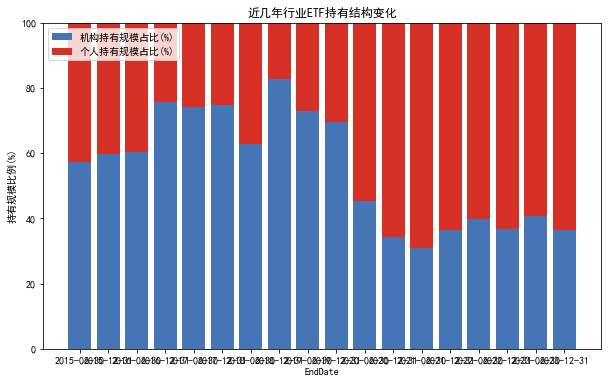

In [133]:
plt.figure(figsize=(10, 6))
plt.bar(jigougerenguimo.index, jigougerenguimo['机构比例'], color='#4575b4', label='机构持有规模占比(%)')
plt.bar(jigougerenguimo.index, jigougerenguimo['个人比例'], bottom=jigougerenguimo['机构比例'], color='#d73027', label='个人持有规模占比(%)')
plt.xlabel('EndDate')
plt.ylabel('持有规模比例(%)')
plt.title('近几年行业ETF持有结构变化')
plt.legend(loc='upper left')
plt.ylim(0, 100)

In [134]:
jigougerenguimo.to_excel(excel_writer, sheet_name='机构与个人总规模时序变化')

In [135]:
excel_writer.save()
excel_writer.close()

In [136]:
composites=feilianjie1.copy()
composites.drop(columns='市值亿元',inplace=True)
composites

,证券代码,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,成立日期
0,159301.OF,2024-07-17,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10
1,159306.OF,2024-05-09,2024-05-07,50553150.0,199691466.0,0.202015,0.797985,平安中证汽车零部件主题ETF,中游制造,2024-04-29
2,159309.OF,2024-06-13,2024-06-11,19108757.0,422262979.0,0.043294,0.956706,汇添富中证油气资源ETF,周期,2024-05-31
3,159310.OF,2024-04-25,2024-04-23,55387064.0,178594016.0,0.236716,0.763284,天弘中证芯片产业ETF,科技,2024-04-18
4,159315.OF,2024-06-11,2024-06-06,25346664.0,385742957.0,0.061657,0.938343,工银中证沪深港黄金产业股票ETF,周期,2024-05-30
...,...,...,...,...,...,...,...,...,...,...
2645,588290.OF,2023-03-30,2022-12-31,48091400.0,50805600.0,0.486278,0.513722,华安上证科创板芯片ETF,科技,2022-09-30
2646,588290.OF,2023-08-30,2023-06-30,604838097.0,356558903.0,0.506719,0.493281,华安上证科创板芯片ETF,科技,2022-09-30
2647,588290.OF,2024-03-27,2023-12-31,693196621.0,413200379.0,0.455930,0.544070,华安上证科创板芯片ETF,科技,2022-09-30
2648,588700.OF,2024-01-02,2023-12-28,113663974.0,234172204.0,0.326774,0.673226,嘉实上证科创板生物医药ETF,医药医疗,2023-12-27


In [137]:
def merge_and_fill(df1, df2):
    result_df = pd.merge(df1, df2, on=['证券代码', 'TradingDay'], how='outer')
    result_df.sort_values(by=['证券代码', 'TradingDay'], inplace=True)
    result_df.reset_index(drop=True, inplace=True)
    name = result_df['证券代码']
    result_df = result_df.groupby('证券代码').ffill()
    result_df['证券代码'] = name
    result_df.dropna(inplace=True)
    result_df.reset_index(drop=True, inplace=True)
    conditions = [
        result_df['机构比例'] >= 0.65,
        result_df['机构比例'] <= 0.35,
        result_df['机构比例'].between(0.35, 0.65)
    ]
    choices = ['机构', '个人', '模糊']
    result_df['类别'] = np.select(conditions, choices, default=np.nan)
    return result_df

In [138]:
allreturn=merge_and_fill(composites,final_merged[['证券代码','TradingDay','权重*收益率']])
allreturn=pd.merge(allreturn,hangye1[['证券代码','证券简称','TradingDay','市值亿元']],on=['证券代码','证券简称','TradingDay']) #用TradingDay的市值
allreturn

,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,成立日期,权重*收益率,证券代码,类别,市值亿元
0,2024-07-22,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,-0.000253,159301.OF,模糊,2.295596
1,2024-07-23,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,-0.000129,159301.OF,模糊,1.259681
2,2024-07-24,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,0.000665,159301.OF,模糊,1.259892
3,2024-07-25,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,-0.000074,159301.OF,模糊,0.912906
4,2024-07-26,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,-0.000197,159301.OF,模糊,0.925508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
316002,2024-07-23,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,-0.000032,588890.OF,个人,0.488563
316003,2024-07-24,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,-0.000006,588890.OF,个人,0.483993
316004,2024-07-25,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,-0.000005,588890.OF,个人,0.512667
316005,2024-07-26,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,0.000005,588890.OF,个人,0.516683


In [139]:
allcash=merge_and_fill(composites,cash[['证券代码','TradingDay','资金变化(亿元)']])
allcash=pd.merge(allcash,hangye1[['证券代码','证券简称','TradingDay','市值亿元']],on=['证券代码','证券简称','TradingDay']) #用TradingDay的
allcash

,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,成立日期,资金变化(亿元),证券代码,类别,市值亿元
0,2024-07-22,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,0.000000,159301.OF,模糊,2.295596
1,2024-07-23,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,-1.026927,159301.OF,模糊,1.259681
2,2024-07-24,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,-0.025308,159301.OF,模糊,1.259892
3,2024-07-25,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,-0.343128,159301.OF,模糊,0.912906
4,2024-07-26,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,0.020020,159301.OF,模糊,0.925508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
316002,2024-07-23,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,0.032709,588890.OF,个人,0.488563
316003,2024-07-24,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,0.000000,588890.OF,个人,0.483993
316004,2024-07-25,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,0.032169,588890.OF,个人,0.512667
316005,2024-07-26,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,0.000000,588890.OF,个人,0.516683


In [140]:
allcashdiff=merge_and_fill(composites,cash_diff)
allcashdiff=pd.merge(allcashdiff,hangye1[['证券代码','证券简称','TradingDay','市值亿元']],on=['证券代码','证券简称','TradingDay']) #用TradingDay的
allcashdiff

,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,成立日期,资金变化(亿元)_diff,证券代码,类别,市值亿元
0,2024-07-23,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,-1.026927,159301.OF,模糊,1.259681
1,2024-07-24,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,1.001619,159301.OF,模糊,1.259892
2,2024-07-25,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,-0.317821,159301.OF,模糊,0.912906
3,2024-07-26,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,0.363148,159301.OF,模糊,0.925508
4,2024-07-29,2024-07-15,125984849.0,104473508.0,0.546671,0.453329,华夏中证全指公用事业ETF,周期,2024-07-10,-0.014997,159301.OF,模糊,0.933860
...,...,...,...,...,...,...,...,...,...,...,...,...,...
315619,2024-07-23,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,-0.001764,588890.OF,个人,0.488563
315620,2024-07-24,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,-0.032709,588890.OF,个人,0.483993
315621,2024-07-25,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,0.032169,588890.OF,个人,0.512667
315622,2024-07-26,2024-04-16,31949000.0,276861000.0,0.103458,0.896542,南方上证科创板芯片ETF,科技,2024-04-15,-0.032169,588890.OF,个人,0.516683


In [141]:
def process(process,cashh,cashh_diff):
    Return=process[['四级分类','TradingDay','权重*收益率']]
    Weighted_return=Return.pivot_table(index='TradingDay',columns='四级分类',values='权重*收益率',aggfunc='sum')
    Weighted_return.index=pd.to_datetime(Weighted_return.index)
    Cashtable=cashh.pivot_table(index='TradingDay',columns='证券代码',values='资金变化(亿元)',aggfunc='sum')
    Cashtablediff=cashh_diff.pivot_table(index='TradingDay',columns='证券代码',values='资金变化(亿元)_diff',aggfunc='sum')
    return Weighted_return,Cashtable,Cashtablediff

In [142]:
jigouWeighted_return,jigouCashtable,jigouCashtablediff=process(allreturn[allreturn['类别']=='机构'],allcash[allcash['类别']=='机构'],allcashdiff[allcashdiff['类别']=='机构'])
mohuWeighted_return,mohuCashtable,mohuCashtablediff=process(allreturn[allreturn['类别']=='模糊'],allcash[allcash['类别']=='模糊'],allcashdiff[allcashdiff['类别']=='模糊'])
gerenWeighted_return,gerenCashtable,gerenCashtablediff=process(allreturn[allreturn['类别']=='个人'],allcash[allcash['类别']=='个人'],allcashdiff[allcashdiff['类别']=='个人'])

In [143]:
jigouCashtable

证券代码,159503.OF,159538.OF,159565.OF,159635.OF,159653.OF,159663.OF,159695.OF,159701.OF,159707.OF,159719.OF,...,561120.OF,561170.OF,561260.OF,561330.OF,561790.OF,562380.OF,562850.OF,562900.OF,562950.OF,588100.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2013-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-04-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-04-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,NaN,-0.008377,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,-0.030414,...,0.013716,0.011292,-0.015712,0.009012,0.000000,0.000000,-0.022502,NaN,NaN,NaN
2024-07-24,NaN,-0.008300,0.009022,NaN,NaN,NaN,0.048850,NaN,NaN,-0.015402,...,0.000000,-0.005746,-0.027240,0.000000,-0.034188,0.000000,-0.011378,NaN,NaN,NaN
2024-07-25,NaN,0.000000,0.027042,NaN,NaN,NaN,-0.009605,NaN,NaN,-0.030286,...,0.000000,0.000000,-0.009014,0.000000,-0.022628,0.000000,-0.033888,NaN,NaN,NaN


In [144]:
mohuCashtable

证券代码,159301.OF,159321.OF,159322.OF,159507.OF,159512.OF,159537.OF,159539.OF,159540.OF,159546.OF,159558.OF,...,562880.OF,562900.OF,562930.OF,562950.OF,562960.OF,563010.OF,588100.OF,588200.OF,588260.OF,588290.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2013-03-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,-1.026927,0.000000,0.0,0.000000,0.022868,0.000000,0.0,0.0,0.000000,-0.019140,...,NaN,0.000000,0.000000,0.019842,-0.005618,0.000000,-0.093198,NaN,0.0,-0.285510
2024-07-24,-0.025308,0.000000,0.0,0.000000,-0.022208,0.000000,0.0,0.0,0.035148,0.009396,...,NaN,0.000000,0.000000,0.006524,0.000000,0.000000,0.000000,NaN,0.0,-0.141420
2024-07-25,-0.343128,0.000000,0.0,0.000000,0.000000,-0.008143,0.0,0.0,0.008679,0.000000,...,NaN,0.000000,0.000000,0.019311,-0.011400,0.000000,0.000000,NaN,0.0,0.023402


In [145]:
gerenCashtable

证券代码,159306.OF,159309.OF,159310.OF,159315.OF,159503.OF,159507.OF,159508.OF,159511.OF,159512.OF,159516.OF,...,562930.OF,562990.OF,563010.OF,563050.OF,563150.OF,588100.OF,588200.OF,588260.OF,588700.OF,588890.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2013-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-04-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,-0.017178,-0.037972,0.0,-0.059148,NaN,NaN,-0.012863,-0.004364,NaN,-0.041040,...,NaN,0.000000,NaN,-0.030052,-0.009200,NaN,0.116808,NaN,0.0,0.032709
2024-07-24,0.016740,-0.009493,0.0,-0.009886,NaN,NaN,-0.004231,0.000000,NaN,-0.080470,...,NaN,-0.006868,NaN,0.000000,-0.009200,NaN,-4.512924,NaN,0.0,0.000000
2024-07-25,0.000000,0.000000,0.0,-0.009406,NaN,NaN,0.000000,0.000000,NaN,0.031944,...,NaN,0.000000,NaN,-0.007479,-0.009064,NaN,-1.752042,NaN,0.0,0.032169


In [146]:
def process_data(Cashtable, Cashtablediff, Weekly, market_value):
    
    # Step 1: Calculate Weekly_Cash and Weekly_Cashdiff
    summary_results = []
    summary_resultsdiff = []

    def custom_sum(series):
        if series.isna().any():
            return np.nan
        return series.sum()

    # 处理 Weekly_Cash 数据
    first_period_data = Cashtable[Cashtable.index < Weekly[0]]
    if first_period_data.empty:
        first_period_sum = pd.Series([np.nan] * Cashtable.shape[1], index=Cashtable.columns)
    else:
        first_period_sum = first_period_data.apply(custom_sum)
    first_period_sum.name = f"before {Weekly[0]}"
    summary_results.append(first_period_sum)

    for i in range(1, len(Weekly)):
        period_data = Cashtable[(Cashtable.index > Weekly[i-1]) & (Cashtable.index <= Weekly[i])]
        if period_data.empty:
            period_sum = pd.Series([np.nan] * Cashtable.shape[1], index=Cashtable.columns)
        else:
            period_sum = period_data.apply(custom_sum)
        period_sum.name = f"{Weekly[i-1]} to {Weekly[i]}"
        summary_results.append(period_sum)

    Weekly_Cash = pd.DataFrame(summary_results)
    Weekly_Cash.index = Weekly

    # 处理 Weekly_Cashdiff 数据
    first_period_datadiff = Cashtablediff[Cashtablediff.index < Weekly[0]]
    if first_period_datadiff.empty:
        first_period_sumdiff = pd.Series([np.nan] * Cashtablediff.shape[1], index=Cashtablediff.columns)
    else:
        first_period_sumdiff = first_period_datadiff.apply(custom_sum)
    first_period_sumdiff.name = f"before {Weekly[0]}"
    summary_resultsdiff.append(first_period_sumdiff)

    for i in range(1, len(Weekly)):
        period_datadiff = Cashtablediff[(Cashtablediff.index > Weekly[i-1]) & (Cashtablediff.index <= Weekly[i])]
        if period_datadiff.empty:
            period_sumdiff = pd.Series([np.nan] * Cashtablediff.shape[1], index=Cashtablediff.columns)
        else:
            period_sumdiff = period_datadiff.apply(custom_sum)
        period_sumdiff.name = f"{Weekly[i-1]} to {Weekly[i]}"
        summary_resultsdiff.append(period_sumdiff)

    Weekly_Cashdiff = pd.DataFrame(summary_resultsdiff)
    Weekly_Cashdiff.index = Weekly

    # Step 2: Calculate rolling windows
    rolling_windows_results = {}
    rolling_windows_resultsdiff = {}

    for window_size in range(1, 53):
        rolling_sum = Weekly_Cash.rolling(window=window_size).sum()
        rolling_windows_results[window_size] = rolling_sum
        rolling_sumdiff = Weekly_Cashdiff.rolling(window=window_size).sum()
        rolling_windows_resultsdiff[window_size] = rolling_sumdiff

    # Step 3: Create Factorprocessdict and Factorprocessdiffdict
    Factorprocessdict = {}
    Factorprocessdiffdict = {}

    for window_size, Weekly_Cash in rolling_windows_results.items():
        ETFweekcash = Weekly_Cash.T.stack().reset_index()
        ETFweekcash.rename(columns={'level_1':'TradingDay', 0:'资金变化(亿元)'}, inplace=True)
        Factorprocess = pd.merge(ETFweekcash, market_value, on=['证券代码', 'TradingDay'], how='inner')
        Factorprocessdict[window_size] = Factorprocess
    
    for window_size, Weekly_Cashdiff in rolling_windows_resultsdiff.items():
        ETFweekcashdiff = Weekly_Cashdiff.T.stack().reset_index()
        ETFweekcashdiff.rename(columns={'level_1':'TradingDay', 0:'资金变化(亿元)_diff'}, inplace=True)
        Factorprocessdiff = pd.merge(ETFweekcashdiff, market_value, on=['证券代码', 'TradingDay'], how='inner')
        Factorprocessdiffdict[window_size] = Factorprocessdiff

    # Step 4: Neutralization function
    def neutral_fun(sortred, factorname):
        sorted_ = sortred.sort_values(by='TradingDay')
        sorted_ .dropna(inplace=True)
        dates = list(set(sorted_['TradingDay']))
        dates.sort()
        residuals = []
        for date in dates:
            filtered = sorted_[sorted_['TradingDay'] == date]
            X = pd.DataFrame(filtered['市值亿元']).reset_index(drop=True)
            Y = pd.DataFrame(filtered[factorname]).reset_index(drop=True)
            fitted = sm.OLS(Y, X).fit()
            fitted_values = fitted.fittedvalues   
            fitted_values = pd.DataFrame(fitted_values, columns=[factorname])
            residual = Y - fitted_values
            residual = residual[factorname].tolist()
            residuals.extend(residual)
        return residuals

    # Step 5: Neutralize Factorprocessdict and Factorprocessdiffdict
    Factorprocessdict_neutralized1 = {}
    Factorprocessdiffdict_neutralized1 = {}

    for window_size, Factorprocess in Factorprocessdict.items():
        residuals = neutral_fun(Factorprocess, '资金变化(亿元)')
        Factorprocess['中性化'] = residuals
        Factorprocessdict_neutralized1[window_size] = Factorprocess

    for window_size, Factorprocessdiff in Factorprocessdiffdict.items():
        residuals = neutral_fun(Factorprocessdiff, '资金变化(亿元)_diff')
        Factorprocessdiff['中性化'] = residuals
        Factorprocessdiffdict_neutralized1[window_size] = Factorprocessdiff

    # Step 6: Calculate Cash
    def calculate_cash(value):
        Cash = value.groupby(['四级分类','TradingDay']).sum(numeric_only=True)['中性化'].reset_index()
        Cashtable = Cash.pivot_table(index='TradingDay',columns='四级分类',values='中性化',aggfunc='sum')
        Cashtable.index = pd.to_datetime(Cashtable.index)
        return Cashtable

    Factorprocessdict_Cash = {key: calculate_cash(value) for key, value in Factorprocessdict_neutralized1.items()}
    Factorprocessdiffdict_Cashdiff = {key: calculate_cash(value) for key, value in Factorprocessdiffdict_neutralized1.items()}

    # Return the final dictionaries
    return Factorprocessdict_Cash, Factorprocessdiffdict_Cashdiff

In [147]:
jigouFactorprocessdict_Cash,jigouFactorprocessdict_Cashdiff=process_data(jigouCashtable,jigouCashtablediff,Weekly,market_value)
mohuFactorprocessdict_Cash,mohuFactorprocessdict_Cashdiff=process_data(mohuCashtable,mohuCashtablediff,Weekly,market_value)
gerenFactorprocessdict_Cash,gerenFactorprocessdict_Cashdiff=process_data(gerenCashtable,gerenCashtablediff,Weekly,market_value)

In [148]:
pathjigou=r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\机构52个因子'
pathjigou1=r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\机构差分52个因子'
pathmohu=r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\模糊52个因子'
pathmohu1=r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\模糊差分52个因子'
pathgeren=r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\个人52个因子'
pathgeren1=r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\个人差分52个因子'

In [149]:
out_dicts = {
    'jigouFactorprocessdict_Cash': (jigouFactorprocessdict_Cash, pathjigou),
    'jigouFactorprocessdict_Cashdiff': (jigouFactorprocessdict_Cashdiff, pathjigou1),
    'mohuFactorprocessdict_Cash': (mohuFactorprocessdict_Cash, pathmohu),
    'mohuFactorprocessdict_Cashdiff': (mohuFactorprocessdict_Cashdiff, pathmohu1),
    'gerenFactorprocessdict_Cash': (gerenFactorprocessdict_Cash, pathgeren),
    'gerenFactorprocessdict_Cashdiff': (gerenFactorprocessdict_Cashdiff, pathgeren1)
}

for key, (df_dict, path) in out_dicts.items():
    for key, df in df_dict.items():
        file_name = f'{key}.csv'
        df.to_csv(f'{path}/{file_name}', index=True)
        print(f'Saved: {file_name}')

Saved: 1.csv
Saved: 2.csv
Saved: 3.csv
Saved: 4.csv
Saved: 5.csv
Saved: 6.csv
Saved: 7.csv
Saved: 8.csv
Saved: 9.csv
Saved: 10.csv
Saved: 11.csv
Saved: 12.csv
Saved: 13.csv
Saved: 14.csv
Saved: 15.csv
Saved: 16.csv
Saved: 17.csv
Saved: 18.csv
Saved: 19.csv
Saved: 20.csv
Saved: 21.csv
Saved: 22.csv
Saved: 23.csv
Saved: 24.csv
Saved: 25.csv
Saved: 26.csv
Saved: 27.csv
Saved: 28.csv
Saved: 29.csv
Saved: 30.csv
Saved: 31.csv
Saved: 32.csv
Saved: 33.csv
Saved: 34.csv
Saved: 35.csv
Saved: 36.csv
Saved: 37.csv
Saved: 38.csv
Saved: 39.csv
Saved: 40.csv
Saved: 41.csv
Saved: 42.csv
Saved: 43.csv
Saved: 44.csv
Saved: 45.csv
Saved: 46.csv
Saved: 47.csv
Saved: 48.csv
Saved: 49.csv
Saved: 50.csv
Saved: 51.csv
Saved: 52.csv
Saved: 1.csv
Saved: 2.csv
Saved: 3.csv
Saved: 4.csv
Saved: 5.csv
Saved: 6.csv
Saved: 7.csv
Saved: 8.csv
Saved: 9.csv
Saved: 10.csv
Saved: 11.csv
Saved: 12.csv
Saved: 13.csv
Saved: 14.csv
Saved: 15.csv
Saved: 16.csv
Saved: 17.csv
Saved: 18.csv
Saved: 19.csv
Saved: 20.csv
Saved: 21.

In [150]:
def process_and_save_ic(factor_process_dict, cumulative_return_week4, cumulative_return_week12, cumulative_return_week24, diff_factor_process_dict, file_path_ic, file_path_diff_ic):
    ICweek3, factor_ic_week_dict3 = calculate_ic(factor_process_dict, cumulative_return_week4)
    ICweek4, factor_ic_week_dict4 = calculate_ic(factor_process_dict, cumulative_return_week12)
    ICweek5, factor_ic_week_dict5 = calculate_ic(factor_process_dict, cumulative_return_week24)
    
    ICweek3d, factor_ic_week_dict3d = calculate_ic(diff_factor_process_dict, cumulative_return_week4)
    ICweek4d, factor_ic_week_dict4d = calculate_ic(diff_factor_process_dict, cumulative_return_week12)
    ICweek5d, factor_ic_week_dict5d = calculate_ic(diff_factor_process_dict, cumulative_return_week24)
    
    with pd.ExcelWriter(file_path_ic) as writer:
        ICweek3.to_excel(writer, sheet_name='四周IC')
        ICweek4.to_excel(writer, sheet_name='12周IC')
        ICweek5.to_excel(writer, sheet_name='24周IC')
        
    with pd.ExcelWriter(file_path_diff_ic) as writer:
        ICweek3d.to_excel(writer, sheet_name='四周IC')
        ICweek4d.to_excel(writer, sheet_name='12周IC')
        ICweek5d.to_excel(writer, sheet_name='24周IC')
    return (factor_ic_week_dict3, factor_ic_week_dict4, factor_ic_week_dict5, 
            factor_ic_week_dict3d, factor_ic_week_dict4d, factor_ic_week_dict5d)

jigou4, jigou12, jigou24, jigou4d, jigou12d, jigou24d = process_and_save_ic(
    jigouFactorprocessdict_Cash,
    cumulative_return_week4,
    cumulative_return_week12,
    cumulative_return_week24,
    jigouFactorprocessdict_Cashdiff,
    r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\机构ICweeks.xlsx',
    r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\机构差分ICweeks.xlsx'
)

mohu4, mohu12, mohu24, mohu4d, mohu12d, mohu24d = process_and_save_ic(
    mohuFactorprocessdict_Cash,
    cumulative_return_week4,
    cumulative_return_week12,
    cumulative_return_week24,
    mohuFactorprocessdict_Cashdiff,
    r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\模糊ICweeks.xlsx',
    r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\模糊差分ICweeks.xlsx'
)

geren4, geren12, geren24, geren4d, geren12d, geren24d = process_and_save_ic(
    gerenFactorprocessdict_Cash,
    cumulative_return_week4,
    cumulative_return_week12,
    cumulative_return_week24,
    gerenFactorprocessdict_Cashdiff,
    r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\个人ICweeks.xlsx',
    r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\个人差分ICweeks.xlsx'
)

In [151]:
resultsmerge=pd.read_excel(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\画图结果\结果合集（手动合并).xlsx')
resultsmerge

,名字,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value,类型,预测周期
0,10周因子,0.053642,0.424884,0.126251,0.440928,0.006212,个人,4
1,9周因子,0.059512,0.449745,0.132325,0.438972,0.004433,个人,12
2,1周因子,0.069872,0.410002,0.170418,0.414687,0.000274,个人,24
3,22周因子,0.056890,0.468759,0.121363,0.419913,0.009387,个人差分,4
4,19周因子,0.051993,0.483040,0.107636,0.411236,0.023650,个人差分,24
5,42周因子,-0.061792,0.506149,-0.122082,0.561576,0.014315,个人差分,24
6,10周因子,0.052840,0.355827,0.148500,0.414163,0.001440,机构,12
7,46周因子,0.033634,0.377815,0.089023,0.406699,0.069463,机构,24
8,37周因子,0.038329,0.366892,0.104471,0.435080,0.029131,机构差分,12
9,25周因子,-0.070127,0.343910,-0.203911,0.578588,0.000024,机构差分,24


In [152]:
def map_table_names(df):
    mapping = {
        '个人': 'geren',
        '个人差分': 'geren',
        '机构': 'jigou',
        '机构差分': 'jigou',
        '模糊': 'mohu',
        '模糊差分': 'mohu',
        '行业': 'factor_ic_week_dict',
        '行业差分': 'factor_ic_week_dict'
    }
    def get_table_name(row):
        base_name = mapping[row['类型']]
        if '差分' in row['类型']:
            return f"{base_name}{row['预测周期']}d"
        else:
            return f"{base_name}{row['预测周期']}"
    df['表名'] = df.apply(get_table_name, axis=1)
    return df
def extract_weeks(name):
    return int(''.join(filter(str.isdigit, name)))

In [153]:
resultsmerge=map_table_names(resultsmerge)
resultsmerge['名字'] =resultsmerge['名字'].apply(extract_weeks)

In [154]:
resultsmerge

,名字,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value,类型,预测周期,表名
0,10,0.053642,0.424884,0.126251,0.440928,0.006212,个人,4,geren4
1,9,0.059512,0.449745,0.132325,0.438972,0.004433,个人,12,geren12
2,1,0.069872,0.410002,0.170418,0.414687,0.000274,个人,24,geren24
3,22,0.056890,0.468759,0.121363,0.419913,0.009387,个人差分,4,geren4d
4,19,0.051993,0.483040,0.107636,0.411236,0.023650,个人差分,24,geren24d
5,42,-0.061792,0.506149,-0.122082,0.561576,0.014315,个人差分,24,geren24d
6,10,0.052840,0.355827,0.148500,0.414163,0.001440,机构,12,jigou12
7,46,0.033634,0.377815,0.089023,0.406699,0.069463,机构,24,jigou24
8,37,0.038329,0.366892,0.104471,0.435080,0.029131,机构差分,12,jigou12d
9,25,-0.070127,0.343910,-0.203911,0.578588,0.000024,机构差分,24,jigou24d


In [155]:
dict_mapping = {
    'geren4': geren4,
    'geren12': geren12,
    'geren24': geren24,
    'geren4d': geren4d,
    'geren12d': geren12d,
    'geren24d': geren24d,
    'jigou4': jigou4,
    'jigou12': jigou12,
    'jigou24': jigou24,
    'jigou4d': jigou4d,
    'jigou12d': jigou12d,
    'jigou24d': jigou24d,
    'mohu4': mohu4,
    'mohu12': mohu12,
    'mohu24': mohu24,
    'mohu4d': mohu4d,
    'mohu12d': mohu12d,
    'mohu24d': mohu24d,
    'factor_ic_week_dict4': factor_ic_week_dict4,
    'factor_ic_week_dict12': factor_ic_week_dict12,
    'factor_ic_week_dict24': factor_ic_week_dict24,
    'factor_ic_week_dict4d': factor_ic_week_dict4d,
    'factor_ic_week_dict12d': factor_ic_week_dict12d,
    'factor_ic_week_dict24d': factor_ic_week_dict24d
}

In [156]:
output_dir=r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\结果\画图结果'

In [157]:
def process_and_plot(df, dict_mapping, output_dir):
    for _, row in df.iterrows():
        table_name = row['表名']
        key = row['名字']
        plot_type = row['类型']
        prediction_period = row['预测周期']
        data_dict = dict_mapping.get(table_name)
        if data_dict is not None and key in data_dict:
            data = data_dict[key][key]
            filename = f"{plot_type}-预测周期{prediction_period}-{key}周.png"
            filepath = os.path.join(output_dir, filename)
            plot_ic_chart(data, filepath)

In [158]:
process_and_plot(resultsmerge,dict_mapping,output_dir)

# 前10大持有人拆分

这段代码开始

In [159]:
Top=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\Top10.csv',index_col=0)
Top.drop_duplicates(subset=['SecuCode','InfoPublDate','SerialNumber','HolderName'],keep='last',inplace=True)
Top.rename(columns={'SecuCode':'证券代码'},inplace=True)
Top

,证券代码,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio
0,000009.OF,2018-03-30,2017-12-31,4,银行类机构,1.226588e+09,0.017849
1,000009.OF,2018-03-30,2017-12-31,5,银行类机构,1.022156e+09,0.014874
2,000009.OF,2018-03-30,2017-12-31,6,银行类机构,1.014304e+09,0.014760
3,000009.OF,2018-03-30,2017-12-31,7,信托类机构,7.517495e+08,0.010939
4,000009.OF,2018-03-30,2017-12-31,8,银行类机构,7.160422e+08,0.010420
...,...,...,...,...,...,...,...
244394,970196.OF,2024-07-31,2024-06-30,2,个人,4.715367e+06,0.020800
244395,970196.OF,2024-07-31,2024-06-30,3,个人,4.241674e+06,0.018700
244396,970196.OF,2024-07-31,2024-06-30,4,个人,3.946527e+06,0.017400
244397,970196.OF,2024-07-31,2024-06-30,5,个人,3.746199e+06,0.016500


In [160]:
Tops=pd.merge(Top,name1,on='证券代码',how='inner')
Tops['InfoPublDate']=Tops['InfoPublDate'].apply(lambda date: tradingday(date, datetime1))
Tops

,证券代码,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
0,159301.OF,2024-07-17,2024-07-15,1,上海证券－国泰君安证券股份有限公司－上海证券正和2号FOF单一资产管理计划,50000972.0,0.2170,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
1,159301.OF,2024-07-17,2024-07-15,2,上海秉昊私募基金管理有限公司－秉昊世涛3号私募证券投资基金,13999272.0,0.0607,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
2,159301.OF,2024-07-17,2024-07-15,3,齐麟,10000194.0,0.0434,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
3,159301.OF,2024-07-17,2024-07-15,4,上海烜鼎资产管理有限公司－烜鼎新纪元2号私募证券投资基金,10000194.0,0.0434,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
4,159301.OF,2024-07-17,2024-07-15,5,上海绰瑞私募基金管理有限公司－绰瑞北岳37号私募证券投资基金,10000194.0,0.0434,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29072,588890.OF,2024-04-18,2024-04-16,6,严俊,2000000.0,0.0065,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
29073,588890.OF,2024-04-18,2024-04-16,7,广州博牛私募证券投资管理有限公司－博牛诗悦尊享私募证券投资基金,2000000.0,0.0065,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
29074,588890.OF,2024-04-18,2024-04-16,8,蒋大年,2000000.0,0.0065,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
29075,588890.OF,2024-04-18,2024-04-16,9,广州红孩尔私募证券投资基金管理有限公司－红孩尔凯旋3号私募证券投资基金,2000000.0,0.0065,南方上证科创板芯片ETF,2024-04-15,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子


In [161]:
len(Tops['证券代码'].unique())

412

ETF联接不提供前10大，没法穿透

In [162]:
len(Tops[Tops['证券简称'].str.contains('联接')]['证券简称'].unique())  #ETF联接能拿到数据的只有5个

5

In [163]:
Tops=Tops[~Tops['证券简称'].str.contains('联接')]

In [164]:
filtered_topdates=Tops['EndDate'].sort_values().unique()
filtered_topdates=[date for date in filtered_topdates if date.endswith('06-30') or date.endswith('12-31')]
filtered_topdates

['2012-12-31',
 '2013-06-30',
 '2013-12-31',
 '2014-06-30',
 '2014-12-31',
 '2015-06-30',
 '2015-12-31',
 '2016-06-30',
 '2016-12-31',
 '2017-06-30',
 '2017-12-31',
 '2018-06-30',
 '2018-12-31',
 '2019-06-30',
 '2019-12-31',
 '2020-06-30',
 '2020-12-31',
 '2021-06-30',
 '2021-12-31',
 '2022-06-30',
 '2022-12-31',
 '2023-06-30',
 '2023-12-31']

In [165]:
filterdtops=Tops[Tops['EndDate'].isin(filtered_topdates)].reset_index(drop=True)
filterdtops.rename(columns={'EndDate':'TradingDay'},inplace=True)
filterdtops  #TradingDay只保留半年度date

,证券代码,InfoPublDate,TradingDay,SerialNumber,HolderName,HoldingVolume,HoldingRatio,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
0,159503.OF,2024-03-29,2023-12-31,1,中信建投证券股份有限公司,8026791.0,0.2244,鹏扬国证财富管理ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
1,159503.OF,2024-03-29,2023-12-31,8,彭志红,620000.0,0.0173,鹏扬国证财富管理ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
2,159503.OF,2024-03-29,2023-12-31,9,冯琤,396008.0,0.0111,鹏扬国证财富管理ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
3,159503.OF,2024-03-29,2023-12-31,10,罗赛,300037.0,0.0084,鹏扬国证财富管理ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
4,159503.OF,2024-03-29,2023-12-31,2,华泰证券股份有限公司,6056117.0,0.1693,鹏扬国证财富管理ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23716,588290.OF,2024-03-27,2023-12-31,10,方正证券股份有限公司,11792000.0,0.0107,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
23717,588290.OF,2024-03-27,2023-12-31,11,华泰证券股份有限公司－华安上证科创板芯片交易型开放式指数证券投资基金发起式联接基金,199571600.0,0.1804,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
23718,588290.OF,2024-03-27,2023-12-31,5,中国人寿资产管理有限公司,17417900.0,0.0157,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
23719,588290.OF,2024-03-27,2023-12-31,6,招商证券股份有限公司,17000568.0,0.0154,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子


In [166]:
len(filterdtops['证券代码'].unique())

365

In [167]:
Topvalue=pd.merge(market_value1,filterdtops[['证券代码','TradingDay','HoldingVolume','HolderName','HoldingRatio','四级分类']],on=['证券代码','TradingDay','四级分类'])
Topvalue['购买市值亿元']=Topvalue['市值亿元']*Topvalue['HoldingRatio']
Topvalue['TradingDay']=pd.to_datetime(Topvalue['TradingDay'])
Topvalue

,证券代码,TradingDay,四级分类,市值亿元,HoldingVolume,HolderName,HoldingRatio,购买市值亿元
0,159503.OF,2023-12-31,金融地产,0.353301,8026791.0,中信建投证券股份有限公司,0.2244,0.079281
1,159503.OF,2023-12-31,金融地产,0.353301,620000.0,彭志红,0.0173,0.006112
2,159503.OF,2023-12-31,金融地产,0.353301,396008.0,冯琤,0.0111,0.003922
3,159503.OF,2023-12-31,金融地产,0.353301,300037.0,罗赛,0.0084,0.002968
4,159503.OF,2023-12-31,金融地产,0.353301,6056117.0,华泰证券股份有限公司,0.1693,0.059814
...,...,...,...,...,...,...,...,...
23716,588290.OF,2023-12-31,科技,11.851725,11792000.0,方正证券股份有限公司,0.0107,0.126813
23717,588290.OF,2023-12-31,科技,11.851725,199571600.0,华泰证券股份有限公司－华安上证科创板芯片交易型开放式指数证券投资基金发起式联接基金,0.1804,2.138051
23718,588290.OF,2023-12-31,科技,11.851725,17417900.0,中国人寿资产管理有限公司,0.0157,0.186072
23719,588290.OF,2023-12-31,科技,11.851725,17000568.0,招商证券股份有限公司,0.0154,0.182517


In [168]:
recent_year_data = Topvalue[Topvalue['TradingDay'] >='2022-12-31']    
recent_year_data  

,证券代码,TradingDay,四级分类,市值亿元,HoldingVolume,HolderName,HoldingRatio,购买市值亿元
0,159503.OF,2023-12-31,金融地产,0.353301,8026791.0,中信建投证券股份有限公司,0.2244,0.079281
1,159503.OF,2023-12-31,金融地产,0.353301,620000.0,彭志红,0.0173,0.006112
2,159503.OF,2023-12-31,金融地产,0.353301,396008.0,冯琤,0.0111,0.003922
3,159503.OF,2023-12-31,金融地产,0.353301,300037.0,罗赛,0.0084,0.002968
4,159503.OF,2023-12-31,金融地产,0.353301,6056117.0,华泰证券股份有限公司,0.1693,0.059814
...,...,...,...,...,...,...,...,...
23716,588290.OF,2023-12-31,科技,11.851725,11792000.0,方正证券股份有限公司,0.0107,0.126813
23717,588290.OF,2023-12-31,科技,11.851725,199571600.0,华泰证券股份有限公司－华安上证科创板芯片交易型开放式指数证券投资基金发起式联接基金,0.1804,2.138051
23718,588290.OF,2023-12-31,科技,11.851725,17417900.0,中国人寿资产管理有限公司,0.0157,0.186072
23719,588290.OF,2023-12-31,科技,11.851725,17000568.0,招商证券股份有限公司,0.0154,0.182517


In [169]:
filtered_holder = recent_year_data[~recent_year_data['HolderName'].str.contains('联接|基金发起')].copy()  #因为无法获得联接基金前10，无法穿透，因此把联接基金这种作为持有人删掉
filtered_holder['简称']= filtered_holder['HolderName'].apply(lambda x: x.split('－')[0])
filtered_holder['简称']= filtered_holder['简称'].apply(lambda x: x.split('-')[0])
filtered_holder['简称']=filtered_holder['简称'].str.replace(r'\W+', '', regex=True).str.upper()
# filtered_holder['简称'] = filtered_holder['简称'].str.replace('管理有限公司|股份有限公司|有限责任公司', '有限公司', regex=True)
filtered_holder

,证券代码,TradingDay,四级分类,市值亿元,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,简称
0,159503.OF,2023-12-31,金融地产,0.353301,8026791.0,中信建投证券股份有限公司,0.2244,0.079281,中信建投证券股份有限公司
1,159503.OF,2023-12-31,金融地产,0.353301,620000.0,彭志红,0.0173,0.006112,彭志红
2,159503.OF,2023-12-31,金融地产,0.353301,396008.0,冯琤,0.0111,0.003922,冯琤
3,159503.OF,2023-12-31,金融地产,0.353301,300037.0,罗赛,0.0084,0.002968,罗赛
4,159503.OF,2023-12-31,金融地产,0.353301,6056117.0,华泰证券股份有限公司,0.1693,0.059814,华泰证券股份有限公司
...,...,...,...,...,...,...,...,...,...
23715,588290.OF,2023-12-31,科技,11.851725,12288000.0,简街香港有限公司－JSQB有限公司(R),0.0111,0.131554,简街香港有限公司
23716,588290.OF,2023-12-31,科技,11.851725,11792000.0,方正证券股份有限公司,0.0107,0.126813,方正证券股份有限公司
23718,588290.OF,2023-12-31,科技,11.851725,17417900.0,中国人寿资产管理有限公司,0.0157,0.186072,中国人寿资产管理有限公司
23719,588290.OF,2023-12-31,科技,11.851725,17000568.0,招商证券股份有限公司,0.0154,0.182517,招商证券股份有限公司


In [170]:
filtered_holder['HolderType'] = filtered_holder['简称'].apply(lambda x: '个人holder' if len(x) <= 3 else '机构holder')
filtered_holder

,证券代码,TradingDay,四级分类,市值亿元,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,简称,HolderType
0,159503.OF,2023-12-31,金融地产,0.353301,8026791.0,中信建投证券股份有限公司,0.2244,0.079281,中信建投证券股份有限公司,机构holder
1,159503.OF,2023-12-31,金融地产,0.353301,620000.0,彭志红,0.0173,0.006112,彭志红,个人holder
2,159503.OF,2023-12-31,金融地产,0.353301,396008.0,冯琤,0.0111,0.003922,冯琤,个人holder
3,159503.OF,2023-12-31,金融地产,0.353301,300037.0,罗赛,0.0084,0.002968,罗赛,个人holder
4,159503.OF,2023-12-31,金融地产,0.353301,6056117.0,华泰证券股份有限公司,0.1693,0.059814,华泰证券股份有限公司,机构holder
...,...,...,...,...,...,...,...,...,...,...
23715,588290.OF,2023-12-31,科技,11.851725,12288000.0,简街香港有限公司－JSQB有限公司(R),0.0111,0.131554,简街香港有限公司,机构holder
23716,588290.OF,2023-12-31,科技,11.851725,11792000.0,方正证券股份有限公司,0.0107,0.126813,方正证券股份有限公司,机构holder
23718,588290.OF,2023-12-31,科技,11.851725,17417900.0,中国人寿资产管理有限公司,0.0157,0.186072,中国人寿资产管理有限公司,机构holder
23719,588290.OF,2023-12-31,科技,11.851725,17000568.0,招商证券股份有限公司,0.0154,0.182517,招商证券股份有限公司,机构holder


In [171]:
filtered_holder.groupby(['HolderType','TradingDay']).sum(numeric_only=True)['购买市值亿元'].reset_index().groupby('HolderType').mean(numeric_only=True)

,购买市值亿元
HolderType,
个人holder,35.007784
机构holder,1041.828998


In [172]:
jigouholder=filtered_holder[filtered_holder['HolderType']=='机构holder'].copy()
jigouholder

,证券代码,TradingDay,四级分类,市值亿元,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,简称,HolderType
0,159503.OF,2023-12-31,金融地产,0.353301,8026791.0,中信建投证券股份有限公司,0.2244,0.079281,中信建投证券股份有限公司,机构holder
4,159503.OF,2023-12-31,金融地产,0.353301,6056117.0,华泰证券股份有限公司,0.1693,0.059814,华泰证券股份有限公司,机构holder
5,159503.OF,2023-12-31,金融地产,0.353301,5261905.0,招商证券股份有限公司,0.1471,0.051971,招商证券股份有限公司,机构holder
6,159503.OF,2023-12-31,金融地产,0.353301,3155210.0,申万宏源证券有限公司,0.0882,0.031161,申万宏源证券有限公司,机构holder
7,159503.OF,2023-12-31,金融地产,0.353301,2719536.0,中信证券股份有限公司,0.0760,0.026851,中信证券股份有限公司,机构holder
...,...,...,...,...,...,...,...,...,...,...
23715,588290.OF,2023-12-31,科技,11.851725,12288000.0,简街香港有限公司－JSQB有限公司(R),0.0111,0.131554,简街香港有限公司,机构holder
23716,588290.OF,2023-12-31,科技,11.851725,11792000.0,方正证券股份有限公司,0.0107,0.126813,方正证券股份有限公司,机构holder
23718,588290.OF,2023-12-31,科技,11.851725,17417900.0,中国人寿资产管理有限公司,0.0157,0.186072,中国人寿资产管理有限公司,机构holder
23719,588290.OF,2023-12-31,科技,11.851725,17000568.0,招商证券股份有限公司,0.0154,0.182517,招商证券股份有限公司,机构holder


In [173]:
yidabiaoqian=pd.read_excel(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\前10大打标签\行业ETF标签.xlsx',index_col=0)
yidabiaoqian

,简称,标签
HolderName,,
BARCLAYS BANK PLC,BARCLAYSBANKPLC有限公司,外资机构
BARCLAYSBANKPLC,BARCLAYSBANKPLC有限公司,外资机构
UBS AG,UBSAG有限公司,外资机构
UBSAG,UBSAG有限公司,外资机构
安邦人寿保险股份有限公司－保守型投资组合,安邦人寿保险有限公司,保险
...,...,...
珠海纽达投资管理有限公司－纽达投资利道永晟五号私募证券投资基金,珠海纽达投资有限公司,私募基金
铸锋资产管理(北京)有限公司－铸锋银锋2号私募证券投资基金,铸锋资产管理北京有限公司,私募基金
卓盈私募基金管理(北京)有限公司-卓盈进取十号私募证券投资基金,卓盈私募基金管理北京有限公司,私募基金


In [174]:
futureprocess=pd.merge(jigouholder.drop(columns=['简称']),yidabiaoqian,on='HolderName')
futureprocess

,证券代码,TradingDay,四级分类,市值亿元,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,HolderType,简称,标签
0,159503.OF,2023-12-31,金融地产,0.353301,8026791.0,中信建投证券股份有限公司,0.224400,0.079281,机构holder,中信建投证券有限公司,证券
1,159516.OF,2023-12-31,科技,8.685837,8242128.0,中信建投证券股份有限公司,0.008600,0.074698,机构holder,中信建投证券有限公司,证券
2,159537.OF,2023-12-31,科技,0.349286,6191193.0,中信建投证券股份有限公司,0.164500,0.057457,机构holder,中信建投证券有限公司,证券
3,159608.OF,2022-12-31,周期,1.591352,3268315.0,中信建投证券股份有限公司,0.015243,0.024257,机构holder,中信建投证券有限公司,证券
4,159608.OF,2023-06-30,周期,2.274141,3587568.0,中信建投证券股份有限公司,0.010600,0.024106,机构holder,中信建投证券有限公司,证券
...,...,...,...,...,...,...,...,...,...,...,...
7024,588200.OF,2023-06-30,科技,63.120629,45857300.0,上海运舟私募基金管理有限公司－运舟顺势2号私募证券投资基金,0.009000,0.568086,机构holder,上海运舟私募基金有限公司,私募基金
7025,588200.OF,2023-06-30,科技,63.120629,119442100.0,上海运舟私募基金管理有限公司－运舟成长精选1号私募证券投资基金,0.023600,1.489647,机构holder,上海运舟私募基金有限公司,私募基金
7026,588200.OF,2023-12-31,科技,68.697629,103168400.0,和谐健康保险股份有限公司－万能,0.016500,1.133511,机构holder,和谐健康保险有限公司,保险
7027,588200.OF,2023-12-31,科技,68.697629,52327100.0,上海运舟私募基金管理有限公司－运舟跨越2号私募证券投资基金,0.008400,0.577060,机构holder,上海运舟私募基金有限公司,私募基金


In [175]:
analysis_mean=futureprocess.groupby(['标签','TradingDay']).sum(numeric_only=True)['购买市值亿元'].reset_index().groupby('标签').mean(numeric_only=True)
analysis_mean.sort_values(by='购买市值亿元',ascending=False,inplace=True)
analysis_mean

,购买市值亿元
标签,
保险,451.477123
国资机构,283.558271
证券,107.030826
公募基金,82.138177
财务公司,60.077428
银行,20.386846
私募基金,14.858912
信托,13.649709
外资机构,6.906632


In [176]:
jingquedaojianchen=futureprocess.groupby(['标签','简称','TradingDay']).sum(numeric_only=True)['购买市值亿元'].reset_index().groupby(['标签','简称']).mean(numeric_only=True)
sortbiaoqian=jingquedaojianchen.groupby('标签', group_keys=False).apply(lambda x: x.sort_values('购买市值亿元', ascending=False).head(5))

In [177]:
sortbiaoqian

购买市值亿元
标签   简称                             
保险   中国平安人寿保险有限公司         195.237474
     中国人寿保险有限公司            98.920568
     天安人寿保险有限公司            24.972276
     华夏人寿保险有限公司            23.043392
     友邦人寿保险有限公司            21.078657
信托   华润深国投信托有限公司            6.331690
     中海信托有限公司               4.018991
     平安信托有限公司               3.510947
     昆仑信托有限公司               0.384564
     东莞信托有限公司               0.222899
公募基金 华夏基金有限公司              32.063091
     汇添富基金有限公司             14.343319
     博时基金有限公司               5.679774
     易方达基金有限公司              4.215811
     创金合信基金有限公司             4.010430
国资机构 中国石油天然气集团有限公司        113.929758
     中央汇金投资有限公司            24.584071
     申能集团有限公司              15.378093
     中车资本控股有限公司            14.461729
     长江三峡投资有限公司            14.343985
外资机构 香港中央结算有限公司             5.622811
     BARCLAYSBANKPLC有限公司    0.803560
     UBSAG有限公司              0.390032
     简街香港有限公司               0.270687
期货   上海东证期货有限公司             1.532675
     招商期货有限公司               1.153280
     中信期货有限公司               0.577153
     国贸期货有限公司               0.293684
     弘业期货有限公司               0.117210
私募基金 国新新格局北京私募证券基金有限公司     12.673717
     北京诚旸投资有限公司             3.086412
     广东粤财信托有限公司             1.575162
     上海运舟私募基金有限公司           1.317396
     广州翔云私募基金有限公司           0.881850
证券   中信证券有限公司              16.443694
     华泰证券有限公司              13.814335
     方正证券有限公司              10.465744
     招商证券有限公司               9.742201
     广发证券有限公司               6.950075
财务公司 上海华谊集团公司有限公司          12.056175
     光明食品集团有限公司             6.405528
     汉中航空工业集团有限公司           6.323040
     长电投资管理有限公司             5.738194
     上海久事集团有限公司             4.334526
银行   招商财富资管有限公司            15.139486
     恒丰银行有限公司               7.890484
     光大理财有限公司               1.949706
     招银理财有限公司               1.648886
     中国工商银行有限公司             1.234302

###  证明聚源数据是有效的

In [178]:
juyuanfenhao=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\聚源分好的类别标签.csv',index_col=0)
juyuanfenhao

,SecuCode,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio,Companycode,ParentCompany,ChiName,CompanyType,CompanyCval
0,000366.OF,2016-03-29,2015-12-31,3,招商证券股份有限公司,5.004600e+06,0.000873,2921,2921.0,招商证券股份有限公司,1110,10.0
1,000366.OF,2016-03-29,2015-12-31,10,汇添富基金－光大银行－添富－虢盛－定增双喜盛世添富牛28号资产管理计划,2.689849e+06,0.000469,5131,5131.0,汇添富基金管理股份有限公司,2100,12.0
2,000366.OF,2016-03-29,2015-12-31,9,YALEUNIVERSITY,3.012932e+06,0.000525,19913,19913.0,耶鲁大学,9953,5.0
3,000366.OF,2016-03-29,2015-12-31,1,东方证券股份有限公司,7.435684e+06,0.001296,41086,41086.0,东方证券股份有限公司,1110,12.0
4,000366.OF,2016-03-29,2015-12-31,7,光大证券股份有限公司,4.001562e+06,0.000698,41133,41133.0,光大证券股份有限公司,1110,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...
69748,750006.OF,2019-03-29,2018-12-31,1,华夏人寿保险股份有限公司-资本补充债,3.084565e+08,0.051910,22955,22955.0,华夏人寿保险股份有限公司,4110,6.0
69749,750006.OF,2019-03-29,2018-12-31,2,中国大地财产保险股份有限公司,3.026635e+08,0.050935,44004,44004.0,中国大地财产保险股份有限公司,4110,NaN
69750,750006.OF,2019-03-29,2018-12-31,9,安信乾宏投资有限公司,2.063042e+08,0.034719,202601,202601.0,安信乾宏投资有限公司,4500,NaN
69751,750006.OF,2019-03-29,2018-12-31,5,深圳市富德前海基础设施投资控股有限公司,2.998824e+08,0.050467,264559,264559.0,深圳市富德前海基础设施投资控股有限公司,9900,NaN


In [179]:
juyuanfenhao.drop_duplicates(subset=['SecuCode','InfoPublDate','SerialNumber','HolderName'],keep='last',inplace=True)
juyuanfenhao.rename(columns={'SecuCode':'证券代码'},inplace=True)
juyuanfenhao

,证券代码,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio,Companycode,ParentCompany,ChiName,CompanyType,CompanyCval
0,000366.OF,2016-03-29,2015-12-31,3,招商证券股份有限公司,5.004600e+06,0.000873,2921,2921.0,招商证券股份有限公司,1110,10.0
1,000366.OF,2016-03-29,2015-12-31,10,汇添富基金－光大银行－添富－虢盛－定增双喜盛世添富牛28号资产管理计划,2.689849e+06,0.000469,5131,5131.0,汇添富基金管理股份有限公司,2100,12.0
2,000366.OF,2016-03-29,2015-12-31,9,YALEUNIVERSITY,3.012932e+06,0.000525,19913,19913.0,耶鲁大学,9953,5.0
3,000366.OF,2016-03-29,2015-12-31,1,东方证券股份有限公司,7.435684e+06,0.001296,41086,41086.0,东方证券股份有限公司,1110,12.0
4,000366.OF,2016-03-29,2015-12-31,7,光大证券股份有限公司,4.001562e+06,0.000698,41133,41133.0,光大证券股份有限公司,1110,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...
69748,750006.OF,2019-03-29,2018-12-31,1,华夏人寿保险股份有限公司-资本补充债,3.084565e+08,0.051910,22955,22955.0,华夏人寿保险股份有限公司,4110,6.0
69749,750006.OF,2019-03-29,2018-12-31,2,中国大地财产保险股份有限公司,3.026635e+08,0.050935,44004,44004.0,中国大地财产保险股份有限公司,4110,NaN
69750,750006.OF,2019-03-29,2018-12-31,9,安信乾宏投资有限公司,2.063042e+08,0.034719,202601,202601.0,安信乾宏投资有限公司,4500,NaN
69751,750006.OF,2019-03-29,2018-12-31,5,深圳市富德前海基础设施投资控股有限公司,2.998824e+08,0.050467,264559,264559.0,深圳市富德前海基础设施投资控股有限公司,9900,NaN


In [180]:
juyuanfenhaos=pd.merge(juyuanfenhao,name1,on='证券代码',how='inner')
juyuanfenhaos['InfoPublDate']=juyuanfenhaos['InfoPublDate'].apply(lambda date: tradingday(date, datetime1))
juyuanfenhaos

,证券代码,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio,Companycode,ParentCompany,ChiName,...,CompanyCval,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
0,159301.OF,2024-07-17,2024-07-15,7,西南证券股份有限公司,7000136.0,0.0304,1350,1350.0,西南证券股份有限公司,...,12.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
1,159301.OF,2024-07-17,2024-07-15,1,上海证券－国泰君安证券股份有限公司－上海证券正和2号FOF单一资产管理计划,50000972.0,0.2170,2726,2726.0,国泰君安证券股份有限公司,...,12.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
2,159301.OF,2024-07-17,2024-07-15,10,中国银河证券股份有限公司,5000097.0,0.0217,41126,41126.0,中国银河证券股份有限公司,...,10.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
3,159301.OF,2024-07-17,2024-07-15,6,华泰证券股份有限公司,7000136.0,0.0304,41136,41136.0,华泰证券股份有限公司,...,12.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
4,159306.OF,2024-05-09,2024-05-07,1,上海证券－国君资管3189FOF单一资产管理计划－上海证券护航FOF单一资产管理计划,32001244.0,0.1279,41644,41644.0,上海证券有限责任公司,...,12.0,平安中证汽车零部件主题ETF,2024-04-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,中游制造,汽车,汽车
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15105,588290.OF,2024-03-27,2023-12-31,7,财通证券股份有限公司,16184632.0,0.0146,2012,2012.0,财通证券股份有限公司,...,12.0,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
15106,588700.OF,2024-01-02,2023-12-28,1,上海证券－国泰君安证券股份有限公司－上海证券正和2号FOF单一资产管理计划,30000000.0,0.0862,2726,2726.0,国泰君安证券股份有限公司,...,12.0,嘉实上证科创板生物医药ETF,2023-12-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技
15107,588700.OF,2024-01-02,2023-12-28,11,上海思勰投资管理有限公司－思勰投资安欣九号私募证券投资基金,3000000.0,0.0086,234645,234645.0,上海思勰投资管理有限公司,...,NaN,嘉实上证科创板生物医药ETF,2023-12-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技
15108,588700.OF,2024-01-02,2023-12-28,6,上海思勰投资管理有限公司－思勰投资安欣八号一期私募证券投资基金,4000000.0,0.0115,234645,234645.0,上海思勰投资管理有限公司,...,NaN,嘉实上证科创板生物医药ETF,2023-12-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技


In [181]:
len(juyuanfenhaos['证券代码'].unique())

408

In [182]:
juyuanfenhaos=juyuanfenhaos[~juyuanfenhaos['证券简称'].str.contains('联接')]
juyuanfenhaos = juyuanfenhaos[juyuanfenhaos['EndDate'] >='2022-12-31']    
juyuanwulianjie=juyuanfenhaos[~juyuanfenhaos['HolderName'].str.contains('联接|基金发起')].copy()
juyuanwulianjie

,证券代码,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio,Companycode,ParentCompany,ChiName,...,CompanyCval,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
0,159301.OF,2024-07-17,2024-07-15,7,西南证券股份有限公司,7000136.0,0.0304,1350,1350.0,西南证券股份有限公司,...,12.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
1,159301.OF,2024-07-17,2024-07-15,1,上海证券－国泰君安证券股份有限公司－上海证券正和2号FOF单一资产管理计划,50000972.0,0.2170,2726,2726.0,国泰君安证券股份有限公司,...,12.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
2,159301.OF,2024-07-17,2024-07-15,10,中国银河证券股份有限公司,5000097.0,0.0217,41126,41126.0,中国银河证券股份有限公司,...,10.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
3,159301.OF,2024-07-17,2024-07-15,6,华泰证券股份有限公司,7000136.0,0.0304,41136,41136.0,华泰证券股份有限公司,...,12.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
4,159306.OF,2024-05-09,2024-05-07,1,上海证券－国君资管3189FOF单一资产管理计划－上海证券护航FOF单一资产管理计划,32001244.0,0.1279,41644,41644.0,上海证券有限责任公司,...,12.0,平安中证汽车零部件主题ETF,2024-04-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,中游制造,汽车,汽车
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15105,588290.OF,2024-03-27,2023-12-31,7,财通证券股份有限公司,16184632.0,0.0146,2012,2012.0,财通证券股份有限公司,...,12.0,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
15106,588700.OF,2024-01-02,2023-12-28,1,上海证券－国泰君安证券股份有限公司－上海证券正和2号FOF单一资产管理计划,30000000.0,0.0862,2726,2726.0,国泰君安证券股份有限公司,...,12.0,嘉实上证科创板生物医药ETF,2023-12-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技
15107,588700.OF,2024-01-02,2023-12-28,11,上海思勰投资管理有限公司－思勰投资安欣九号私募证券投资基金,3000000.0,0.0086,234645,234645.0,上海思勰投资管理有限公司,...,NaN,嘉实上证科创板生物医药ETF,2023-12-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技
15108,588700.OF,2024-01-02,2023-12-28,6,上海思勰投资管理有限公司－思勰投资安欣八号一期私募证券投资基金,4000000.0,0.0115,234645,234645.0,上海思勰投资管理有限公司,...,NaN,嘉实上证科创板生物医药ETF,2023-12-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技


In [183]:
juyuanwulianjie=juyuanwulianjie[juyuanwulianjie['EndDate'].isin(filtered_topdates)].reset_index(drop=True).copy()
juyuanwulianjie.rename(columns={'EndDate':'TradingDay'},inplace=True)
juyuanwulianjievalue=pd.merge(market_value1,juyuanwulianjie[['证券代码','TradingDay','HoldingVolume','HolderName','HoldingRatio','四级分类','CompanyType']],on=['证券代码','TradingDay','四级分类'])
juyuanwulianjievalue['购买市值亿元']=juyuanwulianjievalue['市值亿元']*juyuanwulianjievalue['HoldingRatio']
juyuanwulianjievalue['TradingDay']=pd.to_datetime(juyuanwulianjievalue['TradingDay'])
juyuanwulianjievalue

,证券代码,TradingDay,四级分类,市值亿元,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元
0,159503.OF,2023-12-31,金融地产,0.353301,3155210.0,申万宏源证券有限公司,0.0882,1110,0.031161
1,159503.OF,2023-12-31,金融地产,0.353301,6056117.0,华泰证券股份有限公司,0.1693,1110,0.059814
2,159503.OF,2023-12-31,金融地产,0.353301,1113800.0,华泰证券股份有限公司,0.0311,1110,0.010988
3,159503.OF,2023-12-31,金融地产,0.353301,8026791.0,中信建投证券股份有限公司,0.2244,1110,0.079281
4,159503.OF,2023-12-31,金融地产,0.353301,2719536.0,中信证券股份有限公司,0.0760,1110,0.026851
...,...,...,...,...,...,...,...,...,...
6116,588290.OF,2023-12-31,科技,11.851725,27773500.0,大家人寿保险股份有限公司－分红产品,0.0251,4110,0.297478
6117,588290.OF,2023-12-31,科技,11.851725,13001042.0,广发证券股份有限公司,0.0118,1110,0.139850
6118,588290.OF,2023-12-31,科技,11.851725,37186900.0,国泰君安证券股份有限公司,0.0336,1110,0.398218
6119,588290.OF,2023-12-31,科技,11.851725,17000568.0,招商证券股份有限公司,0.0154,1110,0.182517


In [184]:
juyuanwulianjievalue[juyuanwulianjievalue['TradingDay']=='2023-12-31']['购买市值亿元'].sum()

968.6657847819379

In [185]:
Trial=juyuanwulianjievalue[juyuanwulianjievalue['CompanyType'].isin([4110,4120,4130,9914])]
Trial

,证券代码,TradingDay,四级分类,市值亿元,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元
7,159507.OF,2023-12-31,科技,0.858732,19999936.0,中国人寿资管-工商银行-国寿资产-FOF优选灵活1号保险资产管理产品,0.202100,4110,0.173550
21,159512.OF,2023-12-31,中游制造,0.719246,5452200.0,中国平安财产保险股份有限公司-传统-普通保险产品,0.078700,4110,0.056605
28,159516.OF,2023-12-31,科技,8.685837,16443100.0,中国平安人寿保险股份有限公司－分红－个险分红,0.017200,4110,0.149396
29,159516.OF,2023-12-31,科技,8.685837,12080400.0,中国平安人寿保险股份有限公司－自有资金,0.012600,4110,0.109442
63,159608.OF,2022-12-31,周期,1.591352,12736813.0,众安在线财产保险股份有限公司-自有资金,0.059404,4110,0.094533
...,...,...,...,...,...,...,...,...,...
6108,588290.OF,2023-06-30,科技,11.705970,26520100.0,中国平安人寿保险股份有限公司－分红－个险分红,0.027600,4110,0.323085
6112,588290.OF,2023-12-31,科技,11.851725,163319100.0,中国人寿保险股份有限公司,0.147600,4110,1.749315
6114,588290.OF,2023-12-31,科技,11.851725,35000000.0,中国人寿保险(集团)公司,0.031600,4110,0.374514
6115,588290.OF,2023-12-31,科技,11.851725,17417900.0,中国人寿资产管理有限公司,0.015700,4130,0.186072


In [186]:
Trial.groupby(['TradingDay']).sum(numeric_only=True)['购买市值亿元'].mean()

447.437612085496

In [187]:
juyuanwulianjie[['HolderName','ChiName','CompanyType']].drop_duplicates().to_excel(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\前10大打标签\聚源标签.xlsx')

这一段代码结束，它的目的，是在于验证聚源数据是有一定用的。这段代码的futureprocess在3.0.2中会出现，所以这段代码依旧要运行。我们主要在行业这段代码需要验证聚源数据合理性，在宽基代码就不需要再写这些代码。

### 底稿excel映射标签

In [188]:
Top=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\Top10.csv',index_col=0)
Top.drop_duplicates(subset=['SecuCode','InfoPublDate','SerialNumber','HolderName'],keep='last',inplace=True)
Top.rename(columns={'SecuCode':'证券代码'},inplace=True)
Top   #Topvalue是所有可以拿到数据的ETF前10大

,证券代码,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio
0,000009.OF,2018-03-30,2017-12-31,4,银行类机构,1.226588e+09,0.017849
1,000009.OF,2018-03-30,2017-12-31,5,银行类机构,1.022156e+09,0.014874
2,000009.OF,2018-03-30,2017-12-31,6,银行类机构,1.014304e+09,0.014760
3,000009.OF,2018-03-30,2017-12-31,7,信托类机构,7.517495e+08,0.010939
4,000009.OF,2018-03-30,2017-12-31,8,银行类机构,7.160422e+08,0.010420
...,...,...,...,...,...,...,...
244394,970196.OF,2024-07-31,2024-06-30,2,个人,4.715367e+06,0.020800
244395,970196.OF,2024-07-31,2024-06-30,3,个人,4.241674e+06,0.018700
244396,970196.OF,2024-07-31,2024-06-30,4,个人,3.946527e+06,0.017400
244397,970196.OF,2024-07-31,2024-06-30,5,个人,3.746199e+06,0.016500


In [189]:
Tops=pd.merge(Top,name1,on='证券代码',how='inner')
Tops['InfoPublDate']=Tops['InfoPublDate'].apply(lambda date: tradingday(date, datetime1))
Tops=Tops[~Tops['证券简称'].str.contains('联接')]

In [190]:
filtered_topdates=Tops['EndDate'].sort_values().unique()
filtered_topdates=[date for date in filtered_topdates if date.endswith('06-30') or date.endswith('12-31')]
filtered_topdates

['2012-12-31',
 '2013-06-30',
 '2013-12-31',
 '2014-06-30',
 '2014-12-31',
 '2015-06-30',
 '2015-12-31',
 '2016-06-30',
 '2016-12-31',
 '2017-06-30',
 '2017-12-31',
 '2018-06-30',
 '2018-12-31',
 '2019-06-30',
 '2019-12-31',
 '2020-06-30',
 '2020-12-31',
 '2021-06-30',
 '2021-12-31',
 '2022-06-30',
 '2022-12-31',
 '2023-06-30',
 '2023-12-31']

In [191]:
filterdtops=Tops[Tops['EndDate'].isin(filtered_topdates)].reset_index(drop=True)
filterdtops.rename(columns={'EndDate':'TradingDay'},inplace=True)
filterdtops  #TradingDay只保留半年度date

,证券代码,InfoPublDate,TradingDay,SerialNumber,HolderName,HoldingVolume,HoldingRatio,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
0,159503.OF,2024-03-29,2023-12-31,1,中信建投证券股份有限公司,8026791.0,0.2244,鹏扬国证财富管理ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
1,159503.OF,2024-03-29,2023-12-31,8,彭志红,620000.0,0.0173,鹏扬国证财富管理ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
2,159503.OF,2024-03-29,2023-12-31,9,冯琤,396008.0,0.0111,鹏扬国证财富管理ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
3,159503.OF,2024-03-29,2023-12-31,10,罗赛,300037.0,0.0084,鹏扬国证财富管理ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
4,159503.OF,2024-03-29,2023-12-31,2,华泰证券股份有限公司,6056117.0,0.1693,鹏扬国证财富管理ETF,2023-06-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,金融地产,金融综合,金融
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23716,588290.OF,2024-03-27,2023-12-31,10,方正证券股份有限公司,11792000.0,0.0107,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
23717,588290.OF,2024-03-27,2023-12-31,11,华泰证券股份有限公司－华安上证科创板芯片交易型开放式指数证券投资基金发起式联接基金,199571600.0,0.1804,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
23718,588290.OF,2024-03-27,2023-12-31,5,中国人寿资产管理有限公司,17417900.0,0.0157,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
23719,588290.OF,2024-03-27,2023-12-31,6,招商证券股份有限公司,17000568.0,0.0154,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子


In [192]:
Topvalue=pd.merge(market_value1,filterdtops[['证券代码','InfoPublDate','TradingDay','HoldingVolume','HolderName','HoldingRatio','四级分类']],on=['证券代码','TradingDay','四级分类'])
Topvalue['购买市值亿元']=Topvalue['市值亿元']*Topvalue['HoldingRatio']
Topvalue['TradingDay']=pd.to_datetime(Topvalue['TradingDay'])
Topvalue


,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,HoldingVolume,HolderName,HoldingRatio,购买市值亿元
0,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,8026791.0,中信建投证券股份有限公司,0.2244,0.079281
1,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,620000.0,彭志红,0.0173,0.006112
2,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,396008.0,冯琤,0.0111,0.003922
3,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,300037.0,罗赛,0.0084,0.002968
4,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,6056117.0,华泰证券股份有限公司,0.1693,0.059814
...,...,...,...,...,...,...,...,...,...
23716,588290.OF,2023-12-31,科技,11.851725,2024-03-27,11792000.0,方正证券股份有限公司,0.0107,0.126813
23717,588290.OF,2023-12-31,科技,11.851725,2024-03-27,199571600.0,华泰证券股份有限公司－华安上证科创板芯片交易型开放式指数证券投资基金发起式联接基金,0.1804,2.138051
23718,588290.OF,2023-12-31,科技,11.851725,2024-03-27,17417900.0,中国人寿资产管理有限公司,0.0157,0.186072
23719,588290.OF,2023-12-31,科技,11.851725,2024-03-27,17000568.0,招商证券股份有限公司,0.0154,0.182517


In [193]:
Top_holder = Topvalue[~Topvalue['HolderName'].str.contains('联接|基金发起')].copy() 
Top_holder 

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,HoldingVolume,HolderName,HoldingRatio,购买市值亿元
0,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,8026791.0,中信建投证券股份有限公司,0.2244,0.079281
1,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,620000.0,彭志红,0.0173,0.006112
2,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,396008.0,冯琤,0.0111,0.003922
3,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,300037.0,罗赛,0.0084,0.002968
4,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,6056117.0,华泰证券股份有限公司,0.1693,0.059814
...,...,...,...,...,...,...,...,...,...
23715,588290.OF,2023-12-31,科技,11.851725,2024-03-27,12288000.0,简街香港有限公司－JSQB有限公司(R),0.0111,0.131554
23716,588290.OF,2023-12-31,科技,11.851725,2024-03-27,11792000.0,方正证券股份有限公司,0.0107,0.126813
23718,588290.OF,2023-12-31,科技,11.851725,2024-03-27,17417900.0,中国人寿资产管理有限公司,0.0157,0.186072
23719,588290.OF,2023-12-31,科技,11.851725,2024-03-27,17000568.0,招商证券股份有限公司,0.0154,0.182517


In [194]:
Top_holder ['HolderType'] = Top_holder['HolderName'].apply(lambda x: '个人holder' if len(x) <= 3 else '机构holder')
Top_holder.drop_duplicates(subset=['证券代码','TradingDay','四级分类','InfoPublDate','HolderName'],keep='last',inplace=True) 

In [195]:
Top_jigou=Top_holder[Top_holder ['HolderType']=='机构holder']
Top_jigou.groupby('TradingDay').sum(numeric_only=True)['购买市值亿元']

TradingDay
2012-12-31       7.678733
2013-06-30       6.665798
2013-12-31      15.091903
2014-06-30      17.748399
2014-12-31      18.028146
2015-06-30      42.039065
2015-12-31      49.569476
2016-06-30      44.370869
2016-12-31     151.463535
2017-06-30     150.424917
2017-12-31     147.745146
2018-06-30     129.501473
2018-12-31     126.570483
2019-06-30     553.499630
2019-12-31     849.397373
2020-06-30     866.611802
2020-12-31     773.945571
2021-06-30     678.003911
2021-12-31     779.187258
2022-06-30     867.770828
2022-12-31     844.923236
2023-06-30    1215.016382
2023-12-31    1054.210106
Name: 购买市值亿元, dtype: float64

In [196]:
juyuanfenhao=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\聚源分好的类别标签.csv',index_col=0)
juyuanfenhao  #这是ETF中聚源给分好的类别

,SecuCode,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio,Companycode,ParentCompany,ChiName,CompanyType,CompanyCval
0,000366.OF,2016-03-29,2015-12-31,3,招商证券股份有限公司,5.004600e+06,0.000873,2921,2921.0,招商证券股份有限公司,1110,10.0
1,000366.OF,2016-03-29,2015-12-31,10,汇添富基金－光大银行－添富－虢盛－定增双喜盛世添富牛28号资产管理计划,2.689849e+06,0.000469,5131,5131.0,汇添富基金管理股份有限公司,2100,12.0
2,000366.OF,2016-03-29,2015-12-31,9,YALEUNIVERSITY,3.012932e+06,0.000525,19913,19913.0,耶鲁大学,9953,5.0
3,000366.OF,2016-03-29,2015-12-31,1,东方证券股份有限公司,7.435684e+06,0.001296,41086,41086.0,东方证券股份有限公司,1110,12.0
4,000366.OF,2016-03-29,2015-12-31,7,光大证券股份有限公司,4.001562e+06,0.000698,41133,41133.0,光大证券股份有限公司,1110,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...
69748,750006.OF,2019-03-29,2018-12-31,1,华夏人寿保险股份有限公司-资本补充债,3.084565e+08,0.051910,22955,22955.0,华夏人寿保险股份有限公司,4110,6.0
69749,750006.OF,2019-03-29,2018-12-31,2,中国大地财产保险股份有限公司,3.026635e+08,0.050935,44004,44004.0,中国大地财产保险股份有限公司,4110,NaN
69750,750006.OF,2019-03-29,2018-12-31,9,安信乾宏投资有限公司,2.063042e+08,0.034719,202601,202601.0,安信乾宏投资有限公司,4500,NaN
69751,750006.OF,2019-03-29,2018-12-31,5,深圳市富德前海基础设施投资控股有限公司,2.998824e+08,0.050467,264559,264559.0,深圳市富德前海基础设施投资控股有限公司,9900,NaN


In [197]:
juyuanfenhao.drop_duplicates(subset=['SecuCode','InfoPublDate','SerialNumber','HolderName'],keep='last',inplace=True)
juyuanfenhao.rename(columns={'SecuCode':'证券代码'},inplace=True)
juyuanfenhaos=pd.merge(juyuanfenhao,name1,on='证券代码',how='inner')
juyuanfenhaos=juyuanfenhaos[~juyuanfenhaos['证券简称'].str.contains('联接')]
juyuanfenhaos['InfoPublDate']=juyuanfenhaos['InfoPublDate'].apply(lambda date: tradingday(date, datetime1))
juyuanfenhaos

,证券代码,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio,Companycode,ParentCompany,ChiName,...,CompanyCval,证券简称,成立日期,按交易方式分类,一级分类,二级分类,三级分类,四级分类,五级分类,备注
0,159301.OF,2024-07-17,2024-07-15,7,西南证券股份有限公司,7000136.0,0.0304,1350,1350.0,西南证券股份有限公司,...,12.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
1,159301.OF,2024-07-17,2024-07-15,1,上海证券－国泰君安证券股份有限公司－上海证券正和2号FOF单一资产管理计划,50000972.0,0.2170,2726,2726.0,国泰君安证券股份有限公司,...,12.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
2,159301.OF,2024-07-17,2024-07-15,10,中国银河证券股份有限公司,5000097.0,0.0217,41126,41126.0,中国银河证券股份有限公司,...,10.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
3,159301.OF,2024-07-17,2024-07-15,6,华泰证券股份有限公司,7000136.0,0.0304,41136,41136.0,华泰证券股份有限公司,...,12.0,华夏中证全指公用事业ETF,2024-07-10,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,周期,基建,基建
4,159306.OF,2024-05-09,2024-05-07,1,上海证券－国君资管3189FOF单一资产管理计划－上海证券护航FOF单一资产管理计划,32001244.0,0.1279,41644,41644.0,上海证券有限责任公司,...,12.0,平安中证汽车零部件主题ETF,2024-04-29,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,中游制造,汽车,汽车
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15105,588290.OF,2024-03-27,2023-12-31,7,财通证券股份有限公司,16184632.0,0.0146,2012,2012.0,财通证券股份有限公司,...,12.0,华安上证科创板芯片ETF,2022-09-30,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,科技,半导体,电子
15106,588700.OF,2024-01-02,2023-12-28,1,上海证券－国泰君安证券股份有限公司－上海证券正和2号FOF单一资产管理计划,30000000.0,0.0862,2726,2726.0,国泰君安证券股份有限公司,...,12.0,嘉实上证科创板生物医药ETF,2023-12-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技
15107,588700.OF,2024-01-02,2023-12-28,11,上海思勰投资管理有限公司－思勰投资安欣九号私募证券投资基金,3000000.0,0.0086,234645,234645.0,上海思勰投资管理有限公司,...,NaN,嘉实上证科创板生物医药ETF,2023-12-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技
15108,588700.OF,2024-01-02,2023-12-28,6,上海思勰投资管理有限公司－思勰投资安欣八号一期私募证券投资基金,4000000.0,0.0115,234645,234645.0,上海思勰投资管理有限公司,...,NaN,嘉实上证科创板生物医药ETF,2023-12-27,ETF,量化-普通被动指数型,窄基指数基金,行业主题类基金,医药医疗,生物科技,生物科技


In [198]:
len(juyuanfenhaos['证券代码'].unique())

403

In [199]:
juyuanwulianjie=juyuanfenhaos[juyuanfenhaos['EndDate'].isin(filtered_topdates)].reset_index(drop=True).copy()
juyuanwulianjie.rename(columns={'EndDate':'TradingDay'},inplace=True)
juyuanwulianjievalue=pd.merge(market_value1,juyuanwulianjie[['证券代码','InfoPublDate','Companycode','TradingDay','HoldingVolume','HolderName','HoldingRatio','四级分类','CompanyType']],on=['证券代码','TradingDay','四级分类'])
juyuanwulianjievalue['购买市值亿元']=juyuanwulianjievalue['市值亿元']*juyuanwulianjievalue['HoldingRatio']
juyuanwulianjievalue['TradingDay']=pd.to_datetime(juyuanwulianjievalue['TradingDay'])
juyuanwulianjievalue=juyuanwulianjievalue[~juyuanwulianjievalue['HolderName'].str.contains('联接|基金发起')]
juyuanwulianjievalue

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元
0,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,196157,3155210.0,申万宏源证券有限公司,0.0882,1110,0.031161
1,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,6056117.0,华泰证券股份有限公司,0.1693,1110,0.059814
2,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,1113800.0,华泰证券股份有限公司,0.0311,1110,0.010988
3,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,12120,8026791.0,中信建投证券股份有限公司,0.2244,1110,0.079281
4,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,1052,2719536.0,中信证券股份有限公司,0.0760,1110,0.026851
...,...,...,...,...,...,...,...,...,...,...,...
13090,588290.OF,2023-12-31,科技,11.851725,2024-03-27,81199,27773500.0,大家人寿保险股份有限公司－分红产品,0.0251,4110,0.297478
13092,588290.OF,2023-12-31,科技,11.851725,2024-03-27,378,13001042.0,广发证券股份有限公司,0.0118,1110,0.139850
13093,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2726,37186900.0,国泰君安证券股份有限公司,0.0336,1110,0.398218
13094,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2921,17000568.0,招商证券股份有限公司,0.0154,1110,0.182517


In [200]:
juyuanwulianjievalue['HolderType'] = juyuanwulianjievalue['HolderName'].apply(lambda x: '个人holder' if len(x) <= 3 else '机构holder')
juyuanwulianjievalue

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType
0,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,196157,3155210.0,申万宏源证券有限公司,0.0882,1110,0.031161,机构holder
1,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,6056117.0,华泰证券股份有限公司,0.1693,1110,0.059814,机构holder
2,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,1113800.0,华泰证券股份有限公司,0.0311,1110,0.010988,机构holder
3,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,12120,8026791.0,中信建投证券股份有限公司,0.2244,1110,0.079281,机构holder
4,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,1052,2719536.0,中信证券股份有限公司,0.0760,1110,0.026851,机构holder
...,...,...,...,...,...,...,...,...,...,...,...,...
13090,588290.OF,2023-12-31,科技,11.851725,2024-03-27,81199,27773500.0,大家人寿保险股份有限公司－分红产品,0.0251,4110,0.297478,机构holder
13092,588290.OF,2023-12-31,科技,11.851725,2024-03-27,378,13001042.0,广发证券股份有限公司,0.0118,1110,0.139850,机构holder
13093,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2726,37186900.0,国泰君安证券股份有限公司,0.0336,1110,0.398218,机构holder
13094,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2921,17000568.0,招商证券股份有限公司,0.0154,1110,0.182517,机构holder


In [201]:
jigouholder=juyuanwulianjievalue[juyuanwulianjievalue['HolderType']=='机构holder']
jigouholder

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType
0,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,196157,3155210.0,申万宏源证券有限公司,0.0882,1110,0.031161,机构holder
1,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,6056117.0,华泰证券股份有限公司,0.1693,1110,0.059814,机构holder
2,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,1113800.0,华泰证券股份有限公司,0.0311,1110,0.010988,机构holder
3,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,12120,8026791.0,中信建投证券股份有限公司,0.2244,1110,0.079281,机构holder
4,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,1052,2719536.0,中信证券股份有限公司,0.0760,1110,0.026851,机构holder
...,...,...,...,...,...,...,...,...,...,...,...,...
13090,588290.OF,2023-12-31,科技,11.851725,2024-03-27,81199,27773500.0,大家人寿保险股份有限公司－分红产品,0.0251,4110,0.297478,机构holder
13092,588290.OF,2023-12-31,科技,11.851725,2024-03-27,378,13001042.0,广发证券股份有限公司,0.0118,1110,0.139850,机构holder
13093,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2726,37186900.0,国泰君安证券股份有限公司,0.0336,1110,0.398218,机构holder
13094,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2921,17000568.0,招商证券股份有限公司,0.0154,1110,0.182517,机构holder


In [202]:
jigouholder.groupby('TradingDay').sum(numeric_only=True)['购买市值亿元']

TradingDay
2012-12-31       6.287511
2013-06-30       5.727652
2013-12-31      13.709191
2014-06-30      16.575352
2014-12-31      13.183910
2015-06-30      36.556020
2015-12-31      47.845104
2016-06-30      43.530835
2016-12-31     150.805933
2017-06-30     149.432339
2017-12-31     146.316518
2018-06-30     127.515462
2018-12-31     120.978984
2019-06-30     538.124311
2019-12-31     887.628410
2020-06-30     805.492527
2020-12-31     725.320779
2021-06-30     630.022068
2021-12-31     660.999376
2022-06-30     766.188207
2022-12-31     786.405984
2023-06-30    1099.971275
2023-12-31     962.469499
Name: 购买市值亿元, dtype: float64

In [203]:
Top_jigou.groupby('TradingDay').sum(numeric_only=True)['购买市值亿元']

TradingDay
2012-12-31       7.678733
2013-06-30       6.665798
2013-12-31      15.091903
2014-06-30      17.748399
2014-12-31      18.028146
2015-06-30      42.039065
2015-12-31      49.569476
2016-06-30      44.370869
2016-12-31     151.463535
2017-06-30     150.424917
2017-12-31     147.745146
2018-06-30     129.501473
2018-12-31     126.570483
2019-06-30     553.499630
2019-12-31     849.397373
2020-06-30     866.611802
2020-12-31     773.945571
2021-06-30     678.003911
2021-12-31     779.187258
2022-06-30     867.770828
2022-12-31     844.923236
2023-06-30    1215.016382
2023-12-31    1054.210106
Name: 购买市值亿元, dtype: float64

In [204]:
compare=pd.concat([jigouholder.groupby('TradingDay').sum(numeric_only=True)['购买市值亿元'],Top_jigou.groupby('TradingDay').sum(numeric_only=True)['购买市值亿元']],axis=1)
compare['ratio']=compare.iloc[:,0]/compare.iloc[:,1]
compare

,购买市值亿元,购买市值亿元,ratio
TradingDay,,,
2012-12-31,6.287511,7.678733,0.818821
2013-06-30,5.727652,6.665798,0.859260
2013-12-31,13.709191,15.091903,0.908381
2014-06-30,16.575352,17.748399,0.933907
2014-12-31,13.183910,18.028146,0.731296
2015-06-30,36.556020,42.039065,0.869573
2015-12-31,47.845104,49.569476,0.965213
2016-06-30,43.530835,44.370869,0.981068
2016-12-31,150.805933,151.463535,0.995658


In [205]:
CompanyType_dict = {
    1110: "综合类券商",
    1130: "经纪类券商",
    1140: "证券分公司",
    1150: "证券营业部",
    1190: "其他证券公司",
    1199: "证券交易所",
    1300: "信托投资公司",
    1510: "证券咨询公司",
    2100: "基金管理公司",
    2101: "证券投资基金",
    2110: "基金分公司",
    3100: "证券监管机构",
    3200: "保险监管机构",
    3300: "银行业监管机构",
    3400: "银行保险监管机构",
    4110: "保险公司",
    4120: "保险分公司",
    4130: "保险资产管理公司",
    4500: "资产管理公司",
    4700: "银行",
    4710: "银行分行",
    4800: "投资银行",
    5100: "财务公司",
    6100: "期货交易所",
    6110: "期货经纪公司",
    7110: "会计师事务所",
    7130: "律师事务所",
    7140: "评估评级公司",
    8001: "指数公司",
    9900: "其他",
    9903: "社保基金",
    9905: "企业年金",
    9907: "集合资产管理计划",
    9909: "基金资产管理计划",
    9911: "信托公司单一证券信托",
    9912: "信托公司集合信托计划",
    9913: "银行理财产品",
    9914: "保险产品",
    9920: "其他分支机构",
    9930: "社会团体",
    9951: "一般院校",
    9953: "高等院校",
    9955: "研究院所机构",
    9959: "院校企业",
    9961: "政府机构",
    9963: "事业单位",
    9965: "国资机构",
    9967: "法院",
    9996: "集合公司",
    9997: "工会持股会",
    9998: "美国上市中国概念公司",
    9999: "自然人"
}

In [206]:
jigouholder.loc[:,'二级标签']=jigouholder['CompanyType'].map(CompanyType_dict)
jigouholder

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20092\2804499443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jigouholder.loc[:,'二级标签']=jigouholder['CompanyType'].map(CompanyType_dict)


,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType,二级标签
0,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,196157,3155210.0,申万宏源证券有限公司,0.0882,1110,0.031161,机构holder,综合类券商
1,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,6056117.0,华泰证券股份有限公司,0.1693,1110,0.059814,机构holder,综合类券商
2,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,1113800.0,华泰证券股份有限公司,0.0311,1110,0.010988,机构holder,综合类券商
3,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,12120,8026791.0,中信建投证券股份有限公司,0.2244,1110,0.079281,机构holder,综合类券商
4,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,1052,2719536.0,中信证券股份有限公司,0.0760,1110,0.026851,机构holder,综合类券商
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13090,588290.OF,2023-12-31,科技,11.851725,2024-03-27,81199,27773500.0,大家人寿保险股份有限公司－分红产品,0.0251,4110,0.297478,机构holder,保险公司
13092,588290.OF,2023-12-31,科技,11.851725,2024-03-27,378,13001042.0,广发证券股份有限公司,0.0118,1110,0.139850,机构holder,综合类券商
13093,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2726,37186900.0,国泰君安证券股份有限公司,0.0336,1110,0.398218,机构holder,综合类券商
13094,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2921,17000568.0,招商证券股份有限公司,0.0154,1110,0.182517,机构holder,综合类券商


In [207]:
jigouholder[jigouholder['二级标签']=='其他分支机构']  #空的，说明数据库不是所有标签都有实际存在

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType,二级标签


In [208]:
categories_dict = {
    '保险': ['保险公司', '保险分公司', '保险资产管理公司', '保险产品', '其他分支机构'],
    '证券': ['综合类券商', '经纪类券商', '证券分公司', '证券营业部', '其他证券公司', '证券咨询公司', '投资银行'],
    '公募基金': ['基金管理公司', '证券投资基金', '基金分公司', '基金资产管理计划'],
    '监管机构': ['证券监管机构', '保险监管机构', '银行业监管机构', '银行保险监管机构', '证券交易所', '期货交易所', '期货经纪公司'],
    '资管公司': ['资产管理公司', '集合资产管理计划'],
    '银行': ['银行', '银行分行', '企业年金', '银行理财产品'],
    '国央企': ['社保基金', '政府机构', '事业单位', '国资机构', '法院'],
    '财务公司': ['财务公司', '集合公司', '工会持股会', '美国上市中国概念公司'],
    '信托': ['信托投资公司', '信托公司单一证券信托', '信托公司集合信托计划'],
    '其他机构': ['其他', '会计师事务所', '律师事务所', '评估评级公司', '指数公司', '社会团体', '一般院校', '高等院校', '研究院所机构', '院校企业'],
    '个人': ['自然人']
}

In [209]:
def get_primary_category(sub_category):
    for primary, sub_list in categories_dict.items():
        if sub_category in sub_list:
            return primary
    return None
jigouholder['一级标签'] = jigouholder['二级标签'].apply(get_primary_category)
jigouholder

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20092\1091189902.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jigouholder['一级标签'] = jigouholder['二级标签'].apply(get_primary_category)


,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType,二级标签,一级标签
0,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,196157,3155210.0,申万宏源证券有限公司,0.0882,1110,0.031161,机构holder,综合类券商,证券
1,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,6056117.0,华泰证券股份有限公司,0.1693,1110,0.059814,机构holder,综合类券商,证券
2,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,1113800.0,华泰证券股份有限公司,0.0311,1110,0.010988,机构holder,综合类券商,证券
3,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,12120,8026791.0,中信建投证券股份有限公司,0.2244,1110,0.079281,机构holder,综合类券商,证券
4,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,1052,2719536.0,中信证券股份有限公司,0.0760,1110,0.026851,机构holder,综合类券商,证券
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13090,588290.OF,2023-12-31,科技,11.851725,2024-03-27,81199,27773500.0,大家人寿保险股份有限公司－分红产品,0.0251,4110,0.297478,机构holder,保险公司,保险
13092,588290.OF,2023-12-31,科技,11.851725,2024-03-27,378,13001042.0,广发证券股份有限公司,0.0118,1110,0.139850,机构holder,综合类券商,证券
13093,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2726,37186900.0,国泰君安证券股份有限公司,0.0336,1110,0.398218,机构holder,综合类券商,证券
13094,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2921,17000568.0,招商证券股份有限公司,0.0154,1110,0.182517,机构holder,综合类券商,证券


In [210]:
a=jigouholder[jigouholder['TradingDay']=='2023-12-31']
a

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType,二级标签,一级标签
0,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,196157,3155210.0,申万宏源证券有限公司,0.0882,1110,0.031161,机构holder,综合类券商,证券
1,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,6056117.0,华泰证券股份有限公司,0.1693,1110,0.059814,机构holder,综合类券商,证券
2,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,41136,1113800.0,华泰证券股份有限公司,0.0311,1110,0.010988,机构holder,综合类券商,证券
3,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,12120,8026791.0,中信建投证券股份有限公司,0.2244,1110,0.079281,机构holder,综合类券商,证券
4,159503.OF,2023-12-31,金融地产,0.353301,2024-03-29,1052,2719536.0,中信证券股份有限公司,0.0760,1110,0.026851,机构holder,综合类券商,证券
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13090,588290.OF,2023-12-31,科技,11.851725,2024-03-27,81199,27773500.0,大家人寿保险股份有限公司－分红产品,0.0251,4110,0.297478,机构holder,保险公司,保险
13092,588290.OF,2023-12-31,科技,11.851725,2024-03-27,378,13001042.0,广发证券股份有限公司,0.0118,1110,0.139850,机构holder,综合类券商,证券
13093,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2726,37186900.0,国泰君安证券股份有限公司,0.0336,1110,0.398218,机构holder,综合类券商,证券
13094,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2921,17000568.0,招商证券股份有限公司,0.0154,1110,0.182517,机构holder,综合类券商,证券


In [211]:
a.groupby('一级标签').sum(numeric_only=True)['购买市值亿元'].sort_values(ascending=False)

一级标签
保险      499.046103
其他机构    333.513629
证券       85.045582
资管公司     25.729649
公募基金     11.653235
银行        5.641849
监管机构      1.533679
信托        0.305774
Name: 购买市值亿元, dtype: float64

In [212]:
futureprocess[futureprocess['TradingDay']=='2023-12-31'].groupby('标签').sum(numeric_only=True)['购买市值亿元'].sort_values(ascending=False)
#这说明聚源的分类方式有一定不合理性，其中保险和证券相对合适，但是聚源的公募基金有点太少了，我们需要用我们自己的名单打标Topvalue

标签
保险      517.133668
国资机构    273.587301
证券       93.215794
公募基金     63.687703
财务公司     58.248661
私募基金     23.305514
信托       13.476570
外资机构      8.714143
银行        3.432083
期货        1.748777
Name: 购买市值亿元, dtype: float64

In [213]:
yijifenlei=jigouholder.groupby(['一级标签','TradingDay']).sum(numeric_only=True)['购买市值亿元'].reset_index()
yijifenlei

,一级标签,TradingDay,购买市值亿元
0,保险,2012-12-31,5.211313
1,保险,2013-06-30,4.393753
2,保险,2013-12-31,9.675832
3,保险,2014-06-30,5.708707
4,保险,2014-12-31,5.065214
...,...,...,...
162,银行,2021-12-31,9.702974
163,银行,2022-06-30,16.225669
164,银行,2022-12-31,25.816797
165,银行,2023-06-30,6.419562


先看保险

In [214]:
def adjust_date(date):
        year = date.year
        if pd.Timestamp(f'{year}-01-01') <= date <= pd.Timestamp(f'{year}-06-30'):
            return pd.Timestamp(f'{year}-03-31')
        elif pd.Timestamp(f'{year}-07-01') <= date <= pd.Timestamp(f'{year}-12-31'):
            return pd.Timestamp(f'{year}-08-31')
        return date
def cashflowoutfunc(jigouholder,hangye,price):
    baoxian=jigouholder.copy()
    baoxian['InfoPublDate'] = pd.to_datetime(baoxian['InfoPublDate'], errors='coerce')
    baoxian['统一日期'] =baoxian['InfoPublDate'].apply(adjust_date)
    baoxian['统一日期']=baoxian['统一日期'].dt.strftime('%Y-%m-%d')
    datt=baoxian['统一日期'].unique()
    datt.sort()
    baoxian=baoxian[baoxian['TradingDay']>'2014-12-31']
    baoxianvalue=baoxian.groupby(['证券代码','TradingDay']).sum(numeric_only=True)['HoldingVolume'].reset_index()
    baoxianvalue_piviot=baoxianvalue.pivot_table(index='TradingDay',columns='证券代码',values='HoldingVolume',aggfunc='sum')
    baoxianvalue_p=baoxianvalue_piviot.fillna(0).diff()
    meanvalue=price[price['证券代码'].isin(baoxianvalue_p.columns)].pivot_table(index='TradingDay',columns='证券代码',values='UnitNVRestored',aggfunc='sum')
    meanvalue.index=pd.to_datetime(meanvalue.index)
    mean_values = pd.DataFrame(index=baoxianvalue_p.index[1:],columns=baoxianvalue_p.columns)
    for i in range(len(baoxianvalue_p.index)-1):
        start_date_ = baoxianvalue_p.index[i]
        end_date_= baoxianvalue_p.index[i + 1]
        mask = (meanvalue.index >= start_date_) & (meanvalue.index <= end_date_)
        mean_values.loc[end_date_] = meanvalue.loc[mask].mean()
    Totalcashflowout=baoxianvalue_p*mean_values/100000000
    Totalsum=Totalcashflowout.sum(axis=1)
    Totalsum.index=datt[-len(Totalsum):]
    Totalsum.replace(0, np.nan, inplace=True)
    Totalsum.dropna(inplace=True)
    hangyecashflow=Totalcashflowout.T.stack().reset_index()
    hangyecashflow.rename(columns={0:'资金变化'},inplace=True)
    hangyecashflow['资金变化'] = hangyecashflow['资金变化'].astype('float64')
    hangyeflow=pd.merge(hangyecashflow,hangye[['证券代码','四级分类']].drop_duplicates()).groupby(['四级分类','TradingDay']).sum(numeric_only=True).reset_index()
    hangyeflow['资金变化']=hangyeflow['资金变化'].replace(0,np.nan)#由于在计算份额变化时候，对空值填的是0，现在我们需要返还回去，把0变成NAN
    hangyeflow.dropna(inplace=True)
    hangyeflow=hangyeflow.pivot_table(index='TradingDay',columns='四级分类',values='资金变化',aggfunc='sum')
    hangyeflow.index=datt[-len(hangyeflow):]
    hangyeflow.index.name = 'TradingDay'
    return Totalsum,hangyeflow

In [215]:
def fill_nan_after_first_non_na(df):
    def fill_column(col):
        first_non_na_index = col.first_valid_index()
        if first_non_na_index is not None:
            col.loc[col.index > first_non_na_index] = col.loc[col.index > first_non_na_index].fillna(0)  #对每一列第一次有值的行之后对于空值填写0
        return col
    return df.apply(fill_column, axis=0)

In [216]:
baoxiantotalcash,baoxianhangyecash=cashflowoutfunc(jigouholder[jigouholder['一级标签']=='保险'],hangye,price)
baoxiantotalcash

2016-03-31     -1.152375
2016-08-31     -0.836521
2017-03-31      8.393497
2017-08-31      0.778176
2018-03-31     -8.648435
2018-08-31      2.490827
2019-03-31     16.594638
2019-08-31      8.103954
2020-03-31     90.324762
2020-08-31    -13.946371
2021-03-31    -28.488055
2021-08-31     -5.761260
2022-03-31     35.626989
2022-08-31    110.290032
2023-03-31     40.975781
2023-08-31    379.305480
2024-03-31    -35.168788
dtype: float64

In [217]:
baoxianhangyecash=fill_nan_after_first_non_na(baoxianhangyecash)
baoxianhangyecash

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,-0.021963,NaN,NaN,NaN,NaN,NaN,NaN,-0.685849,0.164897,NaN,...,NaN,NaN,NaN,NaN,-0.116198,NaN,NaN,-1.039524,NaN,0.546261
2016-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.409321,-0.036284,NaN,...,NaN,NaN,0.014334,NaN,0.000000,NaN,NaN,-0.299472,NaN,-0.105779
2017-03-31,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.081955,8.889504,0.015006,...,NaN,NaN,0.088130,NaN,0.000000,NaN,NaN,-0.076837,NaN,-0.440351
2017-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.070292,-0.530793,1.247592,...,NaN,NaN,-0.094521,NaN,0.000000,NaN,NaN,0.226191,NaN,0.000000
2018-03-31,0.000000,NaN,NaN,NaN,NaN,NaN,-0.286412,0.018351,-8.534571,-0.123442,...,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,0.261923,NaN,0.004676
2018-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,-0.016713,-0.232664,0.000000,0.469363,...,NaN,NaN,0.010647,NaN,0.000000,NaN,NaN,2.290088,NaN,-0.019831
2019-03-31,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.067124,0.000000,-0.829454,...,NaN,NaN,-0.008366,NaN,0.000000,NaN,NaN,17.365334,NaN,0.000000
2019-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-0.016469,2.274869,3.662875,...,NaN,NaN,0.747052,NaN,0.000000,NaN,NaN,1.243811,NaN,0.115725
2020-03-31,6.601314,NaN,NaN,NaN,NaN,NaN,0.000000,-0.122561,71.119780,5.925956,...,NaN,NaN,2.623699,NaN,0.000000,0.933243,2.392738,-0.284693,NaN,0.081258


再看证券

In [218]:
zhengquantotalcash,zhengquanhangyecash=cashflowoutfunc(jigouholder[jigouholder['一级标签']=='证券'],hangye,price)
zhengquantotalcash

2016-03-31    -0.875043
2016-08-31    -0.135187
2017-03-31     3.267863
2017-08-31    -2.740964
2018-03-31     0.509660
2018-08-31     0.546872
2019-03-31     0.816022
2019-08-31     1.555700
2020-03-31     2.558205
2020-08-31    12.714105
2021-03-31     5.878931
2021-08-31    10.500232
2022-03-31    20.718620
2022-08-31     7.231747
2023-03-31    24.915373
2023-08-31    18.904431
2024-03-31    -3.129805
dtype: float64

In [219]:
zhengquanhangyecash=fill_nan_after_first_non_na(zhengquanhangyecash)
zhengquanhangyecash

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,-0.002592,NaN,NaN,NaN,NaN,NaN,0.000069,-0.133882,-0.176899,NaN,...,NaN,NaN,0.084198,NaN,-0.002089,NaN,NaN,-0.643848,NaN,NaN
2016-08-31,-0.014403,NaN,NaN,NaN,NaN,NaN,0.000000,-0.136402,-0.028628,NaN,...,NaN,NaN,-0.068482,NaN,0.161969,NaN,NaN,-0.049240,NaN,NaN
2017-03-31,-0.000905,NaN,NaN,NaN,NaN,NaN,-0.004123,0.000000,3.201859,0.155210,...,NaN,NaN,0.029520,NaN,-0.264342,NaN,NaN,0.150644,NaN,NaN
2017-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.014151,-3.184318,0.110799,...,NaN,NaN,0.016246,NaN,0.025350,NaN,NaN,0.271003,NaN,0.005804
2018-03-31,-0.007746,NaN,NaN,NaN,NaN,NaN,0.027132,0.184369,0.019412,0.080264,...,NaN,NaN,-0.011038,NaN,-0.001194,NaN,NaN,0.201649,NaN,0.016812
2018-08-31,0.008838,NaN,NaN,NaN,NaN,NaN,-0.006245,0.430828,-0.052222,-0.079959,...,NaN,NaN,0.056269,NaN,0.028058,NaN,NaN,-0.014650,NaN,0.056504
2019-03-31,-0.001512,NaN,NaN,NaN,NaN,NaN,-0.000289,0.059453,0.000000,-0.057441,...,NaN,NaN,-0.014184,NaN,-0.025783,NaN,NaN,0.860506,NaN,0.012937
2019-08-31,0.008006,NaN,NaN,NaN,NaN,NaN,0.002759,-0.463021,0.163798,-0.105447,...,0.287981,NaN,0.078329,NaN,0.006329,NaN,NaN,1.481078,NaN,0.128963
2020-03-31,1.984070,NaN,NaN,NaN,NaN,0.205791,0.014284,0.437129,-0.011796,0.369736,...,-0.086081,NaN,0.254799,NaN,0.032725,0.184395,0.364742,-1.305759,NaN,0.064301


In [220]:
def calculate_ics(value, df_ret):
    factor_ic_week_dict = {}  # 创建一个字典来存储 Factor_IC_week
    j=0
    Factor_composed_hangye = value.copy()
    Factor_composed_hangye.index=Factor_composed_hangye.index.to_series().apply(lambda x: tradingday(x, df_ret))
    Factor_composed_hangye.index=pd.to_datetime(Factor_composed_hangye.index)
    A=Factor_composed_hangye.stack().reset_index()
    A.rename(columns={0:'因子'},inplace=True)
    B=df_ret.stack().reset_index()
    B.rename(columns={0:'收益率','level_0':'TradingDay'},inplace=True)
    B['TradingDay']=pd.to_datetime(B['TradingDay'])
    C=pd.merge(A,B,on=['TradingDay','四级分类'])
    C.dropna(inplace=True)
    Factor_composed_hangye=C.pivot_table(index='TradingDay',columns='四级分类',values='因子',aggfunc='sum')
    ret=C.pivot_table(index='TradingDay',columns='四级分类',values='收益率',aggfunc='sum')
    weekly_adjusted=pd.to_datetime(ret.index)
    Factor_IC_week = pd.DataFrame(index=weekly_adjusted, columns=['IC'])
    while j < len(weekly_adjusted):
        date = weekly_adjusted[j]
        correlation, _ = spearmanr(Factor_composed_hangye.loc[date].dropna(), ret.loc[date].dropna())
        Factor_IC_week.loc[date] = correlation
        j = j + 1
    Factor_IC_week.dropna(inplace=True)
    factor_ic_week_dict[i+1] = Factor_IC_week  # 将 Factor_IC_week 存入字典

    IC_matrix = Factor_IC_week.copy()
    IC_matrix = IC_matrix.apply(pd.to_numeric, errors='coerce')
    p_val = ttest_1samp(IC_matrix, 0)[1][0]
    Factor_IC_mean = IC_matrix.mean().tolist()[0]
    Factor_IC_std = IC_matrix.std().tolist()[0]
    Factor_ICIR = Factor_IC_mean / Factor_IC_std
    Factor_IC_negative = (IC_matrix < 0).mean().tolist()[0]

    ic_result = pd.DataFrame({
        'Factor_IC_mean': Factor_IC_mean,
        'Factor_IC_std': Factor_IC_std,
        'Factor_ICIR': Factor_ICIR,
        'Factor_IC_negative': Factor_IC_negative,
        'p-value': p_val
    }, index=['因子'])
    return ic_result, IC_matrix 

In [221]:
baoxianhangyecashIC4,baoxianhangyecashframe4=calculate_ics(baoxianhangyecash,cumulative_return_week4)
baoxianhangyecashIC12,baoxianhangyecashframe12=calculate_ics(baoxianhangyecash,cumulative_return_week12)
baoxianhangyecashIC24,baoxianhangyecashframe24=calculate_ics(baoxianhangyecash,cumulative_return_week24)

In [222]:
print(baoxianhangyecashIC4)
print(baoxianhangyecashIC12)
print(baoxianhangyecashIC24)

    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子        -0.06773       0.320403     -0.21139            0.588235  0.396327
    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子       -0.071988       0.286999    -0.250828            0.529412  0.316426
    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative  p-value
因子       -0.068491       0.279925    -0.244677            0.588235  0.32807


In [223]:
zhengquanhangyecashIC4, zhengquanhangyecashframe4 = calculate_ics(zhengquanhangyecash, cumulative_return_week4)
zhengquanhangyecashIC12, zhengquanhangyecashframe12 = calculate_ics(zhengquanhangyecash, cumulative_return_week12)
zhengquanhangyecashIC24, zhengquanhangyecashframe24 = calculate_ics(zhengquanhangyecash, cumulative_return_week24)

In [224]:
print(zhengquanhangyecashIC4)
print(zhengquanhangyecashIC12)
print(zhengquanhangyecashIC24)

    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子        0.039022       0.370876     0.105216            0.235294  0.670213
    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子        0.076819       0.237409     0.323572            0.352941  0.200843
    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子        0.066015         0.2803     0.235515            0.470588  0.345973


银行

In [225]:
yinhantotalcash,yinhanhangyecash=cashflowoutfunc(jigouholder[jigouholder['一级标签']=='银行'],hangye,price)
yinhantotalcash

2018-03-31    -0.061792
2018-08-31     0.236705
2019-03-31    -0.138076
2019-08-31     1.020320
2020-03-31     2.156731
2020-08-31    -0.238369
2021-03-31    16.498995
2021-08-31    -7.152823
2022-03-31     0.582963
2022-08-31     7.178637
2023-03-31    11.506896
2023-08-31   -20.561506
2024-03-31    -0.218441
dtype: float64

In [226]:
yinhanhangyecash=fill_nan_after_first_non_na(yinhanhangyecash)
yinhanhangyecash

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,游戏传媒,生物科技,电力,电子,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015927,NaN,-0.026479,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.051239,NaN,NaN
2018-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.236705,NaN,NaN
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.076371,NaN,0.000000,...,NaN,NaN,NaN,0.019966,NaN,NaN,NaN,-0.234414,NaN,NaN
2019-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,...,NaN,NaN,NaN,-0.022138,NaN,NaN,NaN,0.954202,NaN,0.088255
2020-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.228606,NaN,0.000000,...,NaN,NaN,NaN,0.356458,NaN,NaN,0.580877,0.882320,NaN,-0.107417
2020-08-31,0.372305,NaN,NaN,NaN,NaN,NaN,NaN,0.060607,NaN,0.000000,...,NaN,NaN,NaN,0.000000,1.452016,NaN,-0.642144,-1.721399,0.013772,0.438338
2021-03-31,0.131560,NaN,NaN,NaN,NaN,NaN,NaN,-0.238204,0.007175,0.753726,...,NaN,NaN,NaN,1.626132,-1.449050,0.022121,0.415230,14.848157,-0.016162,0.000000
2021-08-31,-0.171839,NaN,NaN,NaN,NaN,NaN,NaN,1.142211,0.010192,0.022901,...,NaN,0.221116,NaN,-1.468116,-0.414004,-0.010547,-0.360942,-7.454289,0.071244,0.630746
2022-03-31,0.000000,NaN,NaN,0.160043,0.469184,NaN,0.042824,-0.349663,-0.019796,-0.345634,...,0.029676,-0.200538,NaN,0.594299,0.598506,0.207842,0.000000,-1.447137,-0.099304,0.203960


In [227]:
yinhanhangyecashIC4, yinhanhangyecashframe4 = calculate_ics(yinhanhangyecash, cumulative_return_week4)
yinhanhangyecashIC12, yinhanhangyecashframe12 = calculate_ics(yinhanhangyecash, cumulative_return_week12)
yinhanhangyecashIC24, yinhanhangyecashframe24 = calculate_ics(yinhanhangyecash, cumulative_return_week24)

In [228]:
print(yinhanhangyecashIC4)
print(yinhanhangyecashIC12)
print(yinhanhangyecashIC24)

    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative  p-value
因子        0.049835       0.483035      0.10317            0.538462  0.71639
    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子        0.151634        0.35696     0.424794            0.230769  0.151545
    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子        0.051227       0.579042     0.088468            0.307692  0.755229


再看基金

In [229]:
jijinname=[ '易方达', '华夏', '广发',
 '南方', '天弘', '博时', '富国',
 '嘉实', '鹏华', '汇添富', '招商基金',
 '建信基金', '工银瑞信', '平安基金', '国泰',
 '华安', '兴全', '兴证全球', '中银',
 '景顺长城', '交银施罗德', '银华', '中欧',
 '永赢', '华泰柏瑞', '华柏', '万家',
 '浦银安盛', '长城', '华宝', '兴业',
 '国寿安保', '大成', '国投瑞银', '上银',
 '鑫元', '长信', '诺安', '农银汇理',
 '中金基金', '创金合信', '海富通', '国联',
 '融通', '民生加银', '中加', '摩根基金管理(中国)有限公司',
 '泰康基金', '中信保诚', '国联安', '华商',
 '东方基金', '兴银', '安信', '鹏扬',
 '信达澳亚', '银河', '前海开源', '长盛',
 '财通基金', '华富', '申万菱信', '西部利得',
 '宏利', '中信建投基金', '国海富兰克林', '方正富邦',
 '德邦基金', '宝盈', '光大保德信', '国金基金',
 '太平', '中邮创业', '金鹰', '英大',
 '泰信', '新华基金', '蜂巢', '浙商',
 '惠升', '汇丰晋信', '诺德', '泓德',
 '睿远', '东兴', '华泰保兴', '汇安',
 '嘉合', '淳厚', '金元顺安', '中航',
 '圆信永丰', '东吴', '格林', '华润元大',
 '东海', '长安', '摩根', '红土创新',
 '中庚', '富荣', '博远', '泉果',
 '恒生前海', '南华', '博道', '富安达',
 '中海', '北京京管泰富', '朱雀', '金信',
 '天治', '国新国证', '新疆前海联合', '路博迈',
 '兴华', '百嘉', '同泰', '新沃',
 '富达', '国融', '贝莱德', '西藏东财',
 '尚正', '湘财', '东方阿尔法', '红塔红土',
 '达诚', '北信瑞丰', '江信', '恒越',
 '先锋', '汇泉', '益民', '九泰',
 '华宸未来', '易米', '合煦智远', '弘毅远方',
 '联博', '施罗德', '明亚', '凯石',
 '中科沃土', '华西', '兴合', '瑞达']

In [230]:
jijin=Top_jigou[Top_jigou['HolderName'].str.contains('|'.join(jijinname))].copy()
jijin1=jijin[jijin['HolderName'].str.contains('基金')]
jijin2=jijin[~jijin['HolderName'].str.contains('基金')]
jijin2=jijin2[~jijin2['HolderName'].str.contains('证券|资管|人寿|保险|信托|理财产品|资产|企业管理|集团|太平养老|科技|资本管理')]
jijin=pd.concat([jijin1,jijin2])
jijin

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20092\633312456.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  jijin=Top_jigou[Top_jigou['HolderName'].str.contains('|'.join(jijinname))].copy()


,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,HolderType
214,159611.OF,2023-06-30,周期,36.518564,2023-08-30,34940000.0,博时基金-恒大人寿保险有限公司-分红险-博时基金恒博1号管理人中管理人(MOM)单一资产管理计划,0.009000,0.328667,机构holder
215,159611.OF,2023-06-30,周期,36.518564,2023-08-30,32123000.0,汇添富基金-招商银行-汇添富汇远1号集合资产管理计划,0.008300,0.303104,机构holder
221,159611.OF,2023-12-31,周期,19.738237,2024-03-29,23182100.0,中国工商银行股份有限公司-广发养老目标日期2050五年持有期混合型发起式基金中基金(FOF),0.010200,0.201330,机构holder
225,159611.OF,2023-12-31,周期,19.738237,2024-03-29,113110000.0,博时基金-恒大人寿保险有限公司-分红险-博时基金恒博1号管理人中管理人(MOM)单一资产管理计划,0.049900,0.984938,机构holder
346,159619.OF,2022-06-30,周期,3.054557,2022-08-30,2289900.0,民生加银基金－中信银行－民生加银基金泰利1号集合资产管理计划,0.006898,0.021070,机构holder
...,...,...,...,...,...,...,...,...,...,...
20509,516760.OF,2022-06-30,农业,2.084339,2022-08-30,4078900.0,银华乾利2号股票型养老金产品－中国工商银行股份有限公司,0.016910,0.035246,机构holder
20529,516760.OF,2023-06-30,农业,2.320779,2023-08-30,3780500.0,银华乾利2号股票型养老金产品－中国工商银行股份有限公司,0.011800,0.027385,机构holder
20541,516760.OF,2023-12-31,农业,1.957018,2024-03-29,3971800.0,银华乾利2号股票型养老金产品－中国工商银行股份有限公司,0.014200,0.027790,机构holder
22420,561160.OF,2023-12-31,新能源,9.421262,2024-03-29,9488600.0,富国稳健收益混合型养老金产品－中国工商银行股份有限公司,0.005000,0.047106,机构holder


In [231]:
jijin[jijin['TradingDay']=='2023-12-31']['购买市值亿元'].sum()  #已经十分接近我们最初打标的公募基金2023年末存量值

62.518373024810685

In [232]:
futureprocess[(futureprocess['TradingDay']=='2023-12-31') & (futureprocess['标签']=='公募基金')]['购买市值亿元'].sum()

63.68770255545938

In [233]:
jijin['一级标签']='公募基金'

In [234]:
jijintotalcash,jijinhangyecash=cashflowoutfunc(jijin,hangye,price)

In [235]:
jijintotalcash

2016-03-31     2.188854
2016-08-31     0.377345
2017-03-31    -2.048848
2017-08-31   -10.304546
2018-03-31    17.971076
2018-08-31    -4.890657
2019-03-31    -5.735296
2019-08-31    -4.941646
2020-03-31    10.442096
2020-08-31    50.537753
2021-03-31    -4.306883
2021-08-31    39.999136
2022-03-31    16.971931
2022-08-31    33.364330
2023-03-31     1.710388
2023-08-31   -22.498449
2024-03-31    -7.242843
dtype: float64

In [236]:
jijinhangyecash=fill_nan_after_first_non_na(jijinhangyecash)
jijinhangyecash

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,游戏传媒,生物科技,电力,电子,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.076338,NaN,...,NaN,NaN,NaN,NaN,-0.104439,NaN,NaN,-8.607799,NaN,10.977431
2016-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,0.377345
2017-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002465,NaN,...,NaN,NaN,NaN,0.026354,0.000000,NaN,NaN,0.158558,NaN,-2.236225
2017-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.047802,0.194327,...,NaN,NaN,NaN,-0.024133,0.000000,NaN,NaN,0.035733,NaN,-10.558276
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,0.004520,0.033446,-0.053754,-0.004790,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,5.439740,NaN,12.551914
2018-08-31,NaN,NaN,NaN,NaN,NaN,NaN,-0.005033,-0.007263,0.000000,-0.063695,...,NaN,NaN,NaN,0.008392,0.000000,NaN,NaN,-5.392050,NaN,0.568993
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.192999,0.000000,0.099879,...,NaN,NaN,NaN,0.001538,0.000000,NaN,NaN,6.731251,NaN,-12.760962
2019-08-31,0.018213,NaN,NaN,NaN,NaN,NaN,0.000000,1.469422,0.000000,0.059468,...,0.034184,NaN,NaN,0.222301,0.000000,NaN,NaN,-6.842444,NaN,0.088255
2020-03-31,-0.020628,NaN,NaN,NaN,NaN,NaN,0.000000,-1.486138,0.000000,9.597788,...,0.065074,NaN,NaN,0.310415,0.000000,NaN,0.682357,0.965542,NaN,0.195870


In [237]:
jijinhangyecashIC4, jijinhangyecashframe4 = calculate_ics(jijinhangyecash, cumulative_return_week4)
jijinhangyecashIC12, jijinhangyecashframe12 = calculate_ics(jijinhangyecash, cumulative_return_week12)
jijinhangyecashIC24, jijinhangyecashframe24 = calculate_ics(jijinhangyecash, cumulative_return_week24)

In [238]:
print(jijinhangyecashIC4)
print(jijinhangyecashIC12)
print(jijinhangyecashIC24)

    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子       -0.173996       0.352472    -0.493644            0.764706  0.058729
    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative  p-value
因子       -0.069473       0.380303    -0.182678            0.588235  0.46227
    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子         0.01425       0.313052     0.045519            0.470588  0.853487


国有企业

In [239]:
guoyouguanjianci=[
    '北京保安',
    '北京诚通',
    '国家电力',
    '国家开发投资',
    '国新投资',
    '上海城投',
    '上海电气',
    '上海燃气',
    '申能',
    '长江三峡',
    '长江生态',
    '招商局',
    '中车资本',
    '中国电力',
    '中国贵州航空',
    '中国海洋',
    '中国航空',
    '中国核工业',
    '中国化学',
    '中国交通',
    '中国联合网络',
    '中国石化',
    '中国石油',
    '中汇控股',
    '中央汇金'
]

In [240]:
guoyou=Top_jigou[Top_jigou['HolderName'].str.contains('|'.join(guoyouguanjianci))].copy()
guoyou['一级标签']='国资机构'

In [241]:
guoyoutotalcash,guoyouhangyecash=cashflowoutfunc(guoyou,hangye,price)
guoyoutotalcash

2016-03-31     23.020637
2017-03-31     32.200986
2017-08-31      0.110680
2018-03-31      1.795829
2018-08-31      0.213526
2019-03-31      1.281668
2019-08-31    309.158810
2020-03-31     96.934942
2020-08-31    -26.539957
2021-03-31    -64.879754
2021-08-31    -15.797232
2022-03-31    -12.124247
2022-08-31     16.798199
2023-03-31     18.617653
2023-08-31    -40.108786
2024-03-31     23.849232
dtype: float64

In [242]:
guoyouhangyecash=fill_nan_after_first_non_na(guoyouhangyecash)
guoyouhangyecash

四级分类,TMT,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,基建,基础化工,...,汽车,游戏传媒,电力,电子,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.020637,NaN,NaN
2017-03-31,NaN,NaN,NaN,NaN,NaN,NaN,32.200986,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
2017-08-31,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.029163,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.081517,NaN,NaN
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,1.828517,0.057046,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.089735,NaN,NaN
2018-08-31,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-0.074842,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.288367,NaN,NaN
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,1.516081,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.234414,NaN,NaN
2019-08-31,NaN,NaN,NaN,NaN,NaN,NaN,309.158810,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
2020-03-31,NaN,NaN,NaN,NaN,NaN,0.052736,80.476018,16.287663,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.118526
2020-08-31,0.454506,NaN,NaN,NaN,0.314977,3.199241,-44.909658,0.620045,NaN,NaN,...,NaN,NaN,NaN,0.631251,2.884133,NaN,0.436882,3.907080,NaN,5.123551


In [243]:
guoyouhangyecashIC4, guoyouhangyecashframe4 = calculate_ics(guoyouhangyecash, cumulative_return_week4)
guoyouhangyecashIC12, guoyouhangyecashframe12 = calculate_ics(guoyouhangyecash, cumulative_return_week12)
guoyouhangyecashIC24, guoyouhangyecashframe24 = calculate_ics(guoyouhangyecash, cumulative_return_week24)

In [244]:
print(guoyouhangyecashIC4)
print(guoyouhangyecashIC12)
print(guoyouhangyecashIC24)

    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子       -0.064734         0.4654    -0.139093            0.466667  0.598553
    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子        0.088861       0.479082     0.185483            0.333333  0.484345
    Factor_IC_mean  Factor_IC_std  Factor_ICIR  Factor_IC_negative   p-value
因子       -0.073463       0.462922    -0.158694            0.466667  0.548667


In [245]:
sigejigou=pd.concat([jigouholder[jigouholder['一级标签']=='保险'],jigouholder[jigouholder['一级标签']=='证券'],jijin,guoyou],join='outer',ignore_index=True)
sigejigou.sort_values(by=['一级标签','证券代码','TradingDay'],inplace=True)
sigejigou

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType,二级标签,一级标签
0,159507.OF,2023-12-31,科技,0.858732,2024-03-29,4057.0,19999936.0,中国人寿资管-工商银行-国寿资产-FOF优选灵活1号保险资产管理产品,0.202100,4110.0,0.173550,机构holder,保险公司,保险
1,159512.OF,2023-12-31,中游制造,0.719246,2024-03-29,5090.0,5452200.0,中国平安财产保险股份有限公司-传统-普通保险产品,0.078700,4110.0,0.056605,机构holder,保险公司,保险
2,159516.OF,2023-12-31,科技,8.685837,2024-03-29,5091.0,16443100.0,中国平安人寿保险股份有限公司－分红－个险分红,0.017200,4110.0,0.149396,机构holder,保险公司,保险
3,159516.OF,2023-12-31,科技,8.685837,2024-03-29,5091.0,12080400.0,中国平安人寿保险股份有限公司－自有资金,0.012600,4110.0,0.109442,机构holder,保险公司,保险
4,159608.OF,2022-12-31,周期,1.591352,2023-03-30,1010606.0,12736813.0,众安在线财产保险股份有限公司-自有资金,0.059404,4110.0,0.094533,机构holder,保险公司,保险
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8784,588290.OF,2023-12-31,科技,11.851725,2024-03-27,42064.0,11792000.0,方正证券股份有限公司,0.010700,1110.0,0.126813,机构holder,综合类券商,证券
8785,588290.OF,2023-12-31,科技,11.851725,2024-03-27,378.0,13001042.0,广发证券股份有限公司,0.011800,1110.0,0.139850,机构holder,综合类券商,证券
8786,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2726.0,37186900.0,国泰君安证券股份有限公司,0.033600,1110.0,0.398218,机构holder,综合类券商,证券
8787,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2921.0,17000568.0,招商证券股份有限公司,0.015400,1110.0,0.182517,机构holder,综合类券商,证券


## 客户委托，下一个实习生不用管，可以先留着，以防你以后需要

时序情况

In [246]:
sigejigou

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType,二级标签,一级标签
0,159507.OF,2023-12-31,科技,0.858732,2024-03-29,4057.0,19999936.0,中国人寿资管-工商银行-国寿资产-FOF优选灵活1号保险资产管理产品,0.202100,4110.0,0.173550,机构holder,保险公司,保险
1,159512.OF,2023-12-31,中游制造,0.719246,2024-03-29,5090.0,5452200.0,中国平安财产保险股份有限公司-传统-普通保险产品,0.078700,4110.0,0.056605,机构holder,保险公司,保险
2,159516.OF,2023-12-31,科技,8.685837,2024-03-29,5091.0,16443100.0,中国平安人寿保险股份有限公司－分红－个险分红,0.017200,4110.0,0.149396,机构holder,保险公司,保险
3,159516.OF,2023-12-31,科技,8.685837,2024-03-29,5091.0,12080400.0,中国平安人寿保险股份有限公司－自有资金,0.012600,4110.0,0.109442,机构holder,保险公司,保险
4,159608.OF,2022-12-31,周期,1.591352,2023-03-30,1010606.0,12736813.0,众安在线财产保险股份有限公司-自有资金,0.059404,4110.0,0.094533,机构holder,保险公司,保险
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8784,588290.OF,2023-12-31,科技,11.851725,2024-03-27,42064.0,11792000.0,方正证券股份有限公司,0.010700,1110.0,0.126813,机构holder,综合类券商,证券
8785,588290.OF,2023-12-31,科技,11.851725,2024-03-27,378.0,13001042.0,广发证券股份有限公司,0.011800,1110.0,0.139850,机构holder,综合类券商,证券
8786,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2726.0,37186900.0,国泰君安证券股份有限公司,0.033600,1110.0,0.398218,机构holder,综合类券商,证券
8787,588290.OF,2023-12-31,科技,11.851725,2024-03-27,2921.0,17000568.0,招商证券股份有限公司,0.015400,1110.0,0.182517,机构holder,综合类券商,证券


In [247]:
value_analysis=sigejigou.groupby(['一级标签','TradingDay']).sum(numeric_only=True)['购买市值亿元'].reset_index()
value_analysis.rename(columns={'购买市值亿元':'拥有规模存量'},inplace=True)
value_analysis

,一级标签,TradingDay,拥有规模存量
0,保险,2012-12-31,5.211313
1,保险,2013-06-30,4.393753
2,保险,2013-12-31,9.675832
3,保险,2014-06-30,5.708707
4,保险,2014-12-31,5.065214
...,...,...,...
86,证券,2021-12-31,65.238154
87,证券,2022-06-30,65.992381
88,证券,2022-12-31,80.637740
89,证券,2023-06-30,98.659515


<Figure size 864x576 with 0 Axes>

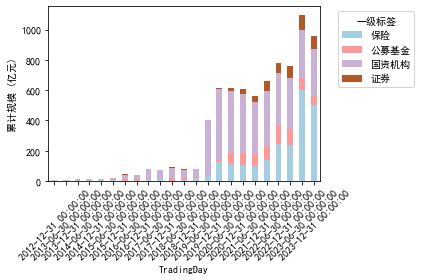

In [248]:
value_analysispivot_df = value_analysis.pivot_table(values='拥有规模存量', index='TradingDay', columns='一级标签', aggfunc='sum')
plt.figure(figsize=(12, 8))
value_analysispivot_df.plot(kind='bar', stacked=True, colormap='Paired')
plt.xlabel('TradingDay')
plt.ylabel('累计规模 (亿元)')
plt.xticks(rotation=45)
plt.legend(title='一级标签', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [249]:
fourcash=pd.concat([baoxiantotalcash,zhengquantotalcash,jijintotalcash,guoyoutotalcash],axis=1)
fourcash.columns=['保险总资金变化亿元','证券总资金变化亿元','公募基金资金变化亿元','国资机构资金变化亿元']
fourcash.index=value_analysispivot_df.index[-len(fourcash):]
fourcash.fillna(0,inplace=True)
fourcash

,保险总资金变化亿元,证券总资金变化亿元,公募基金资金变化亿元,国资机构资金变化亿元
TradingDay,,,,
2015-12-31,-1.152375,-0.875043,2.188854,23.020637
2016-06-30,-0.836521,-0.135187,0.377345,0.000000
2016-12-31,8.393497,3.267863,-2.048848,32.200986
2017-06-30,0.778176,-2.740964,-10.304546,0.110680
2017-12-31,-8.648435,0.509660,17.971076,1.795829
2018-06-30,2.490827,0.546872,-4.890657,0.213526
2018-12-31,16.594638,0.816022,-5.735296,1.281668
2019-06-30,8.103954,1.555700,-4.941646,309.158810
2019-12-31,90.324762,2.558205,10.442096,96.934942


In [250]:
value_analysispivot_df.columns=['保险规模存量','公募基金规模存量','国资机构规模存量','证券规模存量'] 
value_analysispivot_df

,保险规模存量,公募基金规模存量,国资机构规模存量,证券规模存量
TradingDay,,,,
2012-12-31,5.211313,NaN,0.299122,0.434771
2013-06-30,4.393753,0.237519,0.247466,0.420749
2013-12-31,9.675832,0.048036,1.855321,1.128992
2014-06-30,5.708707,0.042630,9.374058,0.946033
2014-12-31,5.065214,1.144402,3.948433,2.346150
2015-06-30,4.320159,10.287277,4.576612,1.933405
2015-12-31,2.706875,11.237860,27.990523,0.794487
2016-06-30,1.497077,11.312185,25.044488,0.374263
2016-12-31,9.741269,9.852441,57.923779,3.749068


In [251]:
valuecash=pd.concat([fourcash,value_analysispivot_df],axis=1,join='inner')
valuecash

,保险总资金变化亿元,证券总资金变化亿元,公募基金资金变化亿元,国资机构资金变化亿元,保险规模存量,公募基金规模存量,国资机构规模存量,证券规模存量
TradingDay,,,,,,,,
2015-12-31,-1.152375,-0.875043,2.188854,23.020637,2.706875,11.237860,27.990523,0.794487
2016-06-30,-0.836521,-0.135187,0.377345,0.000000,1.497077,11.312185,25.044488,0.374263
2016-12-31,8.393497,3.267863,-2.048848,32.200986,9.741269,9.852441,57.923779,3.749068
2017-06-30,0.778176,-2.740964,-10.304546,0.110680,10.859478,0.418572,62.233663,1.051121
2017-12-31,-8.648435,0.509660,17.971076,1.795829,2.159917,20.432254,65.189693,1.574409
2018-06-30,2.490827,0.546872,-4.890657,0.213526,4.048338,14.836114,56.402059,1.894890
2018-12-31,16.594638,0.816022,-5.735296,1.281668,18.149348,6.993829,51.444840,2.313724
2019-06-30,8.103954,1.555700,-4.941646,309.158810,31.092549,3.223545,366.598976,4.549996
2019-12-31,90.324762,2.558205,10.442096,96.934942,125.221234,14.204430,466.827668,7.510006


In [252]:
baoxianhangyecash

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,-0.021963,NaN,NaN,NaN,NaN,NaN,NaN,-0.685849,0.164897,NaN,...,NaN,NaN,NaN,NaN,-0.116198,NaN,NaN,-1.039524,NaN,0.546261
2016-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.409321,-0.036284,NaN,...,NaN,NaN,0.014334,NaN,0.000000,NaN,NaN,-0.299472,NaN,-0.105779
2017-03-31,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.081955,8.889504,0.015006,...,NaN,NaN,0.088130,NaN,0.000000,NaN,NaN,-0.076837,NaN,-0.440351
2017-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.070292,-0.530793,1.247592,...,NaN,NaN,-0.094521,NaN,0.000000,NaN,NaN,0.226191,NaN,0.000000
2018-03-31,0.000000,NaN,NaN,NaN,NaN,NaN,-0.286412,0.018351,-8.534571,-0.123442,...,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,0.261923,NaN,0.004676
2018-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,-0.016713,-0.232664,0.000000,0.469363,...,NaN,NaN,0.010647,NaN,0.000000,NaN,NaN,2.290088,NaN,-0.019831
2019-03-31,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.067124,0.000000,-0.829454,...,NaN,NaN,-0.008366,NaN,0.000000,NaN,NaN,17.365334,NaN,0.000000
2019-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-0.016469,2.274869,3.662875,...,NaN,NaN,0.747052,NaN,0.000000,NaN,NaN,1.243811,NaN,0.115725
2020-03-31,6.601314,NaN,NaN,NaN,NaN,NaN,0.000000,-0.122561,71.119780,5.925956,...,NaN,NaN,2.623699,NaN,0.000000,0.933243,2.392738,-0.284693,NaN,0.081258


In [253]:
zhengquanhangyecash

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,-0.002592,NaN,NaN,NaN,NaN,NaN,0.000069,-0.133882,-0.176899,NaN,...,NaN,NaN,0.084198,NaN,-0.002089,NaN,NaN,-0.643848,NaN,NaN
2016-08-31,-0.014403,NaN,NaN,NaN,NaN,NaN,0.000000,-0.136402,-0.028628,NaN,...,NaN,NaN,-0.068482,NaN,0.161969,NaN,NaN,-0.049240,NaN,NaN
2017-03-31,-0.000905,NaN,NaN,NaN,NaN,NaN,-0.004123,0.000000,3.201859,0.155210,...,NaN,NaN,0.029520,NaN,-0.264342,NaN,NaN,0.150644,NaN,NaN
2017-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.014151,-3.184318,0.110799,...,NaN,NaN,0.016246,NaN,0.025350,NaN,NaN,0.271003,NaN,0.005804
2018-03-31,-0.007746,NaN,NaN,NaN,NaN,NaN,0.027132,0.184369,0.019412,0.080264,...,NaN,NaN,-0.011038,NaN,-0.001194,NaN,NaN,0.201649,NaN,0.016812
2018-08-31,0.008838,NaN,NaN,NaN,NaN,NaN,-0.006245,0.430828,-0.052222,-0.079959,...,NaN,NaN,0.056269,NaN,0.028058,NaN,NaN,-0.014650,NaN,0.056504
2019-03-31,-0.001512,NaN,NaN,NaN,NaN,NaN,-0.000289,0.059453,0.000000,-0.057441,...,NaN,NaN,-0.014184,NaN,-0.025783,NaN,NaN,0.860506,NaN,0.012937
2019-08-31,0.008006,NaN,NaN,NaN,NaN,NaN,0.002759,-0.463021,0.163798,-0.105447,...,0.287981,NaN,0.078329,NaN,0.006329,NaN,NaN,1.481078,NaN,0.128963
2020-03-31,1.984070,NaN,NaN,NaN,NaN,0.205791,0.014284,0.437129,-0.011796,0.369736,...,-0.086081,NaN,0.254799,NaN,0.032725,0.184395,0.364742,-1.305759,NaN,0.064301


In [254]:
jijinhangyecash

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,游戏传媒,生物科技,电力,电子,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.076338,NaN,...,NaN,NaN,NaN,NaN,-0.104439,NaN,NaN,-8.607799,NaN,10.977431
2016-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,0.377345
2017-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002465,NaN,...,NaN,NaN,NaN,0.026354,0.000000,NaN,NaN,0.158558,NaN,-2.236225
2017-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.047802,0.194327,...,NaN,NaN,NaN,-0.024133,0.000000,NaN,NaN,0.035733,NaN,-10.558276
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,0.004520,0.033446,-0.053754,-0.004790,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,5.439740,NaN,12.551914
2018-08-31,NaN,NaN,NaN,NaN,NaN,NaN,-0.005033,-0.007263,0.000000,-0.063695,...,NaN,NaN,NaN,0.008392,0.000000,NaN,NaN,-5.392050,NaN,0.568993
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.192999,0.000000,0.099879,...,NaN,NaN,NaN,0.001538,0.000000,NaN,NaN,6.731251,NaN,-12.760962
2019-08-31,0.018213,NaN,NaN,NaN,NaN,NaN,0.000000,1.469422,0.000000,0.059468,...,0.034184,NaN,NaN,0.222301,0.000000,NaN,NaN,-6.842444,NaN,0.088255
2020-03-31,-0.020628,NaN,NaN,NaN,NaN,NaN,0.000000,-1.486138,0.000000,9.597788,...,0.065074,NaN,NaN,0.310415,0.000000,NaN,0.682357,0.965542,NaN,0.195870


In [255]:
guoyouhangyecash

四级分类,TMT,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,基建,基础化工,...,汽车,游戏传媒,电力,电子,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.020637,NaN,NaN
2017-03-31,NaN,NaN,NaN,NaN,NaN,NaN,32.200986,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
2017-08-31,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.029163,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.081517,NaN,NaN
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,1.828517,0.057046,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.089735,NaN,NaN
2018-08-31,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-0.074842,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.288367,NaN,NaN
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,1.516081,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.234414,NaN,NaN
2019-08-31,NaN,NaN,NaN,NaN,NaN,NaN,309.158810,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
2020-03-31,NaN,NaN,NaN,NaN,NaN,0.052736,80.476018,16.287663,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.118526
2020-08-31,0.454506,NaN,NaN,NaN,0.314977,3.199241,-44.909658,0.620045,NaN,NaN,...,NaN,NaN,NaN,0.631251,2.884133,NaN,0.436882,3.907080,NaN,5.123551


保险细分（看中国平安，中国人寿）

In [256]:
baoxian=jigouholder[jigouholder['一级标签']=='保险']
baoxian[baoxian['HolderName'].str.contains('中国平安')]

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType,二级标签,一级标签
22,159512.OF,2023-12-31,中游制造,0.719246,2024-03-29,5090,5452200.0,中国平安财产保险股份有限公司-传统-普通保险产品,0.078700,4110,0.056605,机构holder,保险公司,保险
29,159516.OF,2023-12-31,科技,8.685837,2024-03-29,5091,16443100.0,中国平安人寿保险股份有限公司－分红－个险分红,0.017200,4110,0.149396,机构holder,保险公司,保险
30,159516.OF,2023-12-31,科技,8.685837,2024-03-29,5091,12080400.0,中国平安人寿保险股份有限公司－自有资金,0.012600,4110,0.109442,机构holder,保险公司,保险
116,159611.OF,2022-12-31,周期,15.699682,2023-03-30,5091,57012500.0,中国平安人寿保险股份有限公司-万能-聚财宝万能,0.031423,4110,0.493331,机构holder,保险公司,保险
120,159611.OF,2023-06-30,周期,36.518564,2023-08-30,5091,172832200.0,中国平安人寿保险股份有限公司-分红-个险分红,0.044400,4110,1.621424,机构holder,保险公司,保险
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13058,588260.OF,2023-06-30,科技,3.017989,2023-08-30,5091,37523600.0,中国平安人寿保险股份有限公司－分红－个险分红,0.144500,4110,0.436099,机构holder,保险公司,保险
13059,588260.OF,2023-06-30,科技,3.017989,2023-08-30,5091,29741000.0,中国平安人寿保险股份有限公司－自有资金,0.114500,4110,0.345560,机构holder,保险公司,保险
13068,588260.OF,2023-12-31,科技,1.568041,2024-03-27,5090,9982600.0,中国平安财产保险股份有限公司－传统－普通保险产品,0.064500,4110,0.101139,机构holder,保险公司,保险
13081,588290.OF,2023-06-30,科技,11.705970,2023-08-30,5091,18205300.0,中国平安人寿保险股份有限公司－自有资金,0.018900,4110,0.221243,机构holder,保险公司,保险


In [257]:
pingantotalcash,pinganhangyecash=cashflowoutfunc(baoxian[baoxian['HolderName'].str.contains('中国平安')],hangye,price)
pingantotalcash

2017-03-31      4.303002
2017-08-31     -1.373520
2018-08-31     -1.410386
2019-03-31     15.357325
2019-08-31     -2.822100
2020-03-31     -0.609462
2020-08-31     -9.125163
2021-03-31      1.397136
2021-08-31     33.153619
2022-03-31    -11.721327
2022-08-31      4.725927
2023-03-31     30.196848
2023-08-31    258.852335
2024-03-31    -71.305128
dtype: float64

In [258]:
pinganhangyecash=fill_nan_after_first_non_na(pinganhangyecash)
pinganhangyecash

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,游戏传媒,生物科技,电力,电子,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2017-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.529481,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.226479,NaN,NaN
2017-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.373520,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
2018-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.048931,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.638545,NaN,NaN
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.357325,NaN,NaN
2019-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.561973,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.384074,NaN,NaN
2020-03-31,2.260650,NaN,NaN,NaN,NaN,NaN,NaN,0.247854,0.000000,1.287942,...,NaN,NaN,NaN,0.171744,NaN,NaN,NaN,-4.796246,NaN,0.218594
2020-08-31,0.902864,NaN,NaN,NaN,NaN,NaN,NaN,-0.287001,0.000000,-2.637751,...,NaN,NaN,NaN,-0.068033,NaN,NaN,0.238971,-8.767084,NaN,-0.022561
2021-03-31,-1.658275,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,-0.569614,...,0.133898,0.256409,NaN,0.500202,NaN,NaN,0.343362,2.791051,0.041637,0.368011
2021-08-31,0.000000,NaN,NaN,5.968975,NaN,NaN,NaN,0.000000,0.000000,0.000000,...,-0.116040,-0.245250,NaN,5.951889,NaN,NaN,2.666932,13.353996,0.031874,-0.738025


In [259]:
zgrenshoutotalcash,zgrenshouhangyecash=cashflowoutfunc(baoxian[baoxian['HolderName'].str.contains('中国人寿')],hangye,price)
zgrenshoutotalcash

2016-03-31    -0.586657
2016-08-31    -0.136540
2017-03-31     4.329910
2017-08-31     1.972708
2018-03-31    -5.524917
2018-08-31     0.627359
2019-08-31     7.227945
2020-03-31    35.002373
2020-08-31    -4.806844
2021-03-31    -5.102231
2021-08-31   -28.819039
2022-03-31    23.795922
2022-08-31    67.984167
2023-03-31    12.738159
2023-08-31     9.012104
2024-03-31    36.495214
dtype: float64

In [260]:
zgrenshouhangyecash=fill_nan_after_first_non_na(zgrenshouhangyecash)
zgrenshouhangyecash

四级分类,TMT,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,基建,...,游戏传媒,生物科技,电力,电子,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,NaN,NaN,NaN,NaN,NaN,-0.586657,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-08-31,NaN,NaN,NaN,NaN,NaN,NaN,-0.136540,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-31,NaN,NaN,NaN,NaN,NaN,NaN,-0.112986,4.442896,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-31,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.842727,1.079154,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.050826,NaN,NaN
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-5.348805,-0.123442,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.052670,NaN,NaN
2018-08-31,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.036469,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.590889,NaN,NaN
2019-08-31,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.578214,NaN,...,NaN,NaN,NaN,0.656912,NaN,NaN,NaN,5.871530,NaN,0.045461
2020-03-31,3.539674,NaN,NaN,NaN,NaN,NaN,0.000000,17.610773,5.801053,NaN,...,1.052261,NaN,NaN,1.934879,NaN,0.933243,1.866342,2.314198,NaN,-0.051817
2020-08-31,-4.302989,NaN,NaN,NaN,NaN,NaN,0.000000,-1.200693,-2.919688,NaN,...,0.627225,0.624691,NaN,0.140832,2.903863,-0.690137,-1.963865,-2.989141,NaN,0.528654


证券细分（中信证券、招商证券）

In [261]:
zhengquan=jigouholder[jigouholder['一级标签']=='证券']

In [262]:
zhongxintotalcash,zhongxinhangyecash=cashflowoutfunc(zhengquan[zhengquan['HolderName'].str.contains('中信证券')],hangye,price)
zhongxintotalcash

2016-03-31   -0.211169
2016-08-31   -0.346376
2017-03-31    0.100083
2017-08-31   -0.057083
2018-03-31    0.340319
2018-08-31   -0.308402
2019-03-31   -0.045981
2019-08-31    1.161626
2020-03-31   -0.656881
2020-08-31    0.621552
2021-03-31    3.919558
2021-08-31   -3.106516
2022-03-31    0.828231
2022-08-31    1.244284
2023-03-31    6.152542
2023-08-31   -1.891579
2024-03-31   -0.716751
dtype: float64

In [263]:
zhongxinhangyecash=fill_nan_after_first_non_na(zhongxinhangyecash)
zhongxinhangyecash

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,-0.002592,NaN,NaN,NaN,NaN,NaN,NaN,-0.103334,-0.001323,NaN,...,NaN,NaN,NaN,NaN,-0.017783,NaN,NaN,-0.086138,NaN,NaN
2016-08-31,-0.014403,NaN,NaN,NaN,NaN,NaN,NaN,-0.136402,-0.048228,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,-0.147343,NaN,NaN
2017-03-31,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.040650,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.059433,NaN,NaN
2017-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.001633,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,-0.058717,NaN,NaN
2018-03-31,-0.005890,NaN,NaN,NaN,NaN,NaN,0.012376,0.106540,0.000000,0.063303,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.139843,NaN,0.024146
2018-08-31,-0.000005,NaN,NaN,NaN,NaN,NaN,-0.013782,-0.114690,0.000000,-0.090404,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,-0.089521,NaN,0.000000
2019-03-31,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,-0.022364,NaN,-0.023617
2019-08-31,-0.001417,NaN,NaN,NaN,NaN,NaN,0.000000,0.075694,0.000000,0.000000,...,0.088457,NaN,0.085181,NaN,0.000000,NaN,NaN,0.913710,NaN,0.000000
2020-03-31,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-0.000082,0.025842,0.036075,...,-0.033069,NaN,-0.031103,NaN,0.000000,0.064472,0.071184,-0.790200,NaN,0.000000


In [264]:
zhaoshangtotalcash,zhaoshanghangyecash=cashflowoutfunc(zhengquan[zhengquan['HolderName'].str.contains('招商')],hangye,price)
zhaoshangtotalcash

2016-03-31    0.025723
2016-08-31    0.018339
2017-03-31    0.009507
2017-08-31    0.011764
2018-03-31   -0.052914
2018-08-31    0.162668
2019-03-31    0.071181
2019-08-31   -0.216648
2020-03-31    0.301046
2020-08-31    1.289065
2021-03-31    2.530366
2021-08-31    0.876119
2022-03-31    0.482869
2022-08-31    2.246214
2023-03-31    2.873518
2023-08-31    0.185356
2024-03-31    1.312547
dtype: float64

In [265]:
zhaoshanghangyecash=fill_nan_after_first_non_na(zhaoshanghangyecash)
zhaoshanghangyecash

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000612,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.026335,NaN,NaN
2016-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000129,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018468,NaN,NaN
2017-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.036783,0.028599,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017691,NaN,NaN
2017-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.007129,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004635,NaN,NaN
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-0.032051,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.020863,NaN,NaN
2018-08-31,0.008843,NaN,NaN,NaN,NaN,NaN,0.009122,NaN,0.000000,0.009835,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.127069,NaN,NaN
2019-03-31,-0.001512,NaN,NaN,NaN,NaN,NaN,-0.001788,0.056389,0.000000,-0.008266,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.032373,NaN,NaN
2019-08-31,0.009423,NaN,NaN,NaN,NaN,NaN,0.004667,-0.053301,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.198751,NaN,0.021314
2020-03-31,0.040890,NaN,NaN,NaN,NaN,0.051391,0.012018,0.000000,0.000000,0.024394,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.144730,NaN,-0.000002


基金细分（华夏、博时)

In [266]:
huaxiatotalcash,huaxiahangyecash=cashflowoutfunc(jijin[jijin['HolderName'].str.contains('华夏基金')],hangye,price)
huaxiatotalcash

2018-03-31     0.008845
2020-03-31     1.941019
2020-08-31     0.760838
2021-03-31    25.875886
2021-08-31     4.055603
2022-03-31    18.477216
2022-08-31    -2.315022
2023-03-31     2.434302
2023-08-31    -9.444403
2024-03-31     6.688214
dtype: float64

In [267]:
huaxiahangyecash=fill_nan_after_first_non_na(huaxiahangyecash)
huaxiahangyecash

四级分类,TMT,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,基建,基础化工,...,有色,机械设备,汽车,游戏传媒,电子,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008845,NaN,NaN
2020-03-31,NaN,NaN,NaN,NaN,NaN,0.187145,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.331593,NaN,0.580877,0.841404,NaN,NaN
2020-08-31,NaN,NaN,NaN,NaN,NaN,-0.227533,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.688139,NaN,-0.642144,-0.908835,NaN,1.851210
2021-03-31,0.295002,NaN,NaN,NaN,2.433977,1.668529,NaN,3.300465,NaN,NaN,...,2.157754,NaN,NaN,NaN,-1.043882,NaN,0.000000,9.907019,NaN,2.550657
2021-08-31,-0.301094,NaN,NaN,NaN,-1.119034,-1.806662,NaN,-2.801162,NaN,NaN,...,1.361464,NaN,NaN,NaN,1.024593,NaN,0.000000,-2.159829,NaN,6.674844
2022-03-31,0.000000,7.144786,NaN,2.615062,-1.363986,0.000000,NaN,6.182435,NaN,NaN,...,-4.292865,NaN,NaN,NaN,-0.325646,NaN,1.937495,-4.990624,NaN,3.976206
2022-08-31,0.000000,-0.013353,0.464263,1.649690,0.000000,0.000000,NaN,-0.058831,NaN,NaN,...,-0.871467,NaN,NaN,NaN,-1.031542,NaN,-1.605696,0.781940,NaN,-0.809799
2023-03-31,0.000000,-0.454400,0.000000,4.892671,0.076628,0.000000,NaN,-3.331149,NaN,NaN,...,0.000000,NaN,NaN,0.018722,2.639486,0.073287,0.085506,1.017480,NaN,4.744142
2023-08-31,0.000000,-5.272207,0.650669,-4.181506,-0.075582,2.308737,NaN,-0.325915,NaN,1.552823,...,1.574370,0.433499,0.634712,-0.024535,1.587796,0.891001,0.336267,-2.516111,0.615496,-5.679054


In [268]:
boshitotalcash,boshihangyecash=cashflowoutfunc(jijin[jijin['HolderName'].str.contains('博时')],hangye,price)
boshitotalcash

2021-03-31    0.260132
2021-08-31   -0.117122
2022-03-31    3.610846
2022-08-31   -1.977317
2023-03-31    4.045777
2023-08-31   -0.748595
2024-03-31    1.954672
dtype: float64

In [269]:
boshihangyecash=fill_nan_after_first_non_na(boshihangyecash)
boshihangyecash

四级分类,中药,光伏,农业,医药医疗,国央企,基建,基础化工,家用电器,房地产,新能源汽车,...,机械设备,汽车,游戏传媒,电力,电子,绿色/ESG,计算机,通信,金融,钢铁煤炭
TradingDay,,,,,,,,,,,,,,,,,,,,,
2021-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.260132,NaN
2021-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.117122,NaN
2022-03-31,NaN,NaN,NaN,NaN,3.640037,NaN,NaN,NaN,NaN,0.060093,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.089284,NaN
2022-08-31,NaN,NaN,NaN,0.038742,-3.519697,1.435673,NaN,NaN,NaN,-0.049643,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.117609,NaN
2023-03-31,NaN,NaN,0.704366,-0.036087,0.000000,-0.773780,0.358656,0.014788,NaN,0.000000,...,0.079429,0.404252,0.687547,NaN,0.198112,NaN,0.175252,0.713220,0.177411,NaN
2023-08-31,NaN,NaN,-0.635241,0.054951,0.000000,-0.612542,0.086557,0.315139,0.712762,0.000000,...,-0.080110,-0.008809,-1.062937,0.431184,-0.152238,0.030087,0.194885,-0.647902,-0.425099,1.443491
2024-03-31,0.430194,0.988975,0.000000,-0.049168,0.000000,1.027784,-0.353181,0.065182,-0.189118,0.000000,...,0.000000,0.115660,0.315421,0.580895,0.000000,-0.024197,-0.015463,0.637408,-0.002980,-0.844094


国资细分 中石油 中央汇金

In [270]:
shiyoutotalcash,shiyouhangyecash=cashflowoutfunc(guoyou[guoyou['HolderName'].str.contains('中国石油')],hangye,price)
shiyoutotalcash

2018-03-31     -0.027428
2018-08-31      0.213526
2019-08-31    139.979897
2020-03-31      5.995859
2020-08-31      6.635826
2021-03-31    -41.912066
2021-08-31    -20.170015
2022-03-31     -2.933618
2022-08-31      0.940439
2023-03-31     -0.256684
2023-08-31     -0.151549
dtype: float64

In [271]:
shiyouhangyecash

四级分类,TMT,医疗,国央企,国防军工,房地产,新能源汽车,电子,绿色/ESG,通信,金融
TradingDay,,,,,,,,,,
2018-08-31,NaN,NaN,NaN,0.057046,NaN,NaN,NaN,NaN,NaN,-0.084474
2019-08-31,NaN,NaN,NaN,-0.074842,NaN,NaN,NaN,NaN,NaN,0.288367
2020-03-31,NaN,NaN,140.247074,NaN,NaN,NaN,NaN,NaN,NaN,-0.267178
2020-08-31,NaN,NaN,5.995859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-31,0.454506,NaN,2.925027,NaN,NaN,0.535388,0.432044,NaN,0.436882,1.851979
2021-08-31,NaN,NaN,-42.374442,NaN,NaN,NaN,0.462376,NaN,NaN,NaN
2022-03-31,-0.565495,NaN,-18.187676,NaN,NaN,-1.088186,-0.328659,NaN,NaN,NaN
2022-08-31,NaN,NaN,NaN,NaN,NaN,NaN,-0.494923,0.118327,-0.400414,-2.156609
2023-03-31,NaN,NaN,0.024073,0.916366,NaN,NaN,NaN,NaN,NaN,NaN


In [272]:
shiyouhangyecash=fill_nan_after_first_non_na(shiyouhangyecash)
shiyouhangyecash

四级分类,TMT,医疗,国央企,国防军工,房地产,新能源汽车,电子,绿色/ESG,通信,金融
TradingDay,,,,,,,,,,
2018-08-31,NaN,NaN,NaN,0.057046,NaN,NaN,NaN,NaN,NaN,-0.084474
2019-08-31,NaN,NaN,NaN,-0.074842,NaN,NaN,NaN,NaN,NaN,0.288367
2020-03-31,NaN,NaN,140.247074,0.000000,NaN,NaN,NaN,NaN,NaN,-0.267178
2020-08-31,NaN,NaN,5.995859,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
2021-03-31,0.454506,NaN,2.925027,0.000000,NaN,0.535388,0.432044,NaN,0.436882,1.851979
2021-08-31,0.000000,NaN,-42.374442,0.000000,NaN,0.000000,0.462376,NaN,0.000000,0.000000
2022-03-31,-0.565495,NaN,-18.187676,0.000000,NaN,-1.088186,-0.328659,NaN,0.000000,0.000000
2022-08-31,0.000000,NaN,0.000000,0.000000,NaN,0.000000,-0.494923,0.118327,-0.400414,-2.156609
2023-03-31,0.000000,NaN,0.024073,0.916366,NaN,0.000000,0.000000,0.000000,0.000000,0.000000


In [273]:
huijintotalcash,huijinhangyecash=cashflowoutfunc(guoyou[guoyou['HolderName'].str.contains('中央汇金')],hangye,price)
huijintotalcash

2016-03-31    23.016259
2020-03-31     0.666804
2020-08-31    10.233744
2021-03-31    69.634326
2021-08-31    29.168597
2022-03-31    17.953988
2022-08-31    -1.052955
2023-03-31     0.241396
2023-08-31   -11.847332
2024-03-31     6.688214
dtype: float64

In [274]:
huijinhangyecash=fill_nan_after_first_non_na(huijinhangyecash)
huijinhangyecash

四级分类,TMT,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,基建,基础化工,...,旅游,有色,机械设备,汽车,电子,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2019-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.016259,NaN,NaN
2020-03-31,NaN,NaN,NaN,NaN,NaN,0.052736,NaN,0.495542,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.118526
2020-08-31,NaN,NaN,NaN,NaN,NaN,3.199241,NaN,1.499012,NaN,NaN,...,NaN,NaN,NaN,NaN,0.199207,NaN,NaN,0.212732,NaN,5.123551
2021-03-31,1.396458,NaN,NaN,NaN,2.433977,-0.772479,NaN,3.813486,NaN,NaN,...,NaN,2.157754,NaN,NaN,-0.234459,NaN,NaN,49.677302,NaN,6.555923
2021-08-31,-1.425295,NaN,NaN,NaN,-1.119034,-3.911496,NaN,-5.457827,NaN,NaN,...,NaN,1.361464,NaN,NaN,1.256024,NaN,NaN,3.256083,NaN,32.026196
2022-03-31,0.000000,7.129512,NaN,2.615062,-1.363986,0.000000,NaN,5.372010,NaN,NaN,...,NaN,-4.292865,NaN,NaN,-0.325646,NaN,1.937495,-3.942211,NaN,3.230264
2022-08-31,0.000000,0.000000,NaN,1.649690,0.000000,0.000000,NaN,-0.058831,NaN,NaN,...,NaN,0.871467,NaN,NaN,-1.031542,NaN,-1.605696,0.781940,NaN,-3.815663
2023-03-31,0.000000,-0.454400,NaN,4.892671,0.076628,0.000000,NaN,-0.775762,NaN,NaN,...,NaN,-1.655232,NaN,NaN,2.639486,0.073287,0.085506,1.017480,NaN,4.597206
2023-08-31,0.000000,-5.272207,0.650669,-4.181506,-0.075582,2.308737,NaN,-2.753378,NaN,1.552823,...,0.432849,1.574370,0.433499,0.634712,1.587796,0.891001,0.336267,-2.516111,0.615496,-5.679054


2023年末截面情况

In [275]:
end2022=futureprocess[futureprocess['TradingDay']=='2022-12-31']
end2022

,证券代码,TradingDay,四级分类,市值亿元,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,HolderType,简称,标签
3,159608.OF,2022-12-31,周期,1.591352,3268315.0,中信建投证券股份有限公司,0.015243,0.024257,机构holder,中信建投证券有限公司,证券
6,159613.OF,2022-12-31,科技,1.416043,3207353.0,中信建投证券股份有限公司,0.016741,0.023706,机构holder,中信建投证券有限公司,证券
9,159619.OF,2022-12-31,周期,3.155143,6662381.0,中信建投证券股份有限公司,0.017911,0.056512,机构holder,中信建投证券有限公司,证券
12,159621.OF,2022-12-31,绿色/ESG,1.408409,6384402.0,中信建投证券股份有限公司,0.043599,0.061405,机构holder,中信建投证券有限公司,证券
15,159625.OF,2022-12-31,周期,3.667798,8911806.0,中信建投证券股份有限公司,0.025483,0.093466,机构holder,中信建投证券有限公司,证券
...,...,...,...,...,...,...,...,...,...,...,...
7011,562990.OF,2022-12-31,绿色/ESG,23.047778,12000000.0,罗定市顺成房地产开发有限公司,0.004217,0.097192,机构holder,罗定市顺成房地产开发有限公司,财务公司
7012,562990.OF,2022-12-31,绿色/ESG,23.047778,10500000.0,海南启合投资有限公司,0.003690,0.085046,机构holder,海南启合投资有限公司,财务公司
7015,562990.OF,2022-12-31,绿色/ESG,23.047778,10000000.0,都邦财产保险股份有限公司－传统保险产品,0.003514,0.080990,机构holder,都邦财产保险有限公司,保险
7023,588200.OF,2022-12-31,科技,2.440325,3818000.0,上海睿桓投资有限公司,0.016049,0.039165,机构holder,上海睿桓投资有限公司,私募基金


In [276]:
gejigou2022=end2022.groupby('标签').sum(numeric_only=True)['购买市值亿元'].sort_values(ascending=False)
gejigou2022

标签
国资机构    292.134102
保险      209.876305
公募基金    108.346277
证券      105.097880
财务公司     59.399230
银行       50.838229
信托       10.204275
私募基金      6.204166
外资机构      4.141992
期货        2.816880
Name: 购买市值亿元, dtype: float64

In [277]:
end2023=futureprocess[futureprocess['TradingDay']=='2023-12-31']
end2023

,证券代码,TradingDay,四级分类,市值亿元,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,HolderType,简称,标签
0,159503.OF,2023-12-31,金融地产,0.353301,8026791.0,中信建投证券股份有限公司,0.2244,0.079281,机构holder,中信建投证券有限公司,证券
1,159516.OF,2023-12-31,科技,8.685837,8242128.0,中信建投证券股份有限公司,0.0086,0.074698,机构holder,中信建投证券有限公司,证券
2,159537.OF,2023-12-31,科技,0.349286,6191193.0,中信建投证券股份有限公司,0.1645,0.057457,机构holder,中信建投证券有限公司,证券
5,159608.OF,2023-12-31,周期,2.601526,5843342.0,中信建投证券股份有限公司,0.0128,0.033300,机构holder,中信建投证券有限公司,证券
8,159613.OF,2023-12-31,科技,0.828144,2224775.0,中信建投证券股份有限公司,0.0211,0.017474,机构holder,中信建投证券有限公司,证券
...,...,...,...,...,...,...,...,...,...,...,...
7019,563050.OF,2023-12-31,国央企,4.250470,3000000.0,珠海阿巴马资产管理有限公司－阿巴马元享127号私募证券投资基金,0.0061,0.025928,机构holder,珠海阿巴马资产有限公司,私募基金
7021,588100.OF,2023-12-31,科技,6.363485,25934100.0,中国中信集团公司企业年金计划－中信银行股份有限公司,0.0416,0.264721,机构holder,中信银行有限公司,银行
7022,588100.OF,2023-12-31,科技,6.363485,8335100.0,招银理财有限责任公司－招银理财招睿智远(她享心意)两年封闭2号增强型固收类理,0.0134,0.085271,机构holder,招银理财有限公司,银行
7026,588200.OF,2023-12-31,科技,68.697629,103168400.0,和谐健康保险股份有限公司－万能,0.0165,1.133511,机构holder,和谐健康保险有限公司,保险


In [278]:
gejigou2023=end2023.groupby('标签').sum(numeric_only=True)['购买市值亿元'].sort_values(ascending=False)
gejigou2023

标签
保险      517.133668
国资机构    273.587301
证券       93.215794
公募基金     63.687703
财务公司     58.248661
私募基金     23.305514
信托       13.476570
外资机构      8.714143
银行        3.432083
期货        1.748777
Name: 购买市值亿元, dtype: float64

In [279]:
gejigou2023s=pd.concat([gejigou2022,gejigou2023],axis=1)
gejigou2023s.columns=['2022年末拥有规模','2023年末拥有规模']
gejigou2023s=gejigou2023s[0:4]
gejigou2023s

,2022年末拥有规模,2023年末拥有规模
标签,,
国资机构,292.134102,273.587301
保险,209.876305,517.133668
公募基金,108.346277,63.687703
证券,105.097880,93.215794


In [280]:
jingque=end2023.groupby(['标签','简称','TradingDay']).sum(numeric_only=True)['购买市值亿元'].reset_index()
jingque

,标签,简称,TradingDay,购买市值亿元
0,保险,三峡人寿保险有限公司,2023-12-31,0.058338
1,保险,东吴人寿保险有限公司,2023-12-31,2.365665
2,保险,中信保诚人寿保险有限公司,2023-12-31,8.604470
3,保险,中再资管有限公司,2023-12-31,1.048439
4,保险,中原农业保险有限公司,2023-12-31,0.069936
...,...,...,...,...
342,银行,兴银理财有限公司,2023-12-31,0.140596
343,银行,吉林银行有限公司,2023-12-31,0.442839
344,银行,招商财富资管有限公司,2023-12-31,0.021846
345,银行,招银理财有限公司,2023-12-31,0.715763


In [281]:
eachtop5=jingque.groupby('标签', group_keys=False).apply(lambda x: x.sort_values('购买市值亿元', ascending=False).head(5))#每一个列表最多的5个
eachtop5

,标签,简称,TradingDay,购买市值亿元
11,保险,中国平安人寿保险有限公司,2023-12-31,211.463438
6,保险,中国人寿保险有限公司,2023-12-31,124.264273
38,保险,天安人寿保险有限公司,2023-12-31,29.885043
24,保险,华夏人寿保险有限公司,2023-12-31,28.158732
29,保险,友邦人寿保险有限公司,2023-12-31,21.661261
70,信托,华润深国投信托有限公司,2023-12-31,9.698476
71,信托,平安信托有限公司,2023-12-31,2.323630
66,信托,上海国际信托有限公司,2023-12-31,0.401879
74,信托,陆家嘴国际信托有限公司,2023-12-31,0.305774
67,信托,东莞信托有限公司,2023-12-31,0.271736


In [282]:
buy=pd.merge(end2023.groupby(['标签','简称','证券代码']).sum(numeric_only=True)[['购买市值亿元']].reset_index(),end2023[['证券代码','市值亿元']].drop_duplicates(),on='证券代码')
buy['购买比例']=buy['购买市值亿元']/buy['市值亿元']
buyinfo=buy.groupby(['标签','简称','证券代码']).sum(numeric_only=True)[['购买市值亿元','购买比例']].reset_index()
buyinfo

,标签,简称,证券代码,购买市值亿元,购买比例
0,保险,三峡人寿保险有限公司,560800.OF,0.058338,0.0044
1,保险,东吴人寿保险有限公司,159929.OF,0.456057,0.0234
2,保险,东吴人寿保险有限公司,159998.OF,0.118583,0.0056
3,保险,东吴人寿保险有限公司,512200.OF,0.360238,0.0088
4,保险,东吴人寿保险有限公司,515120.OF,0.381980,0.0093
...,...,...,...,...,...
2202,银行,招银理财有限公司,159839.OF,0.089022,0.0164
2203,银行,招银理财有限公司,517090.OF,0.145676,0.0332
2204,银行,招银理财有限公司,517180.OF,0.146202,0.0300
2205,银行,招银理财有限公司,588100.OF,0.085271,0.0134


In [283]:
buyinfos=pd.merge(buyinfo,buyinfo.groupby(['标签','简称']).sum(numeric_only=True)['购买市值亿元'].reset_index(),on=['标签','简称'])
buyinfos.rename(columns={'购买市值亿元_x':'买了该基金市值亿元','购买市值亿元_y':'该机构买的所有基金总市值亿元和'},inplace=True)
buyinfos['买的该基金占你总基金中的持仓比例']=buyinfos['买了该基金市值亿元']/buyinfos['该机构买的所有基金总市值亿元和']
buyinfos['购买比例*持仓比例']=buyinfos['购买比例']*buyinfos['买的该基金占你总基金中的持仓比例']
buyinfos=pd.merge(buyinfos,end2023[['证券代码','市值亿元']].drop_duplicates(),on='证券代码')
buyinfos
# buyinfos.groupby('标签', group_keys=False).apply(lambda x: x.sort_values('该机构买的所有基金总市值亿元和', ascending=False).head(100))

,标签,简称,证券代码,买了该基金市值亿元,购买比例,该机构买的所有基金总市值亿元和,买的该基金占你总基金中的持仓比例,购买比例*持仓比例,市值亿元
0,保险,三峡人寿保险有限公司,560800.OF,0.058338,0.0044,0.058338,1.000000,0.004400,13.258528
1,保险,中国平安人寿保险有限公司,560800.OF,1.292707,0.0975,211.463438,0.006113,0.000596,13.258528
2,保险,众诚汽车保险有限公司,560800.OF,0.091484,0.0069,1.327828,0.068897,0.000475,13.258528
3,保险,财信吉祥人寿保险有限公司,560800.OF,0.128608,0.0097,0.128608,1.000000,0.009700,13.258528
4,证券,中国银河证券有限公司,560800.OF,0.112697,0.0085,3.938338,0.028615,0.000243,13.258528
...,...,...,...,...,...,...,...,...,...
2202,证券,方正证券有限公司,516980.OF,0.043585,0.1553,9.112272,0.004783,0.000743,0.280650
2203,证券,方正证券有限公司,561800.OF,0.038459,0.0391,9.112272,0.004221,0.000165,0.983600
2204,财务公司,北京华彬庄园绿色休闲健身俱乐部有限公司,159847.OF,0.045407,0.0071,0.129804,0.349816,0.002484,6.395422
2205,财务公司,杭州瑞峰投资有限公司,159847.OF,0.030058,0.0047,0.198147,0.151698,0.000713,6.395422


In [284]:
totalnumber=end2023.groupby(['标签','简称']).count()['证券代码'].reset_index()
totalnumber.rename(columns={'证券代码':'总购买基金个数'},inplace=True)
totalnumber

,标签,简称,总购买基金个数
0,保险,三峡人寿保险有限公司,1
1,保险,东吴人寿保险有限公司,8
2,保险,中信保诚人寿保险有限公司,7
3,保险,中再资管有限公司,2
4,保险,中原农业保险有限公司,2
...,...,...,...
342,银行,兴银理财有限公司,4
343,银行,吉林银行有限公司,3
344,银行,招商财富资管有限公司,1
345,银行,招银理财有限公司,9


In [285]:
eachnumber=end2023.groupby(['标签','简称','四级分类']).count()['证券代码'].reset_index()
eachnumber.rename(columns={'证券代码':'该行业购买个数'},inplace=True)
eachnumber

,标签,简称,四级分类,该行业购买个数
0,保险,三峡人寿保险有限公司,科技,1
1,保险,东吴人寿保险有限公司,农业,1
2,保险,东吴人寿保险有限公司,医药医疗,3
3,保险,东吴人寿保险有限公司,科技,3
4,保险,东吴人寿保险有限公司,金融地产,1
...,...,...,...,...
745,银行,招商财富资管有限公司,国央企,1
746,银行,招银理财有限公司,医药医疗,1
747,银行,招银理财有限公司,国央企,4
748,银行,招银理财有限公司,科技,4


In [286]:
numbers=pd.merge(eachnumber,totalnumber,on=['标签','简称'])
numbers

,标签,简称,四级分类,该行业购买个数,总购买基金个数
0,保险,三峡人寿保险有限公司,科技,1,1
1,保险,东吴人寿保险有限公司,农业,1,8
2,保险,东吴人寿保险有限公司,医药医疗,3,8
3,保险,东吴人寿保险有限公司,科技,3,8
4,保险,东吴人寿保险有限公司,金融地产,1,8
...,...,...,...,...,...
745,银行,招商财富资管有限公司,国央企,1,1
746,银行,招银理财有限公司,医药医疗,1,9
747,银行,招银理财有限公司,国央企,4,9
748,银行,招银理财有限公司,科技,4,9


In [287]:
numbertop=numbers.groupby('标签', group_keys=False).apply(lambda x: x.sort_values('总购买基金个数', ascending=False))
numbertop

,标签,简称,四级分类,该行业购买个数,总购买基金个数
41,保险,中国平安人寿保险有限公司,国央企,15,271
43,保险,中国平安人寿保险有限公司,新能源,38,271
42,保险,中国平安人寿保险有限公司,国防军工,9,271
47,保险,中国平安人寿保险有限公司,金融地产,36,271
45,保险,中国平安人寿保险有限公司,科技,63,271
...,...,...,...,...,...
737,银行,中邮理财有限公司,新能源,1,2
724,银行,中信银行有限公司,科技,1,1
745,银行,招商财富资管有限公司,国央企,1,1
725,银行,中国交通银行有限公司,科技,1,1


In [288]:
excel_writer=pd.ExcelWriter(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\底稿.xlsx', engine='openpyxl', mode='a')
sigejigou.to_excel(excel_writer,sheet_name='行业主题四大机构时序总表',index=False)
valuecash.to_excel(excel_writer,sheet_name='行业主题四大机构时序资金已经规模变化数据')
baoxianhangyecash.to_excel(excel_writer,sheet_name='保险细分行业资金')
pinganhangyecash.to_excel(excel_writer,sheet_name='中国平安细分行业资金')
zgrenshouhangyecash.to_excel(excel_writer,sheet_name='中国人寿细分行业资金')
zhengquanhangyecash.to_excel(excel_writer,sheet_name='证券细分行业资金')
zhongxinhangyecash.to_excel(excel_writer,sheet_name='中信证券细分行业资金')
zhaoshanghangyecash.to_excel(excel_writer,sheet_name='招商证券细分行业资金')
jijinhangyecash.to_excel(excel_writer,sheet_name='基金细分行业资金')
huaxiahangyecash.to_excel(excel_writer,sheet_name='华夏基金细分行业资金')
boshihangyecash.to_excel(excel_writer,sheet_name='博时基金细分行业资金')
guoyouhangyecash.to_excel(excel_writer,sheet_name='国资细分行业资金')
shiyouhangyecash.to_excel(excel_writer,sheet_name='中国石油细分行业资金')
huijinhangyecash.to_excel(excel_writer,sheet_name='中央汇金细分行业资金')
end2023.to_excel(excel_writer,sheet_name='行业2023年底截面所有机构总表',index=False)
gejigou2023.to_excel(excel_writer,sheet_name='行业2023末规模总览')
gejigou2023s.to_excel(excel_writer,sheet_name='行业四大机构年初末对比')
# jingque.to_excel(excel_writer,sheet_name='行业2023末所有机构购买市值总表',index=False)
eachtop5.to_excel(excel_writer,sheet_name='行业2023末所有机构中各自买的规模最多的top5',index=False)
buyinfos.to_excel(excel_writer,sheet_name='行业各基金规模比例总览表',index=False)
numbers.to_excel(excel_writer,sheet_name='行业2023末所有机构中买的基金个数总表',index=False)
# numbertop.to_excel(excel_writer,sheet_name='行业2023末所有机构中依照分类对每一类降序排序',index=False)

In [289]:
excel_writer.save()
excel_writer.close()

# 按时间拆分

## 尝试12周且对数据进行处理

In [290]:
initial=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\初始资金.csv',index_col=0)
initial.rename(columns={'SecuCode':'证券代码'},inplace=True)
initial['初始资金亿元']=initial['ParValue']*initial['ShareIssued']/100000000
initial

,证券代码,ParValue,ShareIssued,初始资金亿元
0,000001.OF,1.0,3.236830e+09,32.368301
1,000003.OF,1.0,5.626182e+08,5.626182
2,000004.OF,1.0,4.427996e+08,4.427996
3,000005.OF,1.0,2.493064e+09,24.930642
4,000006.OF,1.0,1.778563e+08,1.778563
...,...,...,...,...
26197,970211.OF,1.0,NaN,NaN
26198,970212.OF,1.0,NaN,NaN
26199,970213.OF,1.0,NaN,NaN
26200,970214.OF,1.0,NaN,NaN


In [291]:
initilstart=pd.merge(initial,hangye[['证券代码','成立日期','四级分类']].drop_duplicates(keep='last'),on='证券代码')
initilstart.sort_values(by='成立日期',inplace=True)
initilstart['成立日期']=pd.to_datetime(initilstart['成立日期'])
filterinitial=initilstart[initilstart['成立日期']>pd.to_datetime(start_date)].reset_index(drop=True)
filterinitial

,证券代码,ParValue,ShareIssued,初始资金亿元,成立日期,四级分类
0,159939.OF,1.0,354828053.0,3.548281,2015-01-08,电子
1,159940.OF,1.0,579059983.0,5.790600,2015-03-23,金融
2,512330.OF,1.0,272188000.0,2.721880,2015-06-29,电子
3,512660.OF,1.0,589079995.0,5.890800,2016-07-26,国防军工
4,512880.OF,1.0,429291482.0,4.292915,2016-07-26,金融
...,...,...,...,...,...,...
384,159558.OF,1.0,215854641.0,2.158546,2024-06-06,电子
385,560360.OF,1.0,264345000.0,2.643450,2024-06-13,计算机
386,159583.OF,1.0,363296451.0,3.632965,2024-06-28,通信
387,159301.OF,1.0,230458357.0,2.304584,2024-07-10,基建


In [292]:
filterinitial[filterinitial['四级分类']=='国央企']  #就是会出现这种发行日期和实际有净值日期不是一天的情况

,证券代码,ParValue,ShareIssued,初始资金亿元,成立日期,四级分类
5,510810.OF,1.0,1.522009e+10,152.200910,2016-07-28,国央企
18,512960.OF,1.0,2.522226e+10,252.222573,2018-10-19,国央企
19,512950.OF,1.0,1.588755e+10,158.875510,2018-10-19,国央企
20,159959.OF,1.0,7.228892e+09,72.288918,2018-10-22,国央企
35,515600.OF,1.0,8.675797e+09,86.757974,2019-09-20,国央企
36,159974.OF,1.0,2.026432e+09,20.264324,2019-09-20,国央企
37,515680.OF,1.0,1.325026e+10,132.502647,2019-09-20,国央企
38,515900.OF,1.0,1.673465e+10,167.346465,2019-09-20,国央企
40,515150.OF,1.0,8.266703e+09,82.667032,2019-11-06,国央企
41,515990.OF,1.0,3.624350e+09,36.243502,2019-11-06,国央企


In [293]:
timetotalvalue=Totalvalue.copy()
valuepivot=timetotalvalue.pivot_table(index='TradingDay',columns='四级分类',values='市值亿元',aggfunc='sum')
valuepivot

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2012-12-31,2.619147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.684464,NaN,...,NaN,NaN,NaN,NaN,35.415639,NaN,NaN,9.636468,NaN,NaN
2013-01-04,2.597995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.697230,NaN,...,NaN,NaN,NaN,NaN,35.580540,NaN,NaN,9.678600,NaN,NaN
2013-01-07,2.597192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.687124,NaN,...,NaN,NaN,NaN,NaN,35.800260,NaN,NaN,9.924460,NaN,NaN
2013-01-08,2.632319,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.622897,NaN,...,NaN,NaN,NaN,NaN,35.422550,NaN,NaN,9.771840,NaN,NaN
2013-01-09,2.655371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.596435,NaN,...,NaN,NaN,NaN,NaN,35.326360,NaN,NaN,8.839880,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23,148.877217,28.572891,3.874908,115.203388,84.088874,290.099765,103.342206,242.297527,344.461484,190.648519,...,85.902604,36.100243,792.668716,6.590004,122.594526,84.531654,117.645889,864.046118,37.046791,236.154540
2024-07-24,148.449253,28.366572,3.860752,112.591227,82.994316,285.474486,102.344116,240.103698,345.601053,192.028410,...,85.050657,36.655141,782.882622,6.676150,122.340551,83.359268,117.033181,853.887711,36.998155,232.812595
2024-07-25,148.247304,28.082703,3.861872,113.668476,83.910771,286.958472,102.451905,239.867729,343.819617,190.973507,...,85.393909,36.019940,777.530175,6.546422,122.493894,83.387720,114.546141,855.481238,36.506800,232.984830


In [294]:
 valuepivot.loc['2019-01-25', '国央企']  #就是会出现在2018-10-19， 明明国央企规模至少250亿，因为新成立了，但由于对于该基金有数的日期较晚，所以会导致整个国央企市值规模被低估

535.53411194744

In [295]:
weeklyvalue=valuepivot.loc[Weekly,:]
weeklyvalue.index[11:]

Index(['2015-03-27', '2015-04-03', '2015-04-10', '2015-04-17', '2015-04-24',
       '2015-04-30', '2015-05-08', '2015-05-15', '2015-05-22', '2015-05-29',
       ...
       '2024-05-24', '2024-05-31', '2024-06-07', '2024-06-14', '2024-06-21',
       '2024-06-30', '2024-07-05', '2024-07-12', '2024-07-19', '2024-07-26'],
      dtype='object', name='TradingDay', length=477)

In [296]:
value_df = pd.DataFrame()
for i in range(len(weeklyvalue.index[11:])):
    startdate = pd.to_datetime(Weekly[i])
    enddate = pd.to_datetime(weeklyvalue.index[11:][i])
    filtered_data = filterinitial[(filterinitial['成立日期'] >= startdate) & (filterinitial['成立日期'] <=enddate)]
    Tdata=pd.DataFrame(filtered_data.groupby('四级分类').sum(numeric_only=True)['初始资金亿元']).T
    value_df = pd.concat([value_df, Tdata], ignore_index=True)

In [297]:
value_df.index=weeklyvalue.index[11:]
value_df.tail(20)

四级分类,金融,电子,国央企,国防军工,绿色/ESG,有色,房地产,游戏传媒,食品饮料,生物科技,...,新能源综合,基础化工,机械设备,汽车,基建,交通运输,旅游,电力,中药,石油石化
TradingDay,,,,,,,,,,,,,,,,,,,,,
2024-03-15,NaN,NaN,NaN,NaN,NaN,2.261305,NaN,NaN,NaN,3.478362,...,NaN,NaN,2.676132,2.026272,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-22,NaN,NaN,NaN,NaN,NaN,2.261305,NaN,NaN,NaN,NaN,...,NaN,NaN,2.676132,2.026272,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-31,NaN,4.487655,NaN,NaN,NaN,2.261305,NaN,NaN,NaN,NaN,...,NaN,NaN,2.676132,2.026272,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-03,NaN,4.487655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.026272,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-12,NaN,10.770231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.026272,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-19,NaN,18.616363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.079630,4.649587,NaN,NaN,NaN,NaN,NaN,2.611950
2024-04-26,NaN,18.616363,NaN,NaN,NaN,2.137920,NaN,NaN,NaN,NaN,...,NaN,NaN,2.079630,4.649587,NaN,NaN,NaN,NaN,NaN,2.611950
2024-04-30,NaN,18.616363,NaN,NaN,NaN,2.137920,NaN,NaN,NaN,NaN,...,NaN,NaN,2.079630,7.152033,NaN,NaN,NaN,NaN,NaN,2.611950
2024-05-10,NaN,18.616363,2.813208,NaN,NaN,5.086924,NaN,NaN,NaN,NaN,...,NaN,NaN,2.079630,7.393261,NaN,NaN,NaN,NaN,NaN,2.611950


In [298]:
weeklyvalue

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2015-01-09,1.051499,NaN,NaN,NaN,NaN,NaN,0.532140,11.870320,10.160417,NaN,...,NaN,NaN,NaN,NaN,24.121582,NaN,NaN,68.939983,NaN,0.982254
2015-01-16,1.080722,NaN,NaN,NaN,NaN,NaN,0.989680,10.670229,10.526530,NaN,...,NaN,NaN,NaN,NaN,24.950100,NaN,NaN,75.788516,NaN,0.980175
2015-01-23,1.069119,NaN,NaN,NaN,NaN,NaN,0.995280,10.546662,9.490750,NaN,...,NaN,NaN,NaN,NaN,23.452240,NaN,NaN,66.053454,NaN,0.977181
2015-01-30,1.092303,NaN,NaN,NaN,NaN,NaN,1.493590,9.822703,8.929830,NaN,...,NaN,NaN,NaN,NaN,21.741539,NaN,NaN,63.917142,NaN,0.971859
2015-02-06,1.109275,NaN,NaN,NaN,NaN,NaN,1.996530,9.410840,8.006772,NaN,...,NaN,NaN,3.528055,NaN,20.550672,NaN,NaN,63.636537,NaN,0.934771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-30,151.689207,26.791190,4.027141,125.643586,84.786117,292.741885,101.719599,244.169260,346.132612,194.574538,...,88.013201,39.388504,776.932251,2.082675,123.558612,86.705214,118.495118,895.659830,39.840621,250.588029
2024-07-05,152.804038,27.018725,4.062562,122.531426,85.729463,291.141272,102.621325,242.730391,346.137611,190.801419,...,88.021151,37.321692,769.193531,7.092005,122.952996,85.527549,117.292041,882.890234,39.446228,245.241141
2024-07-12,156.564894,27.232333,3.927861,121.596389,83.657125,295.375345,106.375888,246.210792,347.133226,192.869856,...,88.313500,36.363123,823.433430,7.086147,124.185228,85.267102,125.790705,884.026773,38.224965,246.966501


In [299]:
value_dfstack=value_df.stack().reset_index()
value_dfstack.rename(columns={0:'新发行金额亿元'},inplace=True)
weeklyvaluestack=weeklyvalue.stack().reset_index()
weeklyvaluestack.rename(columns={0:'市值亿元'},inplace=True)

In [300]:
pertime=pd.merge(value_dfstack,weeklyvaluestack,on=['TradingDay','四级分类']).sort_values(by='TradingDay')
pertime=pertime[pertime['TradingDay']>'2019-12-30']   #2019年开始可能才有很多不同行业的ETF同时成立，再往前，可能一个滑动区间只有两个行业，没有做回归的意义
pertime.reset_index(drop=True,inplace=True)
pertime['中性化']=neutral_fun(pertime, '新发行金额亿元')
pertime['归一'] = pertime.groupby('TradingDay')['中性化'].transform(lambda x: (x - x.mean()) / x.std())
pertime['TradingDay']=pd.to_datetime(pertime['TradingDay'])
pertime

,TradingDay,四级分类,新发行金额亿元,市值亿元,中性化,归一
0,2020-01-03,国央企,202.493484,822.037872,25.645101,0.989672
1,2020-01-03,房地产,2.334781,4.293791,1.411040,0.307409
2,2020-01-03,金融,16.481272,349.484243,-58.704708,-1.385032
3,2020-01-03,TMT,12.855347,89.430117,-6.384121,0.087952
4,2020-01-10,TMT,12.855347,91.553485,-6.673868,0.085098
...,...,...,...,...,...,...
1988,2024-07-26,有色,6.255013,113.869383,1.929840,-0.345893
1989,2024-07-26,计算机,2.643450,84.012275,-1.592970,-1.257974
1990,2024-07-26,通信,3.632965,116.469756,1.971532,-0.335098
1991,2024-07-26,机械设备,2.130929,23.057120,5.261920,0.516807


In [301]:
pertimedate=pertime.pivot_table(index='TradingDay',columns='四级分类',values='归一',aggfunc='sum')
pertimedate.index = pertimedate.index.strftime('%Y-%m-%d')
pertimedate

四级分类,TMT,中药,交通运输,光伏,农业,医疗,医药,医药医疗,国央企,国防军工,...,生物科技,电力,电子,石油石化,绿色/ESG,计算机,通信,金融,钢铁煤炭,食品饮料
TradingDay,,,,,,,,,,,,,,,,,,,,,
2020-01-03,0.087952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.989672,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.385032,NaN,NaN
2020-01-10,0.085098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.997893,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.381297,NaN,NaN
2020-01-17,0.113561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.944225,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.405274,NaN,NaN
2020-01-23,-1.041954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.278897,NaN,-0.327115,NaN,0.066280,-0.321425,NaN,NaN
2020-02-07,-0.366183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.899614,NaN,0.098750,NaN,-0.352111,-1.030134,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.094755,NaN,...,NaN,NaN,0.534844,0.910993,NaN,1.658682,-0.174285,NaN,NaN,NaN
2024-07-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.920302,NaN,...,NaN,NaN,-1.316859,1.630659,NaN,-0.082229,-0.376603,NaN,NaN,NaN
2024-07-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.348920,NaN,...,NaN,NaN,1.808496,-0.331798,NaN,0.303274,1.247088,NaN,NaN,NaN


In [302]:
pertimedateIC4,pertimedateframe4=calculate_ics(pertimedate,cumulative_return_week4)
pertimedateIC12,pertimedateframe12=calculate_ics(pertimedate,cumulative_return_week12)
pertimedateIC24,pertimedateframe24=calculate_ics(pertimedate,cumulative_return_week24)

In [303]:
pertimedateIC4

,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value
因子,-0.041813,0.45186,-0.092535,0.547511,0.170336


In [304]:
pertimedateIC12

,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value
因子,-0.018164,0.429396,-0.042302,0.497653,0.537651


In [305]:
pertimedateIC24

,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value
因子,-0.083134,0.43872,-0.189493,0.587065,0.007827


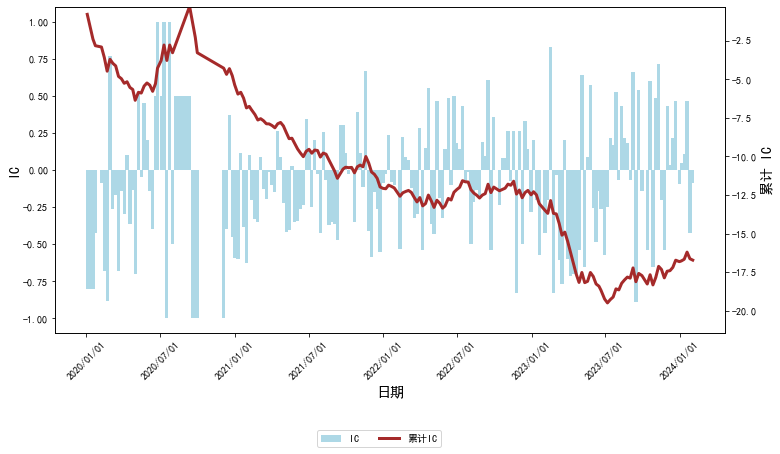

In [306]:
ic_values=pertimedateframe24['IC']
cumulative_ic = ic_values.cumsum()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(ic_values.index, ic_values, width=8, color='lightblue', label='IC')
ax1.set_ylabel('IC', fontsize=14)
ax1.set_xlabel('日期', fontsize=14)
ax1.set_ylim([ic_values.min() * 1.1 if ic_values.min() < 0 else ic_values.min() * 0.9, ic_values.max() * 1.1])
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
plt.xticks(rotation=45)
ax2 = ax1.twinx()
ax2.plot(cumulative_ic.index, cumulative_ic, color='brown', linewidth=3, label='累计IC')
ax2.set_ylabel('累计 IC', fontsize=14)
ax2.set_ylim([cumulative_ic.min() * 1.1 if cumulative_ic.min() < 0 else cumulative_ic.min() * 0.9,
              cumulative_ic.max() * 1.1])
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)

## 尝试24周且进行数据处理

In [307]:
weeklyvalue=valuepivot.loc[Weekly,:]
weeklyvalue.index[23:]

Index(['2015-06-19', '2015-06-26', '2015-07-03', '2015-07-10', '2015-07-17',
       '2015-07-24', '2015-07-31', '2015-08-07', '2015-08-14', '2015-08-21',
       ...
       '2024-05-24', '2024-05-31', '2024-06-07', '2024-06-14', '2024-06-21',
       '2024-06-30', '2024-07-05', '2024-07-12', '2024-07-19', '2024-07-26'],
      dtype='object', name='TradingDay', length=465)

In [308]:
value_df1 = pd.DataFrame()
for i in range(len(weeklyvalue.index[23:])):
    startdate = pd.to_datetime(Weekly[i])
    enddate = pd.to_datetime(weeklyvalue.index[23:][i])
    filtered_data = filterinitial[(filterinitial['成立日期'] >= startdate) & (filterinitial['成立日期'] <=enddate)]
    Tdata=pd.DataFrame(filtered_data.groupby('四级分类').sum(numeric_only=True)['初始资金亿元']).T
    value_df1 = pd.concat([value_df1, Tdata], ignore_index=True)

In [309]:
value_df1.index=weeklyvalue.index[23:]
value_df1

四级分类,金融,电子,国央企,国防军工,绿色/ESG,有色,房地产,游戏传媒,食品饮料,生物科技,...,新能源综合,基础化工,机械设备,汽车,基建,交通运输,旅游,电力,中药,石油石化
TradingDay,,,,,,,,,,,,,,,,,,,,,
2015-06-19,5.7906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-26,5.7906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-03,5.7906,2.721880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-10,5.7906,2.721880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-17,5.7906,2.721880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-30,NaN,20.774909,2.813208,NaN,NaN,11.341937,NaN,NaN,NaN,NaN,...,NaN,NaN,4.210558,9.419533,NaN,NaN,NaN,NaN,NaN,13.432506
2024-07-05,NaN,20.774909,2.813208,NaN,NaN,11.341937,NaN,NaN,NaN,NaN,...,NaN,NaN,4.210558,9.419533,NaN,NaN,NaN,NaN,NaN,13.432506
2024-07-12,NaN,20.774909,2.813208,NaN,NaN,11.341937,NaN,NaN,NaN,NaN,...,NaN,NaN,4.210558,9.419533,2.304584,NaN,NaN,NaN,NaN,13.432506


In [310]:
value_dfstack1=value_df1.stack().reset_index()
value_dfstack1.rename(columns={0:'新发行金额亿元'},inplace=True)
weeklyvaluestack=weeklyvalue.stack().reset_index()
weeklyvaluestack.rename(columns={0:'市值亿元'},inplace=True)

In [311]:
pertime1=pd.merge(value_dfstack1,weeklyvaluestack,on=['TradingDay','四级分类']).sort_values(by='TradingDay')
pertime1=pertime1[pertime1['TradingDay']>'2017-12-30']    
pertime1.reset_index(drop=True,inplace=True)
pertime1['中性化']=neutral_fun(pertime1, '新发行金额亿元')
pertime1['归一'] = pertime1.groupby('TradingDay')['中性化'].transform(lambda x: (x - x.mean()) / x.std())
pertime1['TradingDay']=pd.to_datetime(pertime1['TradingDay'])
pertime1

,TradingDay,四级分类,新发行金额亿元,市值亿元,中性化,归一
0,2017-12-31,金融,8.839460,72.856297,-0.333389,-1.315194
1,2017-12-31,国防军工,3.155635,7.807349,2.172664,-0.010308
2,2017-12-31,有色,4.475390,1.272440,4.315186,1.105290
3,2017-12-31,房地产,2.703760,0.701975,2.615379,0.220211
4,2018-01-05,金融,3.528061,73.138637,-0.094226,-1.068453
...,...,...,...,...,...,...
3272,2024-07-26,计算机,11.468159,84.012275,-7.467042,-1.918895
3273,2024-07-26,通信,6.034355,116.469756,0.411391,-0.643812
3274,2024-07-26,机械设备,4.210558,23.057120,1.166990,-0.521523
3275,2024-07-26,汽车,9.419533,8.877779,7.949858,0.576248


In [312]:
pertimedate1=pertime1.pivot_table(index='TradingDay',columns='四级分类',values='归一',aggfunc='sum')
pertimedate1.index = pertimedate1.index.strftime('%Y-%m-%d')

In [313]:
pertimedateIC41,pertimedateframe41=calculate_ics(pertimedate1,cumulative_return_week4)
pertimedateIC121,pertimedateframe121=calculate_ics(pertimedate1,cumulative_return_week12)
pertimedateIC241,pertimedateframe241=calculate_ics(pertimedate1,cumulative_return_week24)

In [314]:
pertimedateIC41

,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value
因子,-0.075295,0.464354,-0.162149,0.59727,0.005867


In [315]:
pertimedateIC121

,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value
因子,-0.017544,0.463053,-0.037889,0.522807,0.522927


In [316]:
pertimedateIC241

,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value
因子,-0.075597,0.463812,-0.162991,0.571429,0.00752


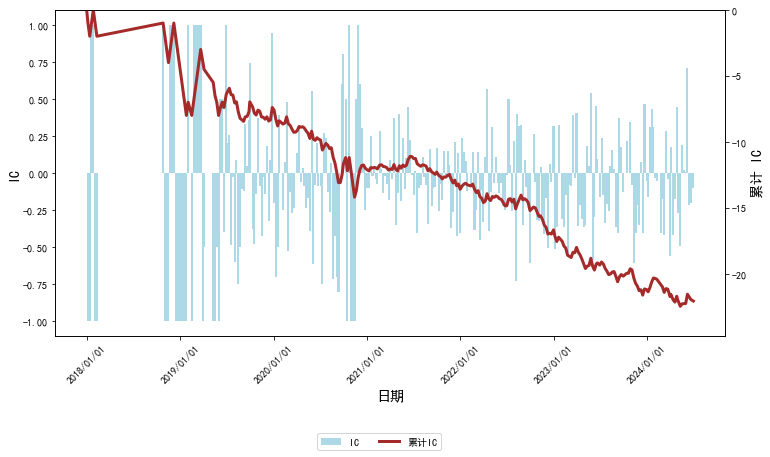

In [317]:
ic_values=pertimedateframe41['IC']
cumulative_ic = ic_values.cumsum()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(ic_values.index, ic_values, width=8, color='lightblue', label='IC')
ax1.set_ylabel('IC', fontsize=14)
ax1.set_xlabel('日期', fontsize=14)
ax1.set_ylim([ic_values.min() * 1.1 if ic_values.min() < 0 else ic_values.min() * 0.9, ic_values.max() * 1.1])
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
plt.xticks(rotation=45)
ax2 = ax1.twinx()
ax2.plot(cumulative_ic.index, cumulative_ic, color='brown', linewidth=3, label='累计IC')
ax2.set_ylabel('累计 IC', fontsize=14)
ax2.set_ylim([cumulative_ic.min() * 1.1 if cumulative_ic.min() < 0 else cumulative_ic.min() * 0.9,
              cumulative_ic.max() * 1.1])
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)

## 尝试24周但不进行数据处理

In [318]:
pertime1=pd.merge(value_dfstack1,weeklyvaluestack,on=['TradingDay','四级分类']).sort_values(by='TradingDay')
pertime1=pertime1[pertime1['TradingDay']>'2017-12-30']    
pertime1.reset_index(drop=True,inplace=True)
pertime1['TradingDay']=pd.to_datetime(pertime1['TradingDay'])
pertime1

,TradingDay,四级分类,新发行金额亿元,市值亿元
0,2017-12-31,金融,8.839460,72.856297
1,2017-12-31,国防军工,3.155635,7.807349
2,2017-12-31,有色,4.475390,1.272440
3,2017-12-31,房地产,2.703760,0.701975
4,2018-01-05,金融,3.528061,73.138637
...,...,...,...,...
3272,2024-07-26,计算机,11.468159,84.012275
3273,2024-07-26,通信,6.034355,116.469756
3274,2024-07-26,机械设备,4.210558,23.057120
3275,2024-07-26,汽车,9.419533,8.877779


In [319]:
pertimedate1=pertime1.pivot_table(index='TradingDay',columns='四级分类',values='新发行金额亿元',aggfunc='sum')
pertimedate1.index = pertimedate1.index.strftime('%Y-%m-%d')

In [320]:
pertimedateIC42,pertimedateframe42=calculate_ics(pertimedate1,cumulative_return_week4)
pertimedateIC122,pertimedateframe122=calculate_ics(pertimedate1,cumulative_return_week12)
pertimedateIC242,pertimedateframe242=calculate_ics(pertimedate1,cumulative_return_week24)

In [321]:
pertimedateIC42

,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value
因子,-0.056747,0.437373,-0.129746,0.542662,0.027126


In [322]:
pertimedateIC122

,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value
因子,-0.074987,0.448022,-0.167373,0.585965,0.005054


In [323]:
pertimedateIC242

,Factor_IC_mean,Factor_IC_std,Factor_ICIR,Factor_IC_negative,p-value
因子,-0.081142,0.458708,-0.176893,0.567766,0.003761


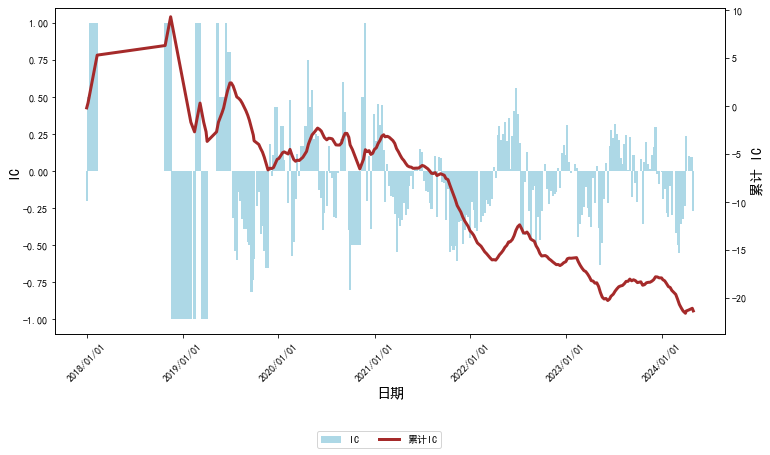

In [324]:
ic_values=pertimedateframe122['IC']
cumulative_ic = ic_values.cumsum()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(ic_values.index, ic_values, width=8, color='lightblue', label='IC')
ax1.set_ylabel('IC', fontsize=14)
ax1.set_xlabel('日期', fontsize=14)
ax1.set_ylim([ic_values.min() * 1.1 if ic_values.min() < 0 else ic_values.min() * 0.9, ic_values.max() * 1.1])
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
plt.xticks(rotation=45)
ax2 = ax1.twinx()
ax2.plot(cumulative_ic.index, cumulative_ic, color='brown', linewidth=3, label='累计IC')
ax2.set_ylabel('累计 IC', fontsize=14)
ax2.set_ylim([cumulative_ic.min() * 1.1 if cumulative_ic.min() < 0 else cumulative_ic.min() * 0.9,
              cumulative_ic.max() * 1.1])
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)

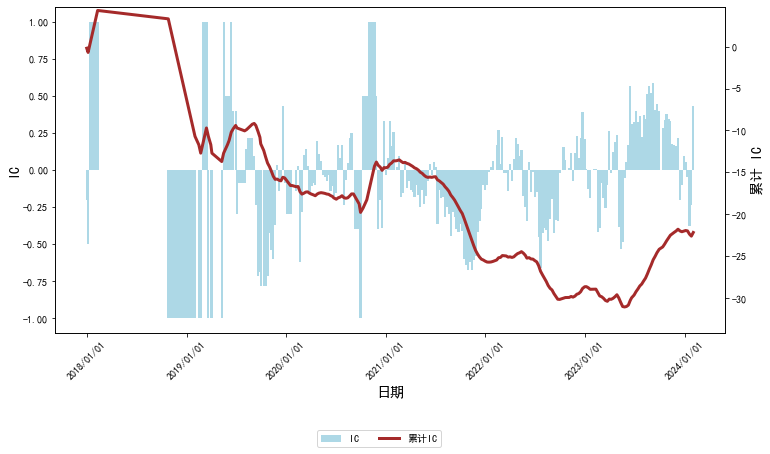

In [325]:
ic_values=pertimedateframe242['IC']
cumulative_ic = ic_values.cumsum()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(ic_values.index, ic_values, width=8, color='lightblue', label='IC')
ax1.set_ylabel('IC', fontsize=14)
ax1.set_xlabel('日期', fontsize=14)
ax1.set_ylim([ic_values.min() * 1.1 if ic_values.min() < 0 else ic_values.min() * 0.9, ic_values.max() * 1.1])
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
plt.xticks(rotation=45)
ax2 = ax1.twinx()
ax2.plot(cumulative_ic.index, cumulative_ic, color='brown', linewidth=3, label='累计IC')
ax2.set_ylabel('累计 IC', fontsize=14)
ax2.set_ylim([cumulative_ic.min() * 1.1 if cumulative_ic.min() < 0 else cumulative_ic.min() * 0.9,
              cumulative_ic.max() * 1.1])
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)